Title: LEE_Results_Analysis_all_condensed.ipynb

Purpose: Look at the found LEE Events for current and future climate

Author: Onno Nennecke on 16.07.2025 Modified: 20.04.2026

Input data: 

- LEE Tables: LEE_dat_14.csv, LEE_dat_7.csv, LEE_dat.csv, LEE_dat_14_selection.csv, LEE_dat_7_selection.csv, LEE_vl.csv
    - This file lies here: '/climca/people/onennecke/model_output/LEE_detection/'

- LEE Tables: LEE_dat_14_fut.csv, LEE_dat_7_fut.csv, LEE_dat_fut.csv, LEE_dat_14_selection_fut.csv, LEE_dat_7_selection_fut.csv, LEE_vl_fut.csv
    - This file lies here: '/climca/people/onennecke/model_output/LEE_detection/'

Output data:

- Plots: LEE_Event_yearly_distr, LEE_durations_comparison
    - These files lie here: /home/onennecke/Code/Figures/

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from scipy import stats
from scipy.stats import genextreme, genpareto, ks_2samp, norm

In [2]:
# Function to add a winter season column
def add_winter_season_column(df):
    # Ensure 'date_start' is in datetime format
    df['date_start'] = pd.to_datetime(df['date_start'])
    
    # Define a function to determine the winter season for each date
    def get_winter_season(date):
        year = date.year
        if date.month >= 7:  # July, August, September, October, November, December belong to the next year's winter
            return f"{year-2000}/{year-2000+1}"
        else:  # January, February, March, April, May, June belong to the current year's winter
            return f"{year-2000-1}/{year-2000}"
    
    # Apply the function to create a new 'winter_season' column
    df['winter_season'] = df['date_start'].apply(get_winter_season)
    return df

### Read LEE data

In [3]:
# Read the LEE data
LEE_dat = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat.csv')
LEE_dat = add_winter_season_column(LEE_dat)

LEE_dat_7_all = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7.csv')
LEE_7 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_selection.csv')
LEE_7 = add_winter_season_column(LEE_7)

LEE_dat_14_all = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14.csv')
LEE_14 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_selection.csv')
LEE_14 = add_winter_season_column(LEE_14)

LEE_vl = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_vl.csv')
LEE_vl = add_winter_season_column(LEE_vl)

# Read the LEE data
LEE_dat_fut = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_fut.csv')
LEE_dat_fut = add_winter_season_column(LEE_dat_fut)

LEE_dat_7_all_fut = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_fut.csv')
LEE_7_fut = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_selection_fut.csv')
LEE_7_fut = add_winter_season_column(LEE_7_fut)

LEE_dat_14_all_fut = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_fut.csv')
LEE_14_fut = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_selection_fut.csv')
LEE_14_fut = add_winter_season_column(LEE_14_fut)

LEE_vl_fut = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_vl_fut.csv')
LEE_vl_fut = add_winter_season_column(LEE_vl_fut)


LEE_dat_ERA5_1960_ = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_ERA5_1960_.csv')
LEE_dat_ERA5_1960_ = add_winter_season_column(LEE_dat_ERA5_1960_)
LEE_dat_7_ERA5_1960_ = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_selection_ERA5_1960_.csv')
LEE_dat_7_ERA5_1960_ = add_winter_season_column(LEE_dat_7_ERA5_1960_)
LEE_dat_14_ERA5_1960_ = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_selection_ERA5_1960_.csv')
LEE_dat_14_ERA5_1960_ = add_winter_season_column(LEE_dat_14_ERA5_1960_)
LEE_vl_ERA5_1960_ = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_vl_ERA5_1960_.csv')
LEE_vl_ERA5_1960_ = add_winter_season_column(LEE_vl_ERA5_1960_)


# ERA5 data
LEE_dat_ERA5_15_24 = LEE_dat[LEE_dat['ESM'] == 'ERA5_week']
LEE_7_ERA5_15_24 = LEE_7[LEE_7['ESM'] == 'ERA5_week']
LEE_14_ERA5_15_24 = LEE_14[LEE_14['ESM'] == 'ERA5_week']
LEE_vl_ERA5_15_24 = LEE_vl[LEE_vl['ESM'] == 'ERA5_week']

In [4]:
LEE_dat

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy,winter_season
0,2015-01-05,2015-01-05,2015-01-05,4,4,4,1,1347.755832,1347.755832,0.0,1347.755832,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,5,14/15
1,2015-01-07,2015-01-07,2015-01-07,6,6,6,1,1333.134503,1333.134503,0.0,1333.134503,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,7,14/15
2,2015-01-08,2015-01-08,2015-01-08,7,7,7,1,1395.107358,1395.107358,0.0,1395.107358,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,8,14/15
3,2015-01-18,2015-01-18,2015-01-18,17,17,17,1,1409.547842,1409.547842,0.0,1409.547842,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,18,14/15
4,2015-01-19,2015-01-19,2015-01-19,18,18,18,1,1403.974418,1403.974418,0.0,1403.974418,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,19,14/15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35421,2024-01-11,2024-01-11,2024-01-11,3295,3295,3295,1,1346.653250,1346.653250,0.0,1346.653250,35422,SMARD,SMARD_hist,2024,11,23/24
35422,2024-11-06,2024-11-06,2024-11-06,3594,3594,3594,1,1370.874500,1370.874500,0.0,1370.874500,35423,SMARD,SMARD_hist,2024,310,24/25
35423,2024-11-07,2024-11-07,2024-11-07,3595,3595,3595,1,1353.773750,1353.773750,0.0,1353.773750,35424,SMARD,SMARD_hist,2024,311,24/25
35424,2024-12-11,2024-12-11,2024-12-11,3629,3629,3629,1,1425.075500,1425.075500,0.0,1425.075500,35425,SMARD,SMARD_hist,2024,345,24/25


In [5]:
LEE_dat_ERA5_15_24

# Max RL_max of the ERA5 data
LEE_dat_ERA5_15_24['RL_cumulative'].max()


np.float64(1486.4413871898555)

In [6]:
# Remove all SMARD and ERA5_wwd data from the LEE_dat DataFrame
LEE_dat = LEE_dat[(LEE_dat['ESM'] != 'SMARD') & (LEE_dat['ESM'] != 'ERA5_wwd') & (LEE_dat['ESM'] != 'ERA5_week')]
LEE_7 = LEE_7[(LEE_7['ESM'] != 'SMARD') & (LEE_7['ESM'] != 'ERA5_wwd') & (LEE_7['ESM'] != 'ERA5_week')]
LEE_14 = LEE_14[(LEE_14['ESM'] != 'SMARD') & (LEE_14['ESM'] != 'ERA5_wwd') & (LEE_14['ESM'] != 'ERA5_week')]
LEE_vl = LEE_vl[(LEE_vl['ESM'] != 'SMARD') & (LEE_vl['ESM'] != 'ERA5_wwd') & (LEE_vl['ESM'] != 'ERA5_week')]

In [7]:
'''# Remove all SMARD and ERA5_wwd data from the LEE_dat DataFrame
LEE_dat = LEE_dat[(LEE_dat['ESM'] != 'SMARD') & (LEE_dat['ESM'] != 'ERA5_wwd') & (LEE_dat['ESM'] != 'ERA5_week')]
LEE_7 = LEE_7[(LEE_7['ESM'] != 'SMARD') & (LEE_7['ESM'] != 'ERA5_wwd') & (LEE_7['ESM'] != 'ERA5_week')]
LEE_14 = LEE_14[(LEE_14['ESM'] != 'SMARD') & (LEE_14['ESM'] != 'ERA5_wwd') & (LEE_14['ESM'] != 'ERA5_week')]
LEE_vl = LEE_vl[(LEE_vl['ESM'] != 'SMARD') & (LEE_vl['ESM'] != 'ERA5_wwd') & (LEE_vl['ESM'] != 'ERA5_week')]
# Put the other ERA5 data into the LEE_dat DataFrame
LEE_dat = pd.concat([LEE_dat, LEE_dat_ERA5_1960_], ignore_index=True)
LEE_7 = pd.concat([LEE_7, LEE_dat_7_ERA5_1960_], ignore_index=True)
LEE_14 = pd.concat([LEE_14, LEE_dat_14_ERA5_1960_], ignore_index=True)
LEE_vl = pd.concat([LEE_vl, LEE_vl_ERA5_1960_], ignore_index=True)'''


"# Remove all SMARD and ERA5_wwd data from the LEE_dat DataFrame\nLEE_dat = LEE_dat[(LEE_dat['ESM'] != 'SMARD') & (LEE_dat['ESM'] != 'ERA5_wwd') & (LEE_dat['ESM'] != 'ERA5_week')]\nLEE_7 = LEE_7[(LEE_7['ESM'] != 'SMARD') & (LEE_7['ESM'] != 'ERA5_wwd') & (LEE_7['ESM'] != 'ERA5_week')]\nLEE_14 = LEE_14[(LEE_14['ESM'] != 'SMARD') & (LEE_14['ESM'] != 'ERA5_wwd') & (LEE_14['ESM'] != 'ERA5_week')]\nLEE_vl = LEE_vl[(LEE_vl['ESM'] != 'SMARD') & (LEE_vl['ESM'] != 'ERA5_wwd') & (LEE_vl['ESM'] != 'ERA5_week')]\n# Put the other ERA5 data into the LEE_dat DataFrame\nLEE_dat = pd.concat([LEE_dat, LEE_dat_ERA5_1960_], ignore_index=True)\nLEE_7 = pd.concat([LEE_7, LEE_dat_7_ERA5_1960_], ignore_index=True)\nLEE_14 = pd.concat([LEE_14, LEE_dat_14_ERA5_1960_], ignore_index=True)\nLEE_vl = pd.concat([LEE_vl, LEE_vl_ERA5_1960_], ignore_index=True)"

In [8]:
LEE_dat['ESM'].unique()

array(['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'GFDL-ESM4',
       'KACE-1-0-G', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'TaiESM1',
       'UKESM1-0-LL'], dtype=object)

---

### Count

In [9]:
# Pure CMIP6 data
LEE_dat_CMIP = LEE_dat[LEE_dat['ESM'] != 'ERA5_week']
LEE_7_CMIP = LEE_7[LEE_7['ESM'] != 'ERA5_week']
LEE_14_CMIP = LEE_14[LEE_14['ESM'] != 'ERA5_week']
LEE_vl_CMIP = LEE_vl[LEE_vl['ESM'] != 'ERA5_week']

In [10]:
# Pure ERA5 data
# LEE_dat_ERA5 = LEE_dat[(LEE_dat['ESM'] == 'ERA5_week')]
# LEE_7_ERA5 = LEE_7[(LEE_7['ESM'] == 'ERA5_week')]
# LEE_14_ERA5 = LEE_14[(LEE_14['ESM'] == 'ERA5_week')]
# LEE_vl_ERA5 = LEE_vl[(LEE_vl['ESM'] == 'ERA5_week')]
LEE_dat_ERA5 = LEE_dat_ERA5_1960_
LEE_7_ERA5 = LEE_dat_7_ERA5_1960_
LEE_14_ERA5 = LEE_dat_14_ERA5_1960_
LEE_vl_ERA5 = LEE_vl_ERA5_1960_


In [11]:
LEE_dat_ERA5_1960_

LEE_dat_ERA5_1960_1990 = LEE_dat_ERA5_1960_[LEE_dat_ERA5_1960_['date_start'] < '1990-01-01']
LEE_dat_ERA5_1990_2024 = LEE_dat_ERA5_1960_[LEE_dat_ERA5_1960_['date_start'] >= '1990-01-01']

In [12]:
max(LEE_vl_ERA5['RL_mean'])
max(LEE_dat_ERA5['RL_mean'])

1589.5272153175442

In [13]:
max(LEE_dat_CMIP['RL_mean'])
LEE_dat_CMIP[LEE_dat_CMIP['RL_mean'] == max(LEE_dat_CMIP['RL_mean'])]

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy,winter_season
24639,2019-12-16,2019-12-16,2019-12-16,1809,1809,1809,1,1583.105372,1583.105372,0.0,1583.105372,24640,EC-Earth3,EC-Earth3_r121i1p1f1,2019,350,19/20


### Check how the LEE Days are distributed over the modells

In [14]:
'''# Add number of runs to the DataFrame
Nr_of_runs = LEE_vl.groupby('ESM')['ESM_run'].nunique()
LEE_vl['Nr_of_runs'] = LEE_vl['ESM'].map(Nr_of_runs)
LEE_vl['Nr_of_years'] = LEE_vl['Nr_of_runs'] * 10
# Replace the value for ERA5_week with 1 in the Nr_of_runs column
LEE_vl.loc[LEE_vl['ESM'] == 'ERA5_week', 'Nr_of_runs'] = 1
LEE_vl.loc[LEE_vl['ESM'] == 'ERA5_week', 'Nr_of_years'] = 65

LEE_all_comp = LEE_vl.copy()


LEE_all_comp['LEE_vl_dur_sum'] = LEE_all_comp.groupby('ESM')['duration'].transform('sum')
LEE_all_comp = LEE_all_comp.drop_duplicates(subset=['ESM', 'LEE_vl_dur_sum'])
# LEE_all_comp['Nr_of_runs'] = Nr_of_runs.values
# Add a CMIP6 row (Exclude ERA5) for total duration across all ESMs
cmip6_duration = LEE_all_comp[LEE_all_comp['ESM'] != 'ERA5_week']['LEE_vl_dur_sum'].sum()
cmip6_nr_of_runs = LEE_all_comp[LEE_all_comp['ESM'] != 'ERA5_week']['Nr_of_runs'].sum()
cmip6_row = pd.DataFrame({'ESM': ['CMIP6 Average'], 'LEE_vl_dur_sum': [cmip6_duration], 'Nr_of_runs': [cmip6_nr_of_runs], 'Nr_of_years': [cmip6_nr_of_runs * 10]})
LEE_all_comp = pd.concat([LEE_all_comp, cmip6_row], ignore_index=True)

LEE_all_comp['LEE_vl_dur_avg'] = LEE_all_comp['LEE_vl_dur_sum'] / LEE_all_comp['Nr_of_runs']
LEE_all_comp['LEE_vl_dur_avg_ranking'] = LEE_all_comp['LEE_vl_dur_avg'].rank(ascending=False)
# Remove most of the columns except for the ones we want to keep
LEE_all_comp = LEE_all_comp[['ESM', 'Nr_of_runs', 'Nr_of_years', 'LEE_vl_dur_sum', 'LEE_vl_dur_avg', 'LEE_vl_dur_avg_ranking']]


# LEE_dat_temp = LEE_dat.copy()
# LEE_dat_temp['LEE_dat_dur_sum'] = LEE_dat_temp.groupby('ESM')['duration'].transform('sum')
# LEE_dat_temp = LEE_dat_temp.drop_duplicates(subset=['ESM', 'LEE_dat_dur_sum'])
# LEE_dat_temp
# Join the two DataFrames on 'ESM'
# LEE_all_comp = LEE_all_comp.merge(LEE_dat_temp[['ESM', 'LEE_dat_dur_sum']], on='ESM', how='left')
# LEE_all_comp['LEE_dat_dur_avg'] = LEE_all_comp['LEE_dat_dur_sum'] / LEE_all_comp['Nr_of_runs']
LEE_all_comp

LEE_7_temp = LEE_7.copy()
LEE_7_temp['LEE_7_dur_sum'] = LEE_7_temp.groupby('ESM')['duration'].transform('sum')
LEE_7_temp = LEE_7_temp.drop_duplicates(subset=['ESM', 'LEE_7_dur_sum'])
cmip6_duration_7 = LEE_7_temp[LEE_7_temp['ESM'] != 'ERA5_week']['LEE_7_dur_sum'].sum()
cmip6_nr_of_runs_7 = LEE_7_temp[LEE_7_temp['ESM'] != 'ERA5_week']['ESM_run'].nunique()
cmip6_row_7 = pd.DataFrame({'ESM': ['CMIP6 Average'], 'LEE_7_dur_sum': [cmip6_duration_7], 'Nr_of_runs': [cmip6_nr_of_runs_7], 'Nr_of_years': [cmip6_nr_of_runs_7 * 10]})
LEE_7_temp = pd.concat([LEE_7_temp, cmip6_row_7], ignore_index=True)
LEE_7_temp

# Join the two DataFrames on 'ESM'
LEE_all_comp = LEE_all_comp.merge(LEE_7_temp[['ESM', 'LEE_7_dur_sum']], on='ESM', how='left')
LEE_all_comp['LEE_7_dur_avg'] = LEE_all_comp['LEE_7_dur_sum'] / LEE_all_comp['Nr_of_runs']
LEE_all_comp['LEE_7_dur_avg_ranking'] = LEE_all_comp['LEE_7_dur_avg'].rank(ascending=False)

LEE_14_temp = LEE_14.copy()
LEE_14_temp['LEE_14_dur_sum'] = LEE_14_temp.groupby('ESM')['duration'].transform('sum')
LEE_14_temp = LEE_14_temp.drop_duplicates(subset=['ESM', 'LEE_14_dur_sum'])
cmip6_duration_14 = LEE_14_temp[LEE_14_temp['ESM'] != 'ERA5_week']['LEE_14_dur_sum'].sum()
cmip6_nr_of_runs_14 = LEE_14_temp[LEE_14_temp['ESM'] != 'ERA5_week']['ESM_run'].nunique()
cmip6_row_14 = pd.DataFrame({'ESM': ['CMIP6 Average'], 'LEE_14_dur_sum': [cmip6_duration_14], 'Nr_of_runs': [cmip6_nr_of_runs_14], 'Nr_of_years': [cmip6_nr_of_runs_14 * 10]})
LEE_14_temp = pd.concat([LEE_14_temp, cmip6_row_14], ignore_index=True)
LEE_14_temp
# Join the two DataFrames on 'ESM'
LEE_all_comp = LEE_all_comp.merge(LEE_14_temp[['ESM', 'LEE_14_dur_sum']], on='ESM', how='left')
LEE_all_comp['LEE_14_dur_avg'] = LEE_all_comp['LEE_14_dur_sum'] / LEE_all_comp['Nr_of_runs']
LEE_all_comp['LEE_14_dur_avg_ranking'] = LEE_all_comp['LEE_14_dur_avg'].rank(ascending=False)

LEE_all_comp['ESM_label'] = LEE_all_comp['ESM'] + ' \n (n = ' + LEE_all_comp['Nr_of_years'].astype(str) + ')'
# Fix the label for ERA5_week to display as "ERA5 \n (n = 1)"
# LEE_all_comp.loc[LEE_all_comp['ESM'] == 'ERA5_week', 'ESM_label'] = 'ERA5 \n (n = 1)'
LEE_all_comp
'''

'# Add number of runs to the DataFrame\nNr_of_runs = LEE_vl.groupby(\'ESM\')[\'ESM_run\'].nunique()\nLEE_vl[\'Nr_of_runs\'] = LEE_vl[\'ESM\'].map(Nr_of_runs)\nLEE_vl[\'Nr_of_years\'] = LEE_vl[\'Nr_of_runs\'] * 10\n# Replace the value for ERA5_week with 1 in the Nr_of_runs column\nLEE_vl.loc[LEE_vl[\'ESM\'] == \'ERA5_week\', \'Nr_of_runs\'] = 1\nLEE_vl.loc[LEE_vl[\'ESM\'] == \'ERA5_week\', \'Nr_of_years\'] = 65\n\nLEE_all_comp = LEE_vl.copy()\n\n\nLEE_all_comp[\'LEE_vl_dur_sum\'] = LEE_all_comp.groupby(\'ESM\')[\'duration\'].transform(\'sum\')\nLEE_all_comp = LEE_all_comp.drop_duplicates(subset=[\'ESM\', \'LEE_vl_dur_sum\'])\n# LEE_all_comp[\'Nr_of_runs\'] = Nr_of_runs.values\n# Add a CMIP6 row (Exclude ERA5) for total duration across all ESMs\ncmip6_duration = LEE_all_comp[LEE_all_comp[\'ESM\'] != \'ERA5_week\'][\'LEE_vl_dur_sum\'].sum()\ncmip6_nr_of_runs = LEE_all_comp[LEE_all_comp[\'ESM\'] != \'ERA5_week\'][\'Nr_of_runs\'].sum()\ncmip6_row = pd.DataFrame({\'ESM\': [\'CMIP6 Average\']

In [15]:
print(252.105263 / 99 * 100)
print(124.157895 / 49 * 100)
print(84.000000 / 9.3 * 100)

254.65178080808082
253.38345918367344
903.2258064516128


In [16]:
# ---- 7 -------------------------------------------------
Nr = LEE_7.groupby('ESM')['ESM_run'].nunique()
df = LEE_7.copy()
df['Nr_of_runs'] = df['ESM'].map(Nr)

df['Nr_of_years'] = df['Nr_of_runs'] * 10

df['LEE_7_dur_sum'] = df.groupby('ESM')['duration'].transform('sum')
df = df.drop_duplicates(subset=['ESM', 'LEE_7_dur_sum'])

std_values = {esm: np.std(LEE_7[LEE_7['ESM'] == esm].groupby('ESM_run')['duration'].sum()) for esm in LEE_7['ESM'].unique()}
df['LEE_7_dur_std'] = df['ESM'].map(std_values)

cmip = df[df['ESM'] != 'ERA5_week']
df = pd.concat([
    df,
    pd.DataFrame({
        'ESM': ["CMIP6 Average"],
        'LEE_7_dur_sum': [cmip['LEE_7_dur_sum'].sum()],
        'Nr_of_runs': [cmip['Nr_of_runs'].sum()],
        'Nr_of_years': [cmip['Nr_of_runs'].sum() * 10],
        'LEE_7_dur_std': [np.std(LEE_7.groupby('ESM_run')['duration'].sum())] # ???
    }),
    pd.DataFrame({
        'ESM': ["CMIP6 Average (weighted)"],
        'LEE_7_dur_sum': [(cmip['LEE_7_dur_sum'] / cmip['Nr_of_runs']).sum()],
        'Nr_of_runs': [10],
        'Nr_of_years': [100],
        'LEE_7_dur_std': [np.std((cmip['LEE_7_dur_sum'] / cmip['Nr_of_runs']))]
    })
])

df['LEE_7_dur_avg'] = df['LEE_7_dur_sum'] / df['Nr_of_runs']

In [17]:
df

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,...,ESM,ESM_run,year,doy,winter_season,Nr_of_runs,Nr_of_years,LEE_7_dur_sum,LEE_7_dur_std,LEE_7_dur_avg
0,2016-12-21,2016-12-27,2016-12-21 00:00:00.000000003,719.0,725.0,722.0,7.0,1423.669022,1363.985879,60.214536,...,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016.0,355.0,16/17,3,30,217.000000,16.499158,72.333333
31,2015-01-29,2015-02-04,2015-01-29 00:00:00.000000001,28.0,34.0,29.0,7.0,1404.858048,1345.513789,41.413112,...,BCC-CSM2-MR,BCC-CSM2-MR_r1i1p1f1,2015.0,29.0,14/15,1,10,98.000000,0.000000,98.000000
45,2015-01-04,2015-01-10,2015-01-04 00:00:00.000000001,3.0,9.0,4.0,7.0,1431.314219,1347.502230,64.840148,...,CESM2,CESM2_LE2-1001_001,2015.0,4.0,14/15,103,1030,11214.000000,28.849014,108.873786
1647,2018-01-10,2018-01-16,2018-01-10 00:00:00.000000005,1104.0,1110.0,1109.0,7.0,1475.125220,1392.078124,70.418712,...,EC-Earth3,EC-Earth3_r101i1p1f1,2018.0,10.0,17/18,54,540,2478.000000,14.798231,45.888889
2010,2017-11-25,2017-12-01,2017-11-25 00:00:00.000000003,1058.0,1064.0,1061.0,7.0,1447.553440,1326.775099,69.799667,...,GFDL-ESM4,GFDL-ESM4_r1i1p1f1,2017.0,329.0,17/18,1,10,35.000000,0.000000,35.000000
2015,2016-01-18,2016-01-24,2016-01-18 00:00:00.000000001,382.0,388.0,383.0,7.0,1499.274756,1344.549852,113.250381,...,KACE-1-0-G,KACE-1-0-G_r1i1p1f1,2016.0,18.0,15/16,3,30,140.000000,8.730534,46.666667
2035,2015-01-27,2015-02-02,2015-01-27 00:00:00.000000005,26.0,32.0,31.0,7.0,1521.811527,1388.684581,148.870871,...,MPI-ESM1-2-HR,MPI-ESM1-2-HR_r10i1p1f1,2015.0,27.0,14/15,10,100,973.000000,24.539967,97.300000
2174,2016-11-10,2016-11-16,2016-11-10 00:00:00.000000004,678.0,684.0,682.0,7.0,1390.026484,1340.998735,59.718709,...,MRI-ESM2-0,MRI-ESM2-0_r1i1p1f1,2016.0,314.0,16/17,5,50,308.000000,24.409834,61.600000
2218,2015-01-16,2015-01-22,2015-01-16 00:00:00.000000006,15.0,21.0,21.0,7.0,1414.792632,1330.370430,71.061281,...,TaiESM1,TaiESM1_r1i1p1f1,2015.0,16.0,14/15,1,10,49.000000,0.000000,49.000000
2225,2015-12-08,2015-12-14,2015-12-08 00:00:00.000000005,341.0,347.0,346.0,7.0,1447.557596,1421.151804,25.884006,...,UKESM1-0-LL,UKESM1-0-LL_r13i1p1f2,2015.0,342.0,15/16,11,110,1085.000000,19.448172,98.636364


In [18]:
LEE_vl

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy,winter_season
0,2015-01-05,2015-01-05,2015-01-05 00:00:00.000000000,4,4,4,1,1347.755832,1347.755832,0.000000,1347.755832,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,5,14/15
1,2015-01-07,2015-01-08,2015-01-07 00:00:00.000000001,6,7,7,2,1395.107358,1364.120931,30.986428,2728.241861,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,7,14/15
2,2015-01-18,2015-01-19,2015-01-18 00:00:00.000000000,17,18,17,2,1409.547842,1406.761130,2.786712,2813.522261,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,18,14/15
3,2015-01-23,2015-01-23,2015-01-23 00:00:00.000000000,22,22,22,1,1325.531111,1325.531111,0.000000,1325.531111,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,23,14/15
4,2015-02-27,2015-02-27,2015-02-27 00:00:00.000000000,57,57,57,1,1323.002140,1323.002140,0.000000,1323.002140,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,58,14/15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17232,2024-11-27,2024-11-27,2024-11-27 00:00:00.000000000,3615,3615,3615,1,1341.248349,1341.248349,0.000000,1341.248349,17233,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,331,24/25
17233,2024-11-30,2024-11-30,2024-11-30 00:00:00.000000000,3618,3618,3618,1,1319.699456,1319.699456,0.000000,1319.699456,17234,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,334,24/25
17234,2024-12-19,2024-12-21,2024-12-19 00:00:00.000000001,3637,3639,3638,3,1455.111286,1444.409016,8.891389,4333.227048,17235,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,353,24/25
17235,2024-12-25,2024-12-25,2024-12-25 00:00:00.000000000,3643,3643,3643,1,1392.939718,1392.939718,0.000000,1392.939718,17236,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,359,24/25


In [19]:
cmip['ESM']

0          ACCESS-CM2
31        BCC-CSM2-MR
45              CESM2
1647        EC-Earth3
2010        GFDL-ESM4
2015       KACE-1-0-G
2035    MPI-ESM1-2-HR
2174       MRI-ESM2-0
2218          TaiESM1
2225      UKESM1-0-LL
Name: ESM, dtype: object

In [20]:
cmip['LEE_vl_dur_sum']

KeyError: 'LEE_vl_dur_sum'

In [24]:
(cmip['LEE_vl_dur_sum'] / cmip['Nr_of_runs']).mean()

np.float64(168.7888699290641)

In [15]:
df

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,...,ESM,ESM_run,year,doy,winter_season,Nr_of_runs,Nr_of_years,LEE_vl_dur_sum,LEE_vl_dur_std,LEE_vl_dur_avg
0,2015-01-05,2015-01-05,2015-01-05 00:00:00.000000000,4.0,4.0,4.0,1.0,1347.755832,1347.755832,0.000000,...,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015.0,5.0,14/15,3,30,595.000000,15.107026,198.333333
324,2015-01-08,2015-01-08,2015-01-08 00:00:00.000000000,7.0,7.0,7.0,1.0,1339.080623,1339.080623,0.000000,...,BCC-CSM2-MR,BCC-CSM2-MR_r1i1p1f1,2015.0,8.0,14/15,1,10,185.000000,0.000000,185.000000
421,2015-01-04,2015-01-08,2015-01-04 00:00:00.000000001,3.0,7.0,4.0,5.0,1431.314219,1385.497292,28.844243,...,CESM2,CESM2_LE2-1001_001,2015.0,4.0,14/15,103,1030,21076.000000,35.270967,204.621359
10089,2015-01-03,2015-01-03,2015-01-03 00:00:00.000000000,2.0,2.0,2.0,1.0,1350.024256,1350.024256,0.000000,...,EC-Earth3,EC-Earth3_r101i1p1f1,2015.0,3.0,14/15,54,540,7319.000000,16.163187,135.537037
14300,2015-01-06,2015-01-07,2015-01-06 00:00:00.000000000,5.0,6.0,5.0,2.0,1474.685072,1465.739961,8.945111,...,GFDL-ESM4,GFDL-ESM4_r1i1p1f1,2015.0,6.0,14/15,1,10,136.000000,0.000000,136.000000
14376,2015-01-03,2015-01-04,2015-01-03 00:00:00.000000000,2.0,3.0,2.0,2.0,1428.373799,1408.950682,19.423117,...,KACE-1-0-G,KACE-1-0-G_r1i1p1f1,2015.0,3.0,14/15,3,30,298.000000,8.178563,99.333333
14524,2015-01-13,2015-01-14,2015-01-13 00:00:00.000000001,12.0,13.0,13.0,2.0,1467.548357,1422.151440,45.396917,...,MPI-ESM1-2-HR,MPI-ESM1-2-HR_r10i1p1f1,2015.0,13.0,14/15,10,100,2185.000000,33.764626,218.500000
15618,2015-01-03,2015-01-04,2015-01-03 00:00:00.000000000,2.0,3.0,2.0,2.0,1411.154875,1399.960858,11.194017,...,MRI-ESM2-0,MRI-ESM2-0_r1i1p1f1,2015.0,3.0,14/15,5,50,706.000000,17.290460,141.200000
15984,2015-01-01,2015-01-01,2015-01-01 00:00:00.000000000,0.0,0.0,0.0,1.0,1361.631191,1361.631191,0.000000,...,TaiESM1,TaiESM1_r1i1p1f1,2015.0,1.0,14/15,1,10,150.000000,0.000000,150.000000
16084,2015-01-01,2015-01-04,2015-01-01 00:00:00.000000001,0.0,3.0,1.0,4.0,1447.785976,1418.964697,23.716567,...,UKESM1-0-LL,UKESM1-0-LL_r13i1p1f2,2015.0,1.0,14/15,11,110,2413.000000,30.639466,219.363636


In [20]:
# ============================================================
# --------- BUILD HISTORICAL COMPOSITE (VL / 7 / 14) ----------
# ============================================================

def build_comp(LEE_vl, LEE_7, LEE_14, label_cmip="CMIP6 Average", ERA5 = False):
    # ---- VL -------------------------------------------------
    Nr = LEE_vl.groupby('ESM')['ESM_run'].nunique()
    df = LEE_vl.copy()
    df['Nr_of_runs'] = df['ESM'].map(Nr)
    if ERA5:
        df.loc[df['ESM'] == 'ERA5_week', 'Nr_of_runs'] = 6.5
    df['Nr_of_years'] = df['Nr_of_runs'] * 10

    df['LEE_vl_dur_sum'] = df.groupby('ESM')['duration'].transform('sum')
    df = df.drop_duplicates(subset=['ESM', 'LEE_vl_dur_sum'])

    std_values = {esm: np.std(LEE_vl[LEE_vl['ESM'] == esm].groupby('ESM_run')['duration'].sum()) for esm in LEE_vl['ESM'].unique()}
    df['LEE_vl_dur_std'] = df['ESM'].map(std_values)

    cmip = df[df['ESM'] != 'ERA5_week']
    df = pd.concat([
        df,
        pd.DataFrame({
            'ESM': [label_cmip],
            'LEE_vl_dur_sum': [cmip['LEE_vl_dur_sum'].sum()],
            'Nr_of_runs': [cmip['Nr_of_runs'].sum()],
            'Nr_of_years': [cmip['Nr_of_runs'].sum() * 10],
            'LEE_vl_dur_std': [np.std(LEE_vl.groupby('ESM_run')['duration'].sum())]
        }),
        pd.DataFrame({
            'ESM': ["CMIP6 Average (weighted)"],
            'LEE_vl_dur_sum': [(cmip['LEE_vl_dur_sum'] / cmip['Nr_of_runs']).sum()],
            'Nr_of_runs': [10],
            'Nr_of_years': [100],
            'LEE_vl_dur_std': [np.std((cmip['LEE_vl_dur_sum'] / cmip['Nr_of_runs']))]
        })
    ])

    df['LEE_vl_dur_avg'] = df['LEE_vl_dur_sum'] / df['Nr_of_runs']


    # ---- 7 -------------------------------------------------
    Nr = LEE_7.groupby('ESM')['ESM_run'].nunique()
    df_7 = LEE_7.copy()
    df_7['Nr_of_runs'] = df_7['ESM'].map(Nr)
    if ERA5:
        df_7.loc[df_7['ESM'] == 'ERA5_week', 'Nr_of_runs'] = 6.5
    df_7['Nr_of_years'] = df_7['Nr_of_runs'] * 10

    df_7['LEE_7_dur_sum'] = df_7.groupby('ESM')['duration'].transform('sum')
    df_7 = df_7.drop_duplicates(subset=['ESM', 'LEE_7_dur_sum'])

    std_values = {esm: np.std(LEE_7[LEE_7['ESM'] == esm].groupby('ESM_run')['duration'].sum()) for esm in LEE_7['ESM'].unique()}
    df_7['LEE_7_dur_std'] = df_7['ESM'].map(std_values)

    cmip = df_7[df_7['ESM'] != 'ERA5_week']
    df_7 = pd.concat([
        df_7,
        pd.DataFrame({
            'ESM': ["CMIP6 Average"],
            'LEE_7_dur_sum': [cmip['LEE_7_dur_sum'].sum()],
            'Nr_of_runs': [cmip['Nr_of_runs'].sum()],
            'Nr_of_years': [cmip['Nr_of_runs'].sum() * 10],
            'LEE_7_dur_std': [np.std(LEE_7.groupby('ESM_run')['duration'].sum())] # ???
        }),
        pd.DataFrame({
            'ESM': ["CMIP6 Average (weighted)"],
            'LEE_7_dur_sum': [(cmip['LEE_7_dur_sum'] / cmip['Nr_of_runs']).sum()],
            'Nr_of_runs': [10],
            'Nr_of_years': [100],
            'LEE_7_dur_std': [np.std((cmip['LEE_7_dur_sum'] / cmip['Nr_of_runs']))]
        })
    ])

    df_7['LEE_7_dur_avg'] = df_7['LEE_7_dur_sum'] / df_7['Nr_of_runs']

    df = df.merge(df_7[['ESM', 'LEE_7_dur_sum', 'LEE_7_dur_std', 'LEE_7_dur_avg']], on='ESM', how='left')


    # ---- 14 -------------------------------------------------
    Nr = LEE_14.groupby('ESM')['ESM_run'].nunique()
    df_14 = LEE_14.copy()
    df_14['Nr_of_runs'] = df_14['ESM'].map(Nr)
    if ERA5:
        df_14.loc[df_14['ESM'] == 'ERA5_week', 'Nr_of_runs'] = 6.5
    df_14['Nr_of_years'] = df_14['Nr_of_runs'] * 10

    df_14['LEE_14_dur_sum'] = df_14.groupby('ESM')['duration'].transform('sum')
    df_14 = df_14.drop_duplicates(subset=['ESM', 'LEE_14_dur_sum'])

    std_values = {esm: np.std(LEE_14[LEE_14['ESM'] == esm].groupby('ESM_run')['duration'].sum()) for esm in LEE_14['ESM'].unique()}
    df_14['LEE_14_dur_std'] = df_14['ESM'].map(std_values)

    cmip = df_14[df_14['ESM'] != 'ERA5_week']
    df_14 = pd.concat([
        df_14,
        pd.DataFrame({
            'ESM': ["CMIP6 Average"],
            'LEE_14_dur_sum': [cmip['LEE_14_dur_sum'].sum()],
            'Nr_of_runs': [cmip['Nr_of_runs'].sum()],
            'Nr_of_years': [cmip['Nr_of_runs'].sum() * 10],
            'LEE_14_dur_std': [np.std(LEE_14.groupby('ESM_run')['duration'].sum())] # ???
        }),
        pd.DataFrame({
            'ESM': ["CMIP6 Average (weighted)"],
            'LEE_14_dur_sum': [(cmip['LEE_14_dur_sum'] / cmip['Nr_of_runs']).sum()],
            'Nr_of_runs': [10],
            'Nr_of_years': [100],
            'LEE_14_dur_std': [np.std((cmip['LEE_14_dur_sum'] / cmip['Nr_of_runs']))]
        })
    ])

    df_14['LEE_14_dur_avg'] = df_14['LEE_14_dur_sum'] / df_14['Nr_of_runs']


    df = df.merge(df_14[['ESM', 'LEE_14_dur_sum', 'LEE_14_dur_std', 'LEE_14_dur_avg']], on='ESM', how='left')

    # # ---- 7 / 14 ---------------------------------------------
    # for src, tag in [(LEE_7, '7'), (LEE_14, '14')]:
    #     tmp = src.copy()
    #     tmp[f'LEE_{tag}_dur_sum'] = tmp.groupby('ESM')['duration'].transform('sum')
    #     tmp = tmp.drop_duplicates(subset=['ESM', f'LEE_{tag}_dur_sum'])

    #     std_values = {esm: np.std(src[src['ESM'] == esm].groupby('ESM_run')['duration'].sum()) for esm in src['ESM'].unique()}
    #     tmp[f'LEE_{tag}_dur_std'] = tmp['ESM'].map(std_values)

    #     cm = tmp[tmp['ESM'] != 'ERA5_week']
    #     tmp = pd.concat([
    #         tmp,
    #         pd.DataFrame({
    #             'ESM': [label_cmip],
    #             f'LEE_{tag}_dur_sum': [cm[f'LEE_{tag}_dur_sum'].sum()],
    #             f'LEE_{tag}_dur_std': [np.std(src.groupby('ESM_run')['duration'].sum())]
    #         }),
    #         pd.DataFrame({
    #             'ESM': ["CMIP6 Average (weighted)"],
    #             f'LEE_{tag}_dur_sum': [(cm[f'LEE_{tag}_dur_sum'] / cmip['Nr_of_runs']).sum() * 10],
    #             f'LEE_{tag}_dur_std': [np.std((cm[f'LEE_{tag}_dur_sum'] / cmip['Nr_of_runs']))]
    #         })
    #     ])

    #     df = df.merge(tmp[['ESM', f'LEE_{tag}_dur_sum', f'LEE_{tag}_dur_std']], on='ESM', how='left')
    #     df[f'LEE_{tag}_dur_avg'] = df[f'LEE_{tag}_dur_sum'] / df['Nr_of_runs']

    # ---- labels ---------------------------------------------
    df['ESM_label'] = (
        df['ESM'] + '\n(n = ' + df['Nr_of_years'].astype(int).astype(str) + ')'
    )
    # Change label of CMIP average (weighted)
    df.loc[df['ESM'] == 'CMIP6 Average (weighted)', 'ESM_label'] = 'CMIP6 Average\n(weighted)\n(n = 1920)'
    
    # df.loc[df['ESM'] == 'ERA5_week', 'ESM_label'] = 'ERA5\n(n = 1)'
    # Remove column date_start
    df = df.drop(columns=['date_start', 'date_end', 'date_peak', 'index_start', 'index_end', 'index_peak', 'duration',
                          'RL_max', 'RL_mean', 'RL_var', 'RL_cumulative', 'event', 'year', 'ESM_run', 'winter_season'])
    
    return df


# historical + future
LEE_hist = build_comp(LEE_vl, LEE_7, LEE_14)
LEE_fut  = build_comp(LEE_vl_fut, LEE_7_fut, LEE_14_fut)

LEE_ERA5_1960 = build_comp(LEE_vl_ERA5_1960_, LEE_dat_7_ERA5_1960_, LEE_dat_14_ERA5_1960_, ERA5=True)
LEE_ERA5_1960.loc[0, 'ESM_label'] = 'ERA5 (1960 - 2024)\n(n = 65)'
LEE_ERA5_15_24 = build_comp(LEE_vl_ERA5_15_24, LEE_7_ERA5_15_24, LEE_14_ERA5_15_24)
LEE_ERA5_15_24.loc[0, 'ESM_label'] = 'ERA5 (2015 - 2024)\n(n = 10)'

# Remove ERA5 from hist and replace it by the 1960-2020 ERA5 composite (since the latter is more robust and consistent with the CMIP6 models)
LEE_hist = LEE_hist[LEE_hist['ESM'] != 'ERA5_week']
LEE_hist = pd.concat([LEE_hist, LEE_ERA5_1960[:1]], ignore_index=True)
LEE_hist = pd.concat([LEE_hist, LEE_ERA5_15_24[:1]], ignore_index=True)
LEE_hist = LEE_hist.drop(columns=['doy'])


/tmp/ipykernel_1723195/2421720106.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '6.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['ESM'] == 'ERA5_week', 'Nr_of_runs'] = 6.5
/tmp/ipykernel_1723195/2421720106.py:47: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '6.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_7.loc[df_7['ESM'] == 'ERA5_week', 'Nr_of_runs'] = 6.5
/tmp/ipykernel_1723195/2421720106.py:85: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '6.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_14.loc[df_14['ESM'] == 'ERA5_week', 'Nr_of_runs'] = 6.5


In [39]:
539 / 65

8.292307692307693

In [60]:
LEE_hist

,ESM,Nr_of_runs,Nr_of_years,LEE_vl_dur_sum,LEE_vl_dur_std,LEE_vl_dur_avg,LEE_7_dur_sum,LEE_7_dur_std,LEE_7_dur_avg,LEE_14_dur_sum,LEE_14_dur_std,LEE_14_dur_avg,ESM_label
0,ACCESS-CM2,3.0,30.0,595.000000,15.107026,198.333333,217.000000,16.499158,72.333333,112.000000,28.000000,56.000000,ACCESS-CM2\n(n = 30)
1,BCC-CSM2-MR,1.0,10.0,185.000000,0.000000,185.000000,98.000000,0.000000,98.000000,98.000000,0.000000,98.000000,BCC-CSM2-MR\n(n = 10)
2,CESM2,103.0,1030.0,21076.000000,35.270967,204.621359,11214.000000,28.849014,108.873786,8106.000000,37.269862,80.257426,CESM2\n(n = 1030)
3,EC-Earth3,54.0,540.0,7319.000000,16.163187,135.537037,2478.000000,14.798231,45.888889,574.000000,10.399420,22.076923,EC-Earth3\n(n = 540)
4,GFDL-ESM4,1.0,10.0,136.000000,0.000000,136.000000,35.000000,0.000000,35.000000,NaN,NaN,NaN,GFDL-ESM4\n(n = 10)
5,KACE-1-0-G,3.0,30.0,298.000000,8.178563,99.333333,140.000000,8.730534,46.666667,42.000000,7.000000,21.000000,KACE-1-0-G\n(n = 30)
6,MPI-ESM1-2-HR,10.0,100.0,2185.000000,33.764626,218.500000,973.000000,24.539967,97.300000,504.000000,17.928748,50.400000,MPI-ESM1-2-HR\n(n = 100)
7,MRI-ESM2-0,5.0,50.0,706.000000,17.290460,141.200000,308.000000,24.409834,61.600000,140.000000,21.000000,35.000000,MRI-ESM2-0\n(n = 50)
8,TaiESM1,1.0,10.0,150.000000,0.000000,150.000000,49.000000,0.000000,49.000000,14.000000,0.000000,14.000000,TaiESM1\n(n = 10)
9,UKESM1-0-LL,11.0,110.0,2413.000000,30.639466,219.363636,1085.000000,19.448172,98.636364,518.000000,31.741726,47.090909,UKESM1-0-LL\n(n = 110)


In [24]:
LEE_hist

,ESM,Nr_of_runs,Nr_of_years,LEE_vl_dur_sum,LEE_vl_dur_std,LEE_vl_dur_avg,LEE_7_dur_sum,LEE_7_dur_std,LEE_7_dur_avg,LEE_14_dur_sum,LEE_14_dur_std,LEE_14_dur_avg,ESM_label
0,ACCESS-CM2,3.0,30.0,595.000000,15.107026,198.333333,217.000000,16.499158,72.333333,112.000000,28.000000,37.333333,ACCESS-CM2\n(n = 30)
1,BCC-CSM2-MR,1.0,10.0,185.000000,0.000000,185.000000,98.000000,0.000000,98.000000,98.000000,0.000000,98.000000,BCC-CSM2-MR\n(n = 10)
2,CESM2,103.0,1030.0,21076.000000,35.270967,204.621359,11214.000000,28.849014,108.873786,8106.000000,37.269862,78.699029,CESM2\n(n = 1030)
3,EC-Earth3,54.0,540.0,7319.000000,16.163187,135.537037,2478.000000,14.798231,45.888889,574.000000,10.399420,10.629630,EC-Earth3\n(n = 540)
4,GFDL-ESM4,1.0,10.0,136.000000,0.000000,136.000000,35.000000,0.000000,35.000000,NaN,NaN,NaN,GFDL-ESM4\n(n = 10)
5,KACE-1-0-G,3.0,30.0,298.000000,8.178563,99.333333,140.000000,8.730534,46.666667,42.000000,7.000000,14.000000,KACE-1-0-G\n(n = 30)
6,MPI-ESM1-2-HR,10.0,100.0,2185.000000,33.764626,218.500000,973.000000,24.539967,97.300000,504.000000,17.928748,50.400000,MPI-ESM1-2-HR\n(n = 100)
7,MRI-ESM2-0,5.0,50.0,706.000000,17.290460,141.200000,308.000000,24.409834,61.600000,140.000000,21.000000,28.000000,MRI-ESM2-0\n(n = 50)
8,TaiESM1,1.0,10.0,150.000000,0.000000,150.000000,49.000000,0.000000,49.000000,14.000000,0.000000,14.000000,TaiESM1\n(n = 10)
9,UKESM1-0-LL,11.0,110.0,2413.000000,30.639466,219.363636,1085.000000,19.448172,98.636364,518.000000,31.741726,47.090909,UKESM1-0-LL\n(n = 110)


In [35]:
63.41+9.22
print(72.63 * 24)
print(88.83*7)

1743.12
621.81


In [44]:
# df_hist = LEE_hist.set_index('ESM_label')[cols]

df_hist

,LEE_vl_dur_avg,LEE_7_dur_avg,LEE_14_dur_avg
ESM_label,,,
CMIP6 Average\n(n = 1920),182.619792,86.442708,63.974684
CMIP6 Average\n(n = 1920),182.619792,86.442708,63.974684
ERA5 (2015 - 2024)\n(n = 10),160.000000,63.000000,28.000000
ERA5 (1960 - 2024)\n(n = 65),210.461538,82.923077,40.923077
ACCESS-CM2\n(n = 30),198.333333,72.333333,56.000000
BCC-CSM2-MR\n(n = 10),185.000000,98.000000,98.000000
CESM2\n(n = 1030),204.621359,108.873786,80.257426
EC-Earth3\n(n = 540),135.537037,45.888889,22.076923
GFDL-ESM4\n(n = 10),136.000000,35.000000,NaN


In [55]:
df_hist

,LEE_vl_dur_avg,LEE_7_dur_avg,LEE_14_dur_avg
ESM_label,,,
CMIP6 Average\n(n = 1920),182.619792,86.442708,52.645833
ERA5 (2015 - 2024)\n(n = 10),160.000000,63.000000,28.000000
ERA5 (1960 - 2024)\n(n = 65),210.461538,82.923077,40.923077
ACCESS-CM2\n(n = 30),198.333333,72.333333,37.333333
BCC-CSM2-MR\n(n = 10),185.000000,98.000000,98.000000
CESM2\n(n = 1030),204.621359,108.873786,78.699029
EC-Earth3\n(n = 540),135.537037,45.888889,10.629630
GFDL-ESM4\n(n = 10),136.000000,35.000000,NaN
KACE-1-0-G\n(n = 30),99.333333,46.666667,14.000000


['CMIP6 Average\n(n = 1920)']
['CMIP6 Average\n(n = 1920)', 'CMIP6 Average\n(weighted)\n(n = 1920)', 'ERA5 (2015 - 2024)\n(n = 10)', 'ERA5 (1960 - 2024)\n(n = 65)']


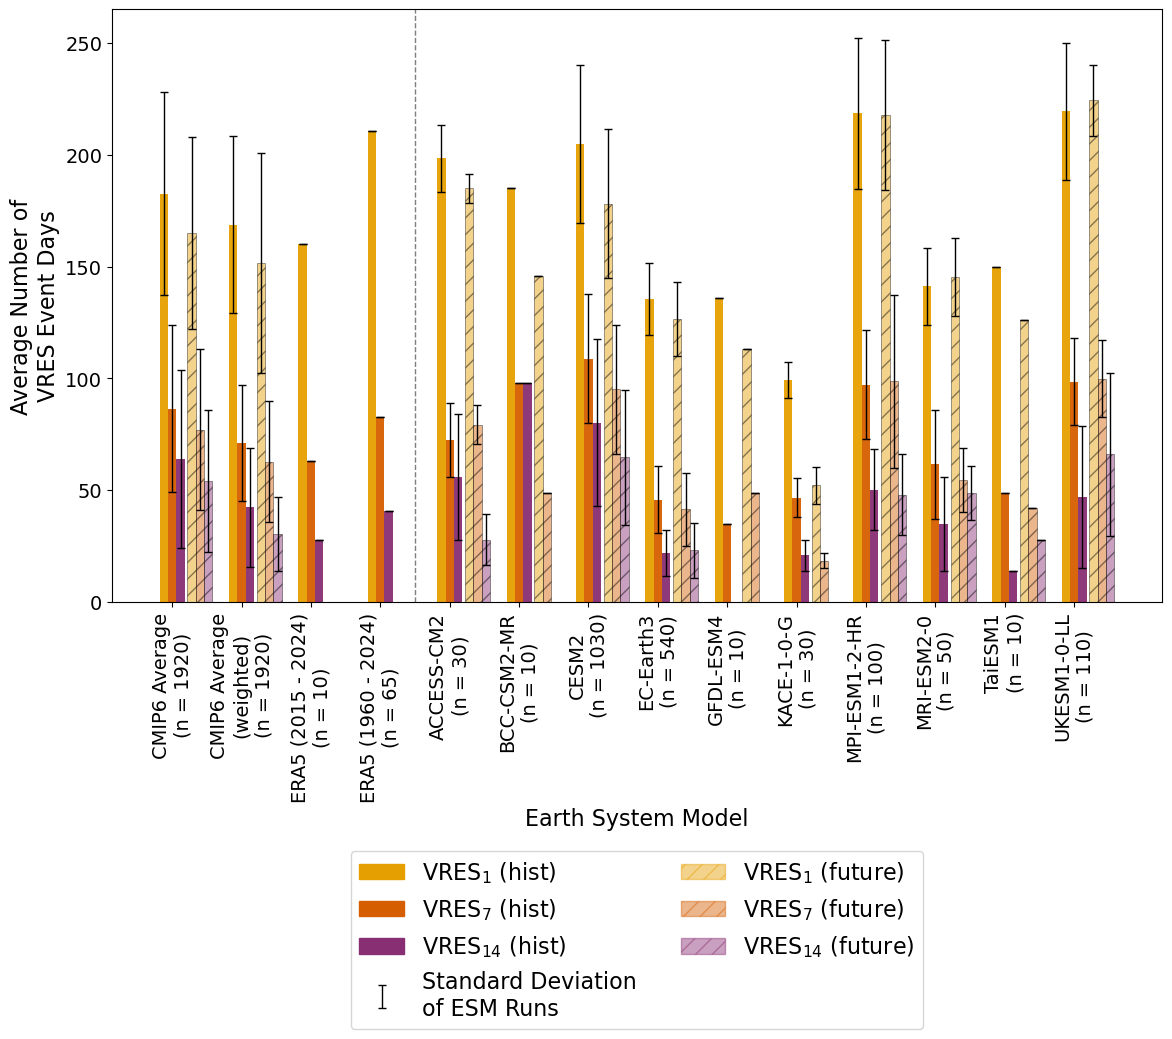

In [22]:

# ============================================================
# ------------------------ PLOTTING --------------------------
# ============================================================

mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
})

cols = ['LEE_vl_dur_avg', 'LEE_7_dur_avg', 'LEE_14_dur_avg']
cols_std = ['LEE_vl_dur_std', 'LEE_7_dur_std', 'LEE_14_dur_std']
colors = ['#E69F00', '#D55E00', '#882E72']

# # --- build dataframes --------------------------------------
df_hist = LEE_hist.set_index('ESM_label')[cols]
df_fut  = LEE_fut.set_index('ESM_label')[cols]
df_hist_std = LEE_hist.set_index('ESM_label')[cols_std]
df_fut_std  = LEE_fut.set_index('ESM_label')[cols_std]

# --- ordering (same as original) ---------------------------
# cmip_label = next(l for l in df_hist.index if 'CMIP6' in l)
# order = [cmip_label] + [l for l in df_hist.index if l != cmip_label]

# df_hist = df_hist.loc[order]
# df_fut  = df_fut.reindex(order)   # ERA5 → NaN (no crash)
# --- ordering: CMIP6, then ERA5, then the rest ----------------
cmip_label = next(l for l in df_hist.index if 'CMIP6' in l)
cmip_label_ave = next(l for l in df_hist.index if 'CMIP6 Average\n(weighted)' in l)
era_label  = next((l for l in df_hist.index if 'ERA5' in l), None)
era_label_15_24  = next((l for l in df_hist.index if '(2015 - 2024)' in l), None)
# print(cmip_label)
# print(era_label)
order = [cmip_label]
print(order)
if cmip_label_ave is not None:
    order.append(cmip_label_ave)
if era_label_15_24 is not None:
    order.append(era_label_15_24)
if era_label is not None:
    order.append(era_label)
print(order)

order += [l for l in df_hist.index if l not in order]

df_hist = df_hist.loc[order]
df_hist_std = df_hist_std.loc[order]
df_fut  = df_fut.reindex(order)   # ERA5 future stays NaN → fine
df_fut_std  = df_fut_std.reindex(order)
# ============================================================
# --------------------- BAR POSITIONS ------------------------
# ============================================================

n_groups = len(order)
x = np.arange(n_groups)

bar_w = 0.12            # individual bar width
group_gap = 0.04        # gap between hist and future triplets

# offsets: 3 hist bars, gap, 3 future bars
offsets_hist = np.array([-1, 0, 1]) * bar_w
offsets_fut  = np.array([2, 3, 4]) * bar_w + group_gap

fig, ax = plt.subplots(figsize=(12, 12))

# --- historical bars ---------------------------------------
for i, col in enumerate(cols):
    ax.bar(
        x + offsets_hist[i],
        df_hist[col].values,
        width=bar_w,
        color=colors[i],
        alpha=0.95,
        label=None
    )
    
    # Add error bars for historical data
    std_col = col.replace('avg', 'std') 
    ax.errorbar(
        x + offsets_hist[i],
        df_hist[col].values,
        yerr=df_hist_std[std_col].values,
        fmt='none',
        ecolor='black',
        capsize=3,
        elinewidth=1
    )

# --- future bars (hatched, lighter) ------------------------
for i, col in enumerate(cols):
    ax.bar(
        x + offsets_fut[i],
        df_fut[col].values,
        width=bar_w,
        color=colors[i],
        alpha=0.45,
        hatch='//',
        edgecolor='black',
        linewidth=0.6,
        label=None
    )
    
    # Add error bars for future data (if available)
    std_col = col.replace('avg', 'std')
    # print(df_fut[col].values)
    ax.errorbar(
        x + offsets_fut[i],
        df_fut[col].values,
        yerr=df_fut_std[std_col].values,
        fmt='none',
        ecolor='black',
        capsize=3,
        elinewidth=1
    )
    

# --- separator after CMIP6 ---------------------------------
# ax.axvline(x=0.5, color="#7E7E7E", linestyle='--', linewidth=1)
# --- separator after ERA5 (or after CMIP6 if ERA5 missing) ----
sep_pos = order.index(era_label) if era_label in order else order.index(cmip_label)
ax.axvline(x=sep_pos + 0.5, color="#7E7E7E", linestyle='--', linewidth=1)
# --- axes & labels -----------------------------------------
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=90)
ax.set_ylabel('Average Number of\nVRES Event Days')
ax.set_xlabel('Earth System Model')

# --- legend (same as original, plus note) ------------------
legend_labels = [
    r'$\mathrm{VRES}_{1}$ (hist)',
    r'$\mathrm{VRES}_{7}$ (hist)',
    r'$\mathrm{VRES}_{14}$ (hist)',
    'Standard Deviation\nof ESM Runs',
    r'$\mathrm{VRES}_{1}$ (future)',
    r'$\mathrm{VRES}_{7}$ (future)',
    r'$\mathrm{VRES}_{14}$ (future)'
]

handles = (
    [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors] +
    [plt.errorbar(np.nan, np.nan, yerr=1, fmt='none', ecolor='black', capsize=3, elinewidth=1)] +
    [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.45, hatch='//') for c in colors]
)

ax.legend(handles=handles, labels=legend_labels, loc='upper center', bbox_to_anchor=(0.5, -0.4), ncol=2)

plt.tight_layout()
# plt.savefig('/home/onennecke/Code/Figures/LEE_durations_comparison_with_weighted.png', dpi=300, bbox_inches='tight')
plt.show()


# VL Events analysis

In [19]:
LEE_vl['duration'].max()

np.int64(21)

In [21]:
# --- changed code: single smoothed histogram for LEE_vl['duration'] ---

bins = 120
figsize = (8,5)
color_fill = '#d9d9d9'
edge_color = '#111111'
fill_alpha = 1
lw_edge = 0.6

# keep text sizing consistent
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
    'figure.titlesize': 18,
})

# extract duration array
dur = np.asarray(LEE_vl['duration']).ravel()
dur_fut = np.asarray(LEE_vl_fut['duration']).ravel()
dur_ERA5_cur = np.asarray(LEE_vl_ERA5_15_24['duration']).ravel()
dur_ERA5_past = np.asarray(LEE_vl_ERA5_1960_['duration']).ravel()

# Number of years for each dataset
years = [1920, 1920, 10, 65]
labels = ['LEE_vl', 'LEE_vl_fut', 'LEE_vl_ERA5_cur', 'LEE_vl_ERA5_past']
colors = [color_fill, '#882E72', "#5AC430", '#111111']
alphas = [fill_alpha, 0.45, 0.45, 0.45]

# Flatten the duration arrays
datasets = [dur, dur_fut, dur_ERA5_cur, dur_ERA5_past]

# Generate bin edges (replace with your actual bin range)
bin_min, bin_max = 0, 22
bins = np.linspace(bin_min, bin_max, num=20)  # Adjust num as needed


In [36]:
print(len(counts))
len(bins)
counts

22


array([0.00000000e+00, 4.78854167e+00, 2.01093750e+00, 9.46354167e-01,
       4.92187500e-01, 2.65104167e-01, 1.52083333e-01, 1.04687500e-01,
       6.30208333e-02, 4.11458333e-02, 2.23958333e-02, 1.87500000e-02,
       9.37500000e-03, 4.68750000e-03, 2.60416667e-03, 3.64583333e-03,
       2.08333333e-03, 5.20833333e-04, 0.00000000e+00, 1.56250000e-03,
       1.04166667e-03, 5.20833333e-04])

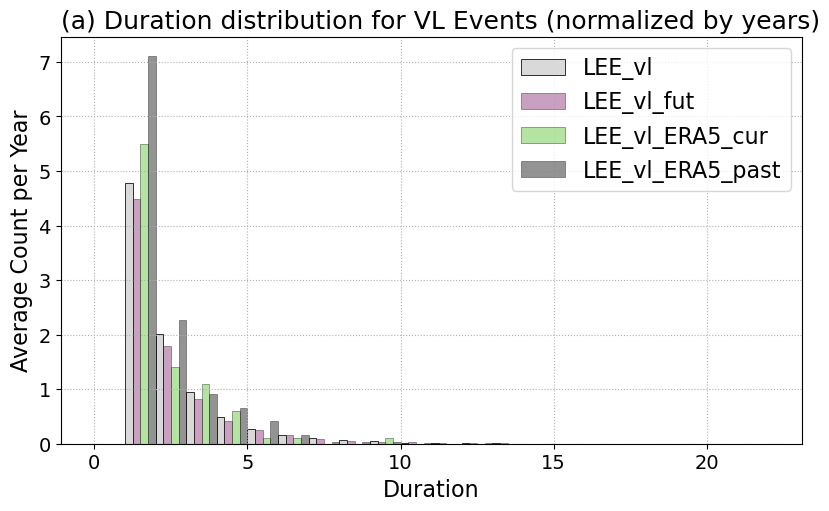

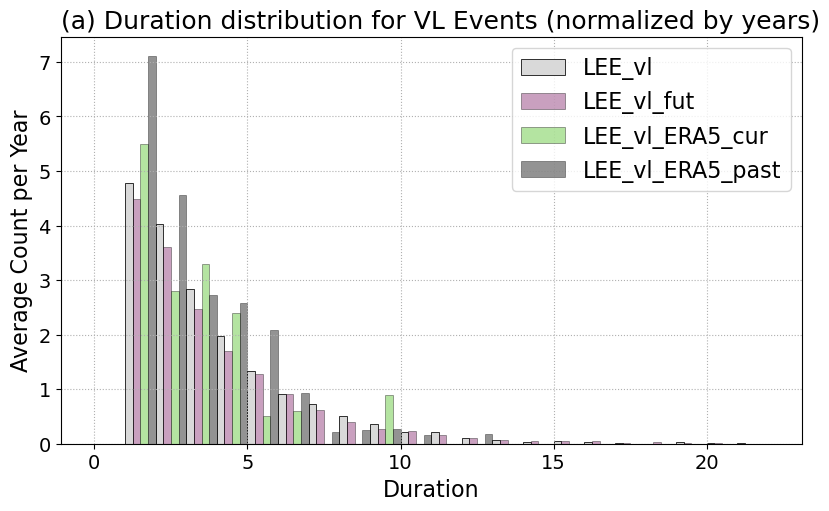

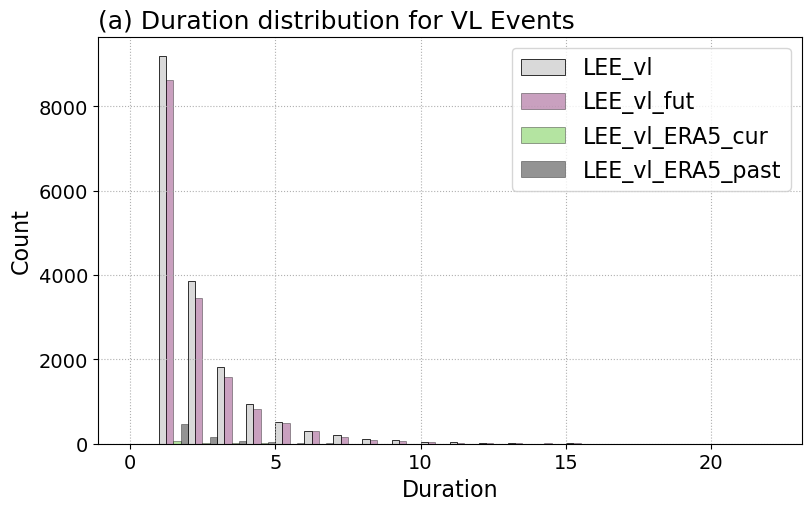

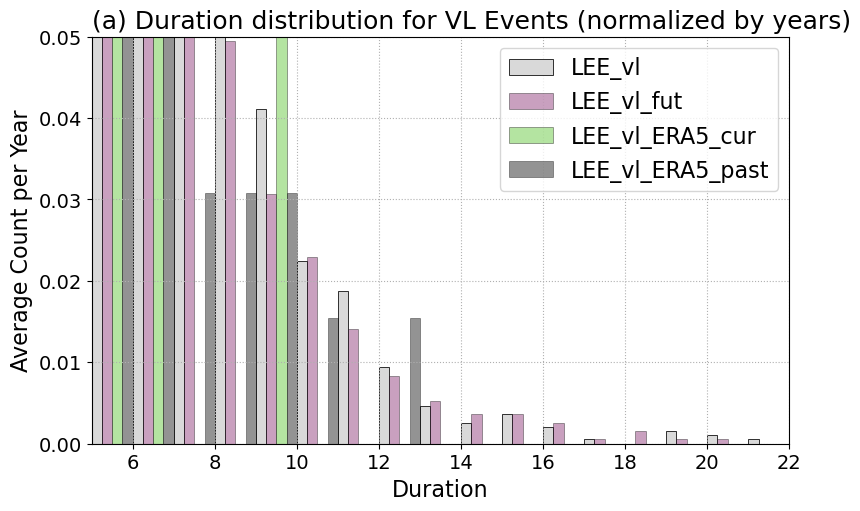

In [37]:


# Number of years for each dataset
years = [1920, 1920, 10, 65]
labels = ['LEE_vl', 'LEE_vl_fut', 'LEE_vl_ERA5_cur', 'LEE_vl_ERA5_past']
colors = [color_fill, '#882E72', "#5AC430", '#111111']
alphas = [fill_alpha, 0.45, 0.45, 0.45]

# Flatten the duration arrays
datasets = [dur, dur_fut, dur_ERA5_cur, dur_ERA5_past]

# Generate bin edges
bin_min, bin_max = 0, 22
bins = np.linspace(bin_min, bin_max, num=23)

# Plot
fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)

# Calculate the width for each bar
n_datasets = len(datasets)
spacing = (bins[1] - bins[0]) / n_datasets   # spacing between bar centers
bar_width = spacing                   # 10% gap

# Plot each histogram side by side
for i, (data, year, label, color, alpha) in enumerate(zip(datasets, years, labels, colors, alphas)):
    # Calculate the offset for this dataset
    offset = (i - n_datasets/2 + 0.5) * spacing
    # Create shifted bins for this dataset
    shifted_bins = bins + offset
    
    counts, _ = np.histogram(data, bins=bins, weights=np.ones_like(data)/year)

    centers = 0.5 * (bins[:-1] + bins[1:])
    ax.bar(
        centers + offset,
        counts,
        width=bar_width,
        color=color,
        alpha=alpha,
        edgecolor=edge_color,
        linewidth=lw_edge,
        label=label,
    )

ax.set_xlabel('Duration')
ax.set_ylabel('Average Count per Year')
ax.set_title("(a) Duration distribution for VL Events (normalized by years)", loc='left')
ax.grid(True, linestyle=':', alpha=1)
ax.legend()

plt.show()

# Plot
fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)

# Calculate the width for each bar
n_datasets = len(datasets)
spacing = (bins[1] - bins[0]) / n_datasets   # spacing between bar centers
bar_width = spacing                   # 10% gap

# Plot each histogram side by side
for i, (data, year, label, color, alpha) in enumerate(zip(datasets, years, labels, colors, alphas)):
    # Calculate the offset for this dataset
    offset = (i - n_datasets/2 + 0.5) * spacing
    # Create shifted bins for this dataset
    shifted_bins = bins + offset
    
    counts, _ = np.histogram(data, bins=bins, weights=np.ones_like(data)/year )

    # Multiply counts by the bin value
    counts = counts * bins[:-1]  # Multiply by the left edge of each bin

    centers = 0.5 * (bins[:-1] + bins[1:])
    ax.bar(
        centers + offset,
        counts,
        width=bar_width,
        color=color,
        alpha=alpha,
        edgecolor=edge_color,
        linewidth=lw_edge,
        label=label,
    )

ax.set_xlabel('Duration')
ax.set_ylabel('Average Count per Year')
ax.set_title("(a) Duration distribution for VL Events (normalized by years)", loc='left')
ax.grid(True, linestyle=':', alpha=1)
ax.legend()

plt.show()


# Plot
fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)

# Calculate the width for each bar
n_datasets = len(datasets)
spacing = (bins[1] - bins[0]) / n_datasets   # spacing between bar centers
bar_width = spacing                   # 10% gap

# Plot each histogram side by side
for i, (data, year, label, color, alpha) in enumerate(zip(datasets, years, labels, colors, alphas)):
    # Calculate the offset for this dataset
    offset = (i - n_datasets/2 + 0.5) * spacing
    # Create shifted bins for this dataset
    shifted_bins = bins + offset
    
    counts, _ = np.histogram(data, bins=bins)#, weights=np.ones_like(data)/year)

    centers = 0.5 * (bins[:-1] + bins[1:])
    ax.bar(
        centers + offset,
        counts,
        width=bar_width,
        color=color,
        alpha=alpha,
        edgecolor=edge_color,
        linewidth=lw_edge,
        label=label,
    )

ax.set_xlabel('Duration')
ax.set_ylabel('Count')
ax.set_title("(a) Duration distribution for VL Events ", loc='left')
ax.grid(True, linestyle=':', alpha=1)
ax.legend()

plt.show()




# Plot
fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)

# Calculate the width for each bar
n_datasets = len(datasets)
spacing = (bins[1] - bins[0]) / n_datasets   # spacing between bar centers
bar_width = spacing                   # 10% gap

# Plot each histogram side by side
for i, (data, year, label, color, alpha) in enumerate(zip(datasets, years, labels, colors, alphas)):
    # Calculate the offset for this dataset
    offset = (i - n_datasets/2 + 0.5) * spacing
    # Create shifted bins for this dataset
    shifted_bins = bins + offset
    
    counts, _ = np.histogram(data, bins=bins, weights=np.ones_like(data)/year)

    centers = 0.5 * (bins[:-1] + bins[1:])
    ax.bar(
        centers + offset,
        counts,
        width=bar_width,
        color=color,
        alpha=alpha,
        edgecolor=edge_color,
        linewidth=lw_edge,
        label=label,
    )

ax.set_ylim(0, 0.05)
ax.set_xlim(5, bin_max)
ax.set_xlabel('Duration')
ax.set_ylabel('Average Count per Year')
ax.set_title("(a) Duration distribution for VL Events (normalized by years)", loc='left')
ax.grid(True, linestyle=':', alpha=1)
ax.legend()

plt.show()



In [24]:
LEE_vl.sort_values(by='duration', ascending=False)

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy,winter_season
6763,2015-01-10,2015-01-30,2015-01-10 00:00:00.000000007,9,29,16,21,1464.164235,1405.166199,33.412016,29508.490189,6764,CESM2,CESM2_LE2-1281_007,2015,10,14/15
5422,2017-01-18,2017-02-06,2017-01-18 00:00:00.000000003,747,766,750,20,1462.379438,1374.811083,35.027894,27496.221663,5423,CESM2,CESM2_LE2-1251_013,2017,18,16/17
15418,2017-01-02,2017-01-21,2017-01-02 00:00:00.000000018,731,750,749,20,1457.396014,1401.686721,36.934278,28033.734427,15419,MPI-ESM1-2-HR,MPI-ESM1-2-HR_r8i1p1f1,2017,2,16/17
2295,2016-12-25,2017-01-12,2016-12-25 00:00:00.000000006,723,741,729,19,1518.537733,1447.241800,53.032482,27497.594203,2296,CESM2,CESM2_LE2-1191_010,2016,359,16/17
9754,2015-12-24,2016-01-11,2015-12-24 00:00:00.000000001,357,375,358,19,1506.933629,1444.042109,34.777140,27436.800072,9755,CESM2,CESM2_LE2-1301_019,2015,358,15/16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9266,2022-12-10,2022-12-10,2022-12-10 00:00:00.000000000,2898,2898,2898,1,1338.441262,1338.441262,0.000000,1338.441262,9267,CESM2,CESM2_LE2-1301_013,2022,344,22/23
9264,2022-11-24,2022-11-24,2022-11-24 00:00:00.000000000,2882,2882,2882,1,1372.073568,1372.073568,0.000000,1372.073568,9265,CESM2,CESM2_LE2-1301_013,2022,328,22/23
9263,2022-02-28,2022-02-28,2022-02-28 00:00:00.000000000,2613,2613,2613,1,1330.026721,1330.026721,0.000000,1330.026721,9264,CESM2,CESM2_LE2-1301_013,2022,59,21/22
9262,2022-02-13,2022-02-13,2022-02-13 00:00:00.000000000,2598,2598,2598,1,1353.507906,1353.507906,0.000000,1353.507906,9263,CESM2,CESM2_LE2-1301_013,2022,44,21/22


In [25]:
LEE_vl_fut.sort_values(by='duration', ascending=False)

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy,winter_season
14877,2032-12-15,2033-01-03,2032-12-15 00:00:00.000000018,1078,1097,1096,20,1477.290971,1434.812177,34.369354,28696.243531,14878,UKESM1-0-LL,UKESM1-0-LL_r1i1p1f2,2041,349,32/33
6878,2043-01-21,2043-02-08,2043-01-21 00:00:00.000000005,1480,1498,1485,19,1469.540934,1399.708974,38.558208,26594.470504,6879,CESM2,CESM2_LE2-1281_016,2043,21,42/43
4822,2047-01-06,2047-01-23,2047-01-06 00:00:00.000000003,2925,2942,2928,18,1471.579088,1414.380369,40.023358,25458.846638,4823,CESM2,CESM2_LE2-1251_012,2047,6,46/47
7896,2048-12-12,2048-12-29,2048-12-12 00:00:00.000000007,3630,3647,3637,18,1473.222962,1429.364961,38.166562,25728.569294,7897,CESM2,CESM2_LE2-1301_008,2048,346,48/49
522,2045-12-13,2045-12-30,2045-12-13 00:00:00.000000004,2536,2553,2540,18,1467.095402,1394.714379,44.765555,25104.858827,523,CESM2,CESM2_LE2-1011_001,2045,347,45/46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3574,2043-12-02,2043-12-02,2043-12-02 00:00:00.000000000,1795,1795,1795,1,1334.812870,1334.812870,0.000000,1334.812870,3575,CESM2,CESM2_LE2-1231_018,2043,336,43/44
3572,2043-02-06,2043-02-06,2043-02-06 00:00:00.000000000,1496,1496,1496,1,1340.566513,1340.566513,0.000000,1340.566513,3573,CESM2,CESM2_LE2-1231_018,2043,37,42/43
9364,2038-02-20,2038-02-20,2038-02-20 00:00:00.000000000,415,415,415,1,1330.819253,1330.819253,0.000000,1330.819253,9365,EC-Earth3,EC-Earth3_r106i1p1f1,2040,51,37/38
3570,2043-01-03,2043-01-03,2043-01-03 00:00:00.000000000,1462,1462,1462,1,1354.855017,1354.855017,0.000000,1354.855017,3571,CESM2,CESM2_LE2-1231_018,2043,3,42/43


In [26]:
LEE_vl_ERA5_15_24.sort_values(by='duration', ascending=False)


,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy,winter_season
14283,2022-12-08,2022-12-16,2022-12-08 00:00:00.000000008,2896,2904,2904,9,1486.441387,1402.043198,38.249508,12618.388783,14284,ERA5_week,ERA5_hist_week,2022,342,22/23
14211,2015-01-19,2015-01-24,2015-01-19 00:00:00.000000001,18,23,19,6,1439.293940,1385.690598,43.519127,8314.143589,14212,ERA5_week,ERA5_hist_week,2015,19,14/15
14233,2017-01-21,2017-01-25,2017-01-21 00:00:00.000000002,750,754,752,5,1470.397466,1429.738376,28.746800,7148.691879,14234,ERA5_week,ERA5_hist_week,2017,21,16/17
14220,2016-01-15,2016-01-18,2016-01-15 00:00:00.000000002,379,382,381,4,1412.025785,1370.237067,33.074269,5480.948269,14221,ERA5_week,ERA5_hist_week,2016,15,15/16
14226,2016-12-03,2016-12-06,2016-12-03 00:00:00.000000003,701,704,704,4,1401.158381,1381.312283,15.967032,5525.249131,14227,ERA5_week,ERA5_hist_week,2016,337,16/17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14286,2023-01-28,2023-01-28,2023-01-28 00:00:00.000000000,2947,2947,2947,1,1383.220249,1383.220249,0.000000,1383.220249,14287,ERA5_week,ERA5_hist_week,2023,28,22/23
14294,2024-11-02,2024-11-02,2024-11-02 00:00:00.000000000,3590,3590,3590,1,1325.394895,1325.394895,0.000000,1325.394895,14295,ERA5_week,ERA5_hist_week,2024,306,24/25
14293,2024-02-08,2024-02-08,2024-02-08 00:00:00.000000000,3323,3323,3323,1,1319.166494,1319.166494,0.000000,1319.166494,14294,ERA5_week,ERA5_hist_week,2024,39,23/24
14297,2024-11-29,2024-11-29,2024-11-29 00:00:00.000000000,3617,3617,3617,1,1362.511620,1362.511620,0.000000,1362.511620,14298,ERA5_week,ERA5_hist_week,2024,333,24/25


In [27]:
LEE_vl_ERA5_1960_.sort_values(by='duration', ascending=False)

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,winter_season
178,1973-01-01,1973-01-12,1973-01-01 00:00:00.000000003,4745,4756,4748,12,1462.266108,1396.537237,37.179937,16758.446850,179,ERA5_week,ERA5_hist_week,1973,-28/-27
134,1969-12-04,1969-12-13,1969-12-04 00:00:00.000000002,3622,3631,3624,10,1503.532015,1419.140661,46.808938,14191.406609,135,ERA5_week,ERA5_hist_week,1969,-31/-30
739,2022-12-08,2022-12-16,2022-12-08 00:00:00.000000008,22971,22979,22979,9,1486.441387,1402.043197,38.249508,12618.388775,740,ERA5_week,ERA5_hist_week,2022,22/23
401,1992-12-24,1993-01-01,1992-12-24 00:00:00.000000002,12037,12045,12039,9,1461.847293,1391.221573,42.214545,12520.994159,402,ERA5_week,ERA5_hist_week,1992,-8/-7
445,1996-12-06,1996-12-13,1996-12-06 00:00:00.000000005,13479,13486,13484,8,1456.644326,1389.753760,32.656570,11118.030079,446,ERA5_week,ERA5_hist_week,1996,-4/-3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8,1960-11-08,1960-11-08,1960-11-08 00:00:00.000000000,311,311,311,1,1373.949158,1373.949158,0.000000,1373.949158,9,ERA5_week,ERA5_hist_week,1960,-40/-39
13,1960-12-29,1960-12-29,1960-12-29 00:00:00.000000000,362,362,362,1,1397.336147,1397.336147,0.000000,1397.336147,14,ERA5_week,ERA5_hist_week,1960,-40/-39
14,1961-01-12,1961-01-12,1961-01-12 00:00:00.000000000,376,376,376,1,1329.113662,1329.113662,0.000000,1329.113662,15,ERA5_week,ERA5_hist_week,1961,-40/-39
15,1961-02-05,1961-02-05,1961-02-05 00:00:00.000000000,400,400,400,1,1322.912394,1322.912394,0.000000,1322.912394,16,ERA5_week,ERA5_hist_week,1961,-40/-39


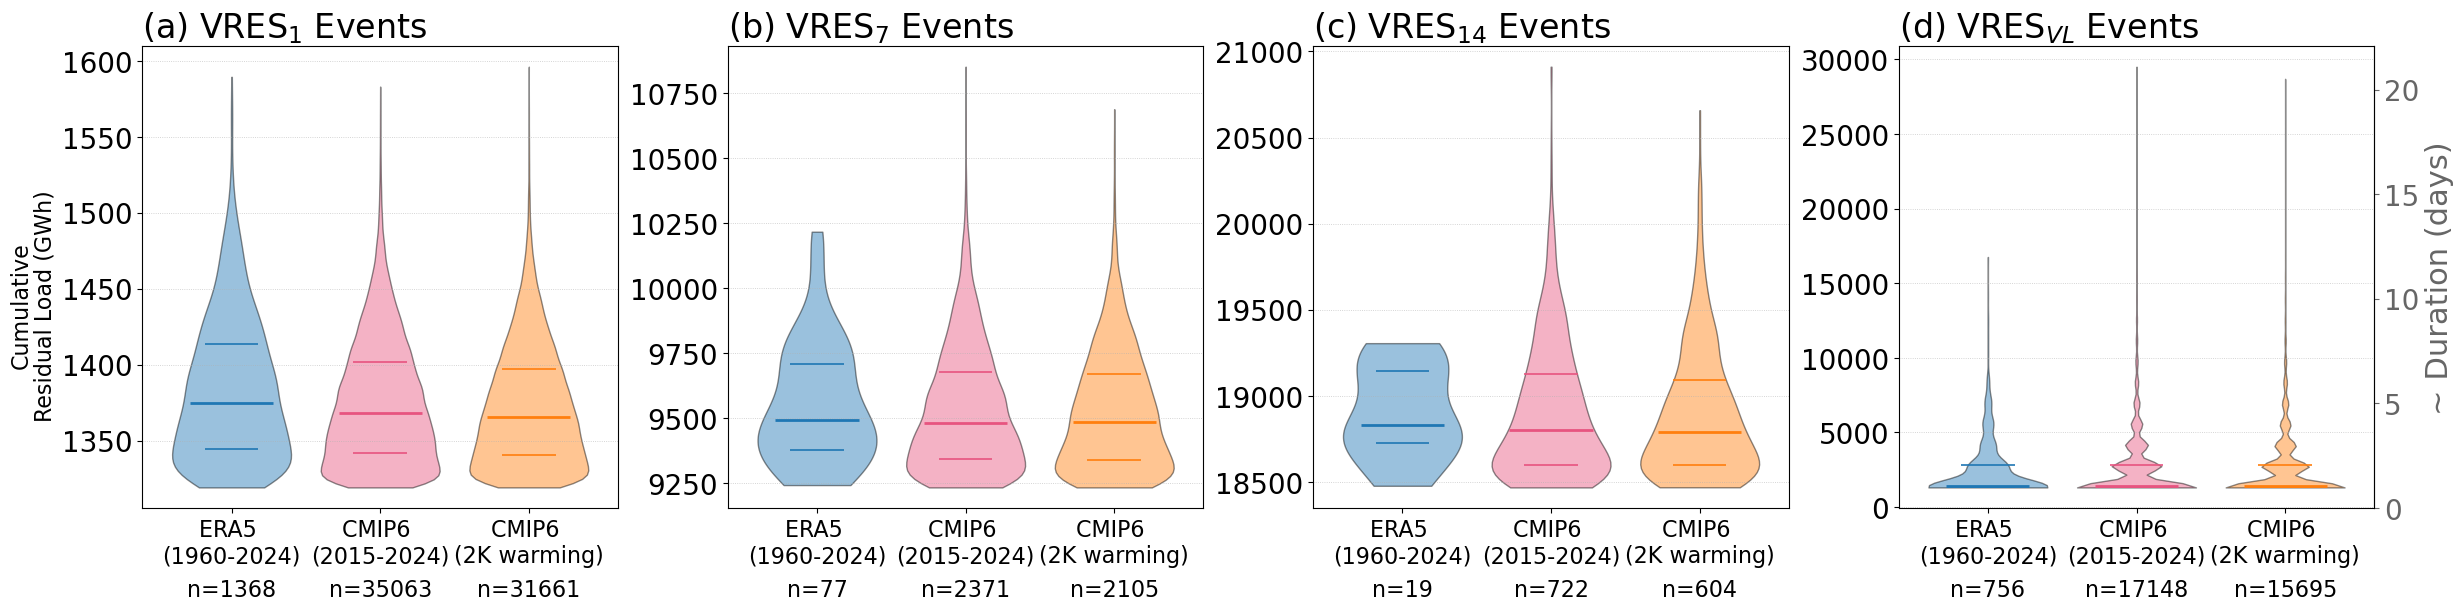

In [91]:
# keep text sizing consistent
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 24,
    'axes.labelsize': 22,
    'xtick.labelsize': 16,
    'ytick.labelsize': 20,
    'legend.fontsize': 22,
    'figure.titlesize': 26,
})

def plot_violin_with_secondary(
    cmip_1_hist, cmip_1_fut, era_1,
    cmip_7_hist, cmip_7_fut, era_7,
    cmip_14_hist, cmip_14_fut, era_14,
    cmip_vl_hist, cmip_vl_fut, era_vl,
    cmip_vl_dur_hist, cmip_vl_dur_fut, era_vl_dur,
    outpath=None,
    colors=None,
    figsize=(24, 6),
    title_suffix="",
):
    """
    4-panel violin plot: 1d, 7d, 14d, VL
    Layout: ERA5 left, then CMIP historical, then CMIP future
    """
    if colors is None:
        colors = ['#1f77b4', '#e75480', '#ff7f0e']  # ERA5, CMIP hist, CMIP fut

    datasets = [
        (cmip_1_hist, cmip_1_fut, era_1, r"(a) $\mathrm{VRES}_{1}$ Events"),
        (cmip_7_hist, cmip_7_fut, era_7, r"(b) $\mathrm{VRES}_{7}$ Events"),
        (cmip_14_hist, cmip_14_fut, era_14, r"(c) $\mathrm{VRES}_{14}$ Events"),
        (cmip_vl_hist, cmip_vl_fut, era_vl, r"(d) $\mathrm{VRES}_{VL}$ Events"),
    ]

    fig, axes = plt.subplots(1, 4, figsize=figsize, constrained_layout=True)

    for ax, (cmip_hist, cmip_fut, era, title) in zip(axes, datasets):
        # assemble dataset and positions
        data_list = [era]
        positions = [1]

        if cmip_hist is not None:
            data_list.append(cmip_hist)
            positions.append(2)
        if cmip_fut is not None:
            data_list.append(cmip_fut)
            positions.append(3)

        # plot violin
        parts = ax.violinplot(dataset=data_list, positions=positions,
                              vert=True, widths=0.8, showextrema=False, showmedians=False)

        # style violins
        for i, pc in enumerate(parts['bodies']):
            pc.set_facecolor(colors[i])
            pc.set_edgecolor('black')
            pc.set_alpha(0.45)

        # helper stats
        def safe_stats(arr):
            arr = np.asarray(arr)
            arr = arr[~np.isnan(arr)]
            return {
                'median': np.median(arr) if arr.size else np.nan,
                'q1': np.percentile(arr, 25) if arr.size else np.nan,
                'q3': np.percentile(arr, 75) if arr.size else np.nan,
                'min': np.min(arr) if arr.size else np.nan,
                'max': np.max(arr) if arr.size else np.nan,
                'n': arr.size,
            }

        stats_list = [safe_stats(d) for d in data_list]

        for i, pos in enumerate(positions):
            stats = stats_list[i]
            color = colors[i]
            if not np.isnan(stats['median']):
                ax.hlines(stats['median'], pos - 0.28, pos + 0.28, color=color, linewidth=2)
            if not np.isnan(stats['q1']) and not np.isnan(stats['q3']):
                ax.hlines(stats['q1'], pos - 0.18, pos + 0.18, color=color, linewidth=1.2)
                ax.hlines(stats['q3'], pos - 0.18, pos + 0.18, color=color, linewidth=1.2)
            if not np.isnan(stats['min']):
                ax.vlines(pos - 0.08, stats['min'], stats['min'], color=color, linewidth=2)
            if not np.isnan(stats['max']):
                ax.vlines(pos + 0.08, stats['max'], stats['max'], color=color, linewidth=2)
            ax.text(pos, -0.2, f"n={stats['n']}", transform=ax.get_xaxis_transform(),
                    ha='center', va='bottom', color='black')

        ax.set_xticks(positions)
        ax.set_xticklabels(['ERA5 \n(1960-2024)', 'CMIP6 \n(2015-2024)', 'CMIP6 \n(2K warming)'])
        ax.set_xlim(0.4, 3.6)
        ax.set_title(f"{title} {title_suffix}".strip(), loc='left')
        ax.grid(axis='y', linestyle=':', linewidth=0.6, alpha=0.7)

        ax.set_title(f"{title} {title_suffix}".strip(), loc='left')
        ax.grid(axis='y', linestyle=':', linewidth=0.6, alpha=0.7)

    
    # --- Add secondary axes for mean daily RL to panels 2 and 3 ---
    # for ax, divisor, label in zip(axes[1:3], [7, 14], ['7-day mean', '14-day mean']):
    #     secax = ax.secondary_yaxis('right', functions=(lambda y, d=divisor: y/d,
    #                                                 lambda y, d=divisor: y*d))
    #     secax.set_ylabel(f'Mean Daily RL ({label})')
    #     secax.spines['right'].set_color('#666666')
    #     secax.yaxis.label.set_color('#666666')
    #     secax.tick_params(axis='y', colors='#666666')
    #     secax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.5)
    
    # Secondary y-axis for VL
    ax_vl = axes[-1]

    X = np.concatenate([np.asarray(cmip_vl_hist).ravel(),
                        np.asarray(cmip_vl_fut).ravel(),
                        np.asarray(era_vl).ravel()])
    Y = np.concatenate([np.asarray(cmip_vl_dur_hist).ravel(),
                        np.asarray(cmip_vl_dur_fut).ravel(),
                        np.asarray(era_vl_dur).ravel()])
    mask = np.isfinite(X) & np.isfinite(Y)
    Xf, Yf = X[mask], Y[mask]

    slope, intercept = np.polyfit(Xf, Yf, 1)
    if abs(slope) < 1e-12:
        forward = lambda y: y
        inverse = lambda d: d
    else:
        forward = lambda y, a=slope, b=intercept: a*y + b
        inverse = lambda d, a=slope, b=intercept: (d - b)/a

    secax = ax_vl.secondary_yaxis('right', functions=(forward, inverse))
    secax.spines['right'].set_color('#666666')
    secax.yaxis.label.set_color('#666666')
    secax.tick_params(axis='y', colors='#666666')
    secax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.5)
    secax.set_ylabel('~ Duration (days)')

    fig.text(-0.02, 0.5, 'Cumulative', va='center', rotation='vertical')
    fig.text(-0.01, 0.5, 'Residual Load (GWh)', va='center', rotation='vertical')

    if outpath:
        plt.savefig(outpath, dpi=300, bbox_inches='tight')

    plt.show()
    return fig, axes
# Example usage (your variables should be defined in the namespace):
fig, axes = plot_violin_with_secondary(
    cmip_1_hist = LEE_dat_CMIP['RL_cumulative'],
    cmip_1_fut  = LEE_dat_fut['RL_cumulative'],  # or LEE_dat_CMIP
    era_1   = LEE_dat_ERA5['RL_cumulative'],
    cmip_7_hist = LEE_7_CMIP['RL_cumulative'],
    cmip_7_fut  = LEE_7_fut['RL_cumulative'],
    era_7   = LEE_7_ERA5['RL_cumulative'],
    cmip_14_hist = LEE_14_CMIP['RL_cumulative'],
    cmip_14_fut  = LEE_14_fut['RL_cumulative'],
    era_14  = LEE_14_ERA5['RL_cumulative'],
    cmip_vl_hist = LEE_vl_CMIP['RL_cumulative'],
    cmip_vl_fut  = LEE_vl_fut['RL_cumulative'],
    era_vl  = LEE_vl_ERA5['RL_cumulative'],
    cmip_vl_dur_hist = LEE_vl_CMIP['duration'],
    cmip_vl_dur_fut = LEE_vl_fut['duration'],
    era_vl_dur  = LEE_vl_ERA5['duration'],
    outpath='/home/onennecke/Code/Figures/VRES_RL_cumulative_violin_comparison.png',
)



Primary min: 1319.14, Primary max: 1596.22


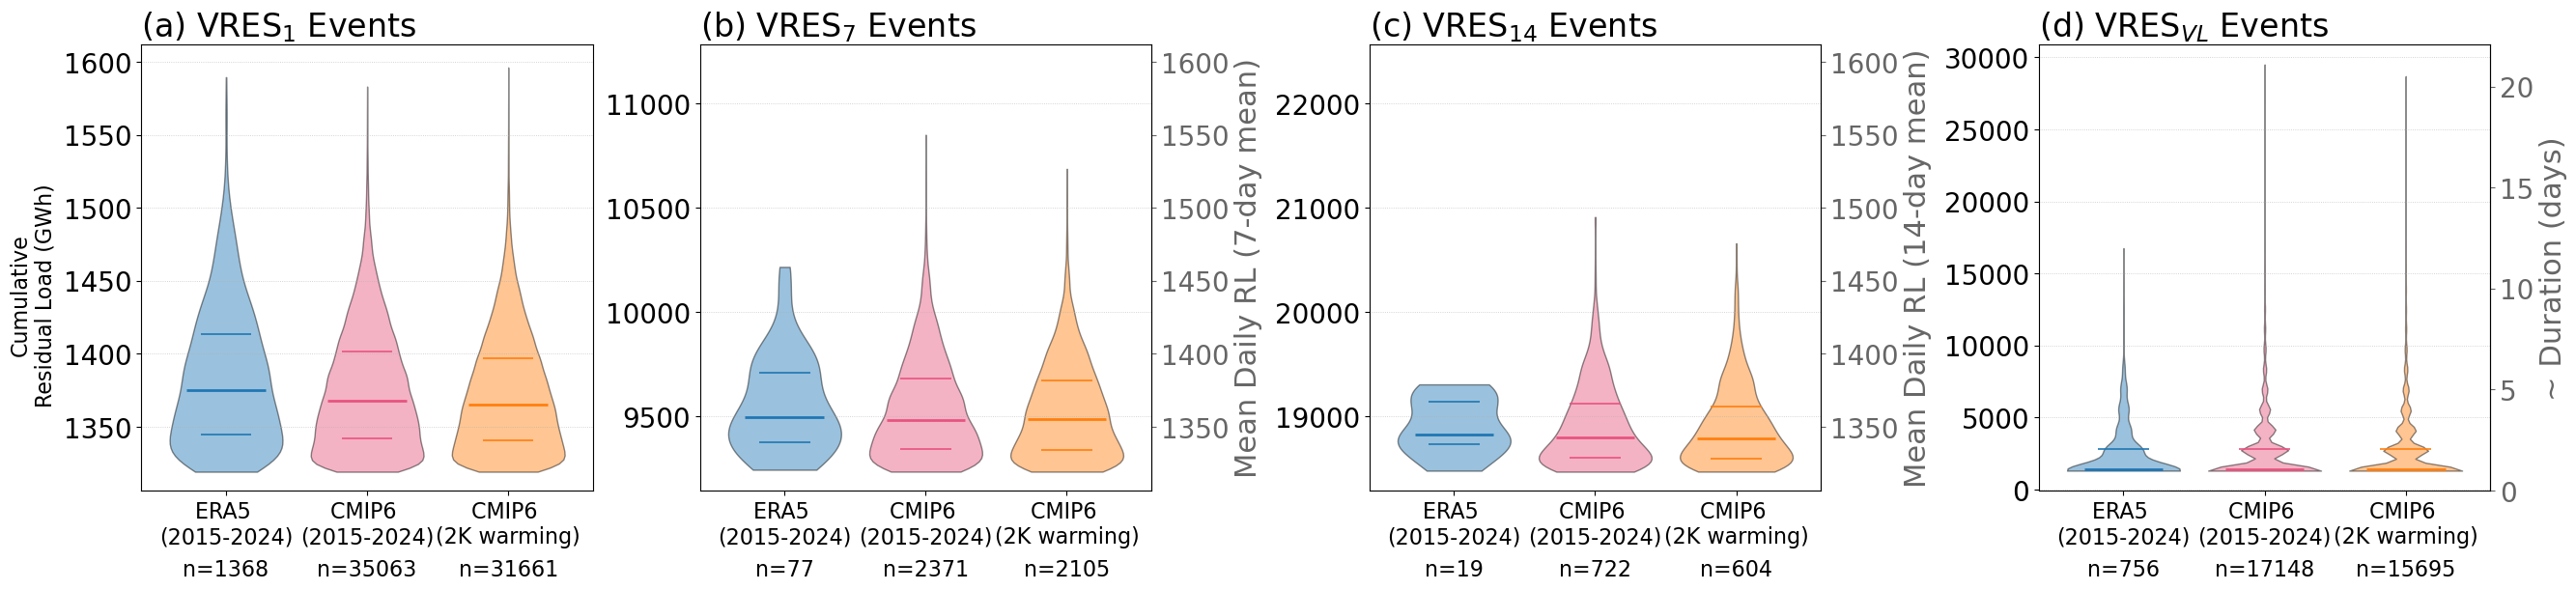

In [14]:
# keep text sizing consistent
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 24,
    'axes.labelsize': 22,
    'xtick.labelsize': 16,
    'ytick.labelsize': 20,
    'legend.fontsize': 22,
    'figure.titlesize': 26,
})

def plot_violin_with_secondary(
    cmip_1_hist, cmip_1_fut, era_1,
    cmip_7_hist, cmip_7_fut, era_7,
    cmip_14_hist, cmip_14_fut, era_14,
    cmip_vl_hist, cmip_vl_fut, era_vl,
    cmip_vl_dur_hist, cmip_vl_dur_fut, era_vl_dur,
    outpath=None,
    colors=None,
    figsize=(26, 6),
    title_suffix="",
):
    """
    4-panel violin plot: 1d, 7d, 14d, VL
    Layout: ERA5 left, then CMIP historical, then CMIP future
    """
    if colors is None:
        colors = ['#1f77b4', '#e75480', '#ff7f0e']  # ERA5, CMIP hist, CMIP fut

    datasets = [
        (cmip_1_hist, cmip_1_fut, era_1, r"(a) $\mathrm{VRES}_{1}$ Events"),
        (cmip_7_hist, cmip_7_fut, era_7, r"(b) $\mathrm{VRES}_{7}$ Events"),
        (cmip_14_hist, cmip_14_fut, era_14, r"(c) $\mathrm{VRES}_{14}$ Events"),
        (cmip_vl_hist, cmip_vl_fut, era_vl, r"(d) $\mathrm{VRES}_{VL}$ Events"),
    ]

    fig, axes = plt.subplots(1, 4, figsize=figsize, constrained_layout=True)

    for ax, (cmip_hist, cmip_fut, era, title) in zip(axes, datasets):
        # assemble dataset and positions
        data_list = [era]
        positions = [1]

        if cmip_hist is not None:
            data_list.append(cmip_hist)
            positions.append(2)
        if cmip_fut is not None:
            data_list.append(cmip_fut)
            positions.append(3)

        # plot violin
        parts = ax.violinplot(dataset=data_list, positions=positions,
                              vert=True, widths=0.8, showextrema=False, showmedians=False)

        # style violins
        for i, pc in enumerate(parts['bodies']):
            pc.set_facecolor(colors[i])
            pc.set_edgecolor('black')
            pc.set_alpha(0.45)

        # helper stats
        def safe_stats(arr):
            arr = np.asarray(arr)
            arr = arr[~np.isnan(arr)]
            return {
                'median': np.median(arr) if arr.size else np.nan,
                'q1': np.percentile(arr, 25) if arr.size else np.nan,
                'q3': np.percentile(arr, 75) if arr.size else np.nan,
                'min': np.min(arr) if arr.size else np.nan,
                'max': np.max(arr) if arr.size else np.nan,
                'n': arr.size,
            }

        stats_list = [safe_stats(d) for d in data_list]

        for i, pos in enumerate(positions):
            stats = stats_list[i]
            color = colors[i]
            if not np.isnan(stats['median']):
                ax.hlines(stats['median'], pos - 0.28, pos + 0.28, color=color, linewidth=2)
            if not np.isnan(stats['q1']) and not np.isnan(stats['q3']):
                ax.hlines(stats['q1'], pos - 0.18, pos + 0.18, color=color, linewidth=1.2)
                ax.hlines(stats['q3'], pos - 0.18, pos + 0.18, color=color, linewidth=1.2)
            if not np.isnan(stats['min']):
                ax.vlines(pos - 0.08, stats['min'], stats['min'], color=color, linewidth=2)
            if not np.isnan(stats['max']):
                ax.vlines(pos + 0.08, stats['max'], stats['max'], color=color, linewidth=2)
            ax.text(pos, -0.2, f"n={stats['n']}", transform=ax.get_xaxis_transform(),
                    ha='center', va='bottom', color='black')

        ax.set_xticks(positions)
        ax.set_xticklabels(['ERA5 \n(2015-2024)', 'CMIP6 \n(2015-2024)', 'CMIP6 \n(2K warming)'])
        ax.set_xlim(0.4, 3.6)
        ax.set_title(f"{title} {title_suffix}".strip(), loc='left')
        ax.grid(axis='y', linestyle=':', linewidth=0.6, alpha=0.7)

        ax.set_title(f"{title} {title_suffix}".strip(), loc='left')
        ax.grid(axis='y', linestyle=':', linewidth=0.6, alpha=0.7)

    
    # --- Add secondary axes for mean daily RL to panels 2 and 3 ---
    for ax, divisor, label in zip(axes[1:3], [7, 14], ['7-day mean', '14-day mean']):
        secax = ax.secondary_yaxis('right', functions=(lambda y, d=divisor: y/d,
                                                    lambda y, d=divisor: y*d))
        secax.set_ylabel(f'Mean Daily RL ({label})')
        secax.spines['right'].set_color('#666666')
        secax.yaxis.label.set_color('#666666')
        secax.tick_params(axis='y', colors='#666666')
        secax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.5)
    
    # --- Determine common y-limits for panels 1-3 ---
    # Get primary min for first panel
    y1_min = np.nanmin(np.concatenate([np.asarray(cmip_1_hist),
                                    np.asarray(cmip_1_fut),
                                    np.asarray(era_1)]))

    # Get secondary min for panels 2 and 3
    y2_min = np.nanmin(np.concatenate([
                np.asarray(cmip_7_hist)/7 if cmip_7_hist is not None else [],
                np.asarray(cmip_7_fut)/7 if cmip_7_fut is not None else [],
                np.asarray(era_7)/7,
                np.asarray(cmip_14_hist)/14 if cmip_14_hist is not None else [],
                np.asarray(cmip_14_fut)/14 if cmip_14_fut is not None else [],
                np.asarray(era_14)/14
            ]))
    # Get primary max for first panel
    y1_max = max(np.nanmax(np.concatenate([np.asarray(cmip_1_hist), np.asarray(cmip_1_fut), np.asarray(era_1)])), 0)

    # Get secondary max for panels 2 and 3
    y2_max = max(np.nanmax(np.concatenate([np.asarray(cmip_7_hist)/7 if cmip_7_hist is not None else [],
                                        np.asarray(cmip_7_fut)/7 if cmip_7_fut is not None else [],
                                        np.asarray(era_7)/7])),
                np.nanmax(np.concatenate([np.asarray(cmip_14_hist)/14 if cmip_14_hist is not None else [],
                                        np.asarray(cmip_14_fut)/14 if cmip_14_fut is not None else [],
                                        np.asarray(era_14)/14])))
    print(f"Primary min: {y1_min:.2f}, Primary max: {y1_max:.2f}")
    common_ylim = (min(y1_min, y2_min)*0.99, max(y1_max, y2_max)*1.01)  # slight padding

    # Apply to first three axes
    axes[0].set_ylim(common_ylim)  # primary y for panel 1
    axes[1].set_ylim(common_ylim[0]*7, common_ylim[1]*7)  # scale back to primary y
    axes[2].set_ylim(common_ylim[0]*14, common_ylim[1]*14)
    
    # Secondary y-axis for VL
    ax_vl = axes[-1]

    X = np.concatenate([np.asarray(cmip_vl_hist).ravel(),
                        np.asarray(cmip_vl_fut).ravel(),
                        np.asarray(era_vl).ravel()])
    Y = np.concatenate([np.asarray(cmip_vl_dur_hist).ravel(),
                        np.asarray(cmip_vl_dur_fut).ravel(),
                        np.asarray(era_vl_dur).ravel()])
    mask = np.isfinite(X) & np.isfinite(Y)
    Xf, Yf = X[mask], Y[mask]

    slope, intercept = np.polyfit(Xf, Yf, 1)
    if abs(slope) < 1e-12:
        forward = lambda y: y
        inverse = lambda d: d
    else:
        forward = lambda y, a=slope, b=intercept: a*y + b
        inverse = lambda d, a=slope, b=intercept: (d - b)/a

    secax = ax_vl.secondary_yaxis('right', functions=(forward, inverse))
    secax.spines['right'].set_color('#666666')
    secax.yaxis.label.set_color('#666666')
    secax.tick_params(axis='y', colors='#666666')
    secax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.5)
    secax.set_ylabel('~ Duration (days)')

    fig.text(-0.02, 0.5, 'Cumulative', va='center', rotation='vertical')
    fig.text(-0.01, 0.5, 'Residual Load (GWh)', va='center', rotation='vertical')

    if outpath:
        plt.savefig(outpath, dpi=300, bbox_inches='tight')

    plt.show()
    return fig, axes
# Example usage (your variables should be defined in the namespace):
fig, axes = plot_violin_with_secondary(
    cmip_1_hist = LEE_dat_CMIP['RL_cumulative'],
    cmip_1_fut  = LEE_dat_fut['RL_cumulative'],  # or LEE_dat_CMIP
    era_1   = LEE_dat_ERA5['RL_cumulative'],
    cmip_7_hist = LEE_7_CMIP['RL_cumulative'],
    cmip_7_fut  = LEE_7_fut['RL_cumulative'],
    era_7   = LEE_7_ERA5['RL_cumulative'],
    cmip_14_hist = LEE_14_CMIP['RL_cumulative'],
    cmip_14_fut  = LEE_14_fut['RL_cumulative'],
    era_14  = LEE_14_ERA5['RL_cumulative'],
    cmip_vl_hist = LEE_vl_CMIP['RL_cumulative'],
    cmip_vl_fut  = LEE_vl_fut['RL_cumulative'],
    era_vl  = LEE_vl_ERA5['RL_cumulative'],
    cmip_vl_dur_hist = LEE_vl_CMIP['duration'],
    cmip_vl_dur_fut = LEE_vl_fut['duration'],
    era_vl_dur  = LEE_vl_ERA5['duration'],
    # outpath='/home/onennecke/Code/Figures/VRES_RL_cumulative_violin_comparison.png',
)



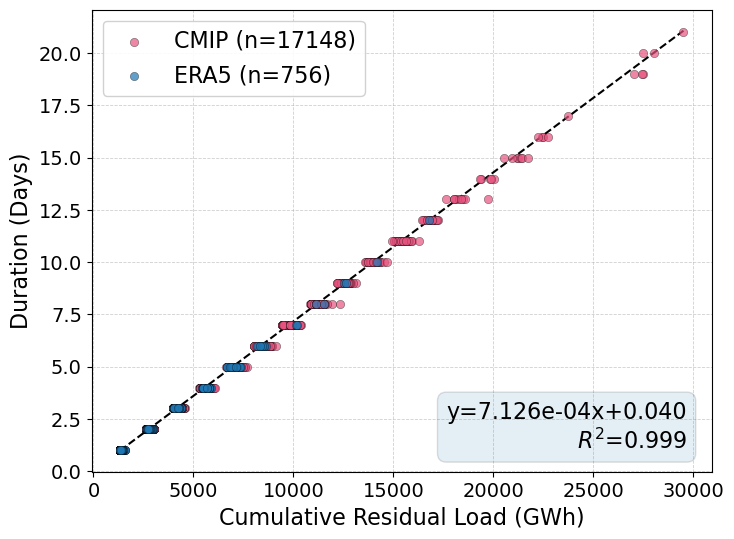

(<Figure size 800x600 with 1 Axes>,
 <Axes: xlabel='Cumulative Residual Load (GWh)', ylabel='Duration (Days)'>)

In [90]:
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
    'figure.titlesize': 18,
})

# If you have scipy you can compute a more formal r-value; otherwise we compute R^2 manually
try:
    from scipy.stats import linregress
    _have_scipy = True
except Exception:
    _have_scipy = False

def scatter_rl_vs_duration(
    cmip_rl, cmip_dur,
    era_rl, era_dur,
    figsize=(8,6),
    colors=['#e75480', '#1f77b4'],
    title="VL events: cumulative RL vs duration",
    outpath=None
):
    # flatten and clean
    cmip_rl = np.asarray(cmip_rl).ravel()
    cmip_dur = np.asarray(cmip_dur).ravel()
    era_rl  = np.asarray(era_rl).ravel()
    era_dur = np.asarray(era_dur).ravel()

    mask_cmip = np.isfinite(cmip_rl) & np.isfinite(cmip_dur)
    mask_era  = np.isfinite(era_rl)  & np.isfinite(era_dur)

    x_cmip = cmip_rl[mask_cmip]
    y_cmip = cmip_dur[mask_cmip]
    x_era  = era_rl[mask_era]
    y_era  = era_dur[mask_era]

    # combined
    x_all = np.concatenate([x_cmip, x_era])
    y_all = np.concatenate([y_cmip, y_era])

    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(x_cmip, y_cmip, label=f'CMIP (n={x_cmip.size})', c=colors[0], alpha=0.7, edgecolor='k', linewidth=0.3, zorder=3)
    ax.scatter(x_era, y_era, label=f'ERA5 (n={x_era.size})', c=colors[1], alpha=0.7, edgecolor='k', linewidth=0.3, zorder=3)

    # Fit lines: combined and per-dataset
    def fit_and_plot(x, y, label, color, linestyle='-'):
        if x.size < 2:
            return None
        if _have_scipy:
            lr = linregress(x, y)
            slope, intercept, r2 = lr.slope, lr.intercept, lr.rvalue**2
        else:
            slope, intercept = np.polyfit(x, y, 1)
            ypred = slope * x + intercept
            ss_res = np.sum((y - ypred)**2)
            ss_tot = np.sum((y - np.mean(y))**2)
            r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

        xs = np.linspace(np.nanmin(x_all), np.nanmax(x_all), 200)
        ax.plot(xs, slope * xs + intercept, linestyle=linestyle, color=color, linewidth=1.5, zorder=2)#,
                # label=f"{label} fit: y={slope:.3e}x+{intercept:.3f}, $R^2$={r2:.3f}", linewidth=1.5, zorder=2)
        return slope, intercept, r2

    fit_all = fit_and_plot(x_all, y_all, 'Combined', '#000000', linestyle='--')
    # fit_cmip = fit_and_plot(x_cmip, y_cmip, 'CMIP', colors[0], linestyle='--')
    # fit_era  = fit_and_plot(x_era, y_era, 'ERA5', colors[1], linestyle=':')

    ax.set_xlabel('Cumulative Residual Load (GWh)')
    ax.set_ylabel('Duration (Days)')
    # ax.set_title(title)
    ax.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
    ax.legend(loc='best', framealpha=0.9)

    # small textbox with combined-fit stats to make it explicit
    if fit_all is not None:
        s, i, r2 = fit_all
        ax.text(0.96, 0.04, f"y={s:.3e}x+{i:.3f}\n$R^2$={r2:.3f}",
                transform=ax.transAxes, ha='right', va='bottom',
                bbox=dict(boxstyle="round,pad=0.4", alpha=0.12))

    if outpath:
        plt.savefig(outpath, dpi=300, bbox_inches='tight')
    plt.show()
    return fig, ax

# Example call (replace with your arrays):
scatter_rl_vs_duration(
    cmip_rl = LEE_vl_CMIP['RL_cumulative'],
    cmip_dur = LEE_vl_CMIP['duration'],
    era_rl  = LEE_vl_ERA5['RL_cumulative'],
    era_dur = LEE_vl_ERA5['duration'],
    outpath='/home/onennecke/Code/Figures/LEE_vl_RL_vs_duration_fit.png'
)


In [20]:
LEE_dat_CMIP['RL_cumulative']

0        1347.755832
1        1333.134503
2        1395.107358
3        1409.547842
4        1403.974418
            ...     
35218    1455.111286
35219    1433.341128
35220    1392.939718
35221    1506.619573
35222    1319.565575
Name: RL_cumulative, Length: 35063, dtype: float64

In [21]:
LEE_dat_CMIP

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2015-01-05,2015-01-05,2015-01-05,4,4,4,1,1347.755832,1347.755832,0.0,1347.755832,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,5
1,2015-01-07,2015-01-07,2015-01-07,6,6,6,1,1333.134503,1333.134503,0.0,1333.134503,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,7
2,2015-01-08,2015-01-08,2015-01-08,7,7,7,1,1395.107358,1395.107358,0.0,1395.107358,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,8
3,2015-01-18,2015-01-18,2015-01-18,17,17,17,1,1409.547842,1409.547842,0.0,1409.547842,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,18
4,2015-01-19,2015-01-19,2015-01-19,18,18,18,1,1403.974418,1403.974418,0.0,1403.974418,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35218,2024-12-20,2024-12-20,2024-12-20,3638,3638,3638,1,1455.111286,1455.111286,0.0,1455.111286,35219,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,354
35219,2024-12-21,2024-12-21,2024-12-21,3639,3639,3639,1,1433.341128,1433.341128,0.0,1433.341128,35220,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,355
35220,2024-12-25,2024-12-25,2024-12-25,3643,3643,3643,1,1392.939718,1392.939718,0.0,1392.939718,35221,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,359
35221,2024-12-30,2024-12-30,2024-12-30,3648,3648,3648,1,1506.619573,1506.619573,0.0,1506.619573,35222,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,364


# Return time plots

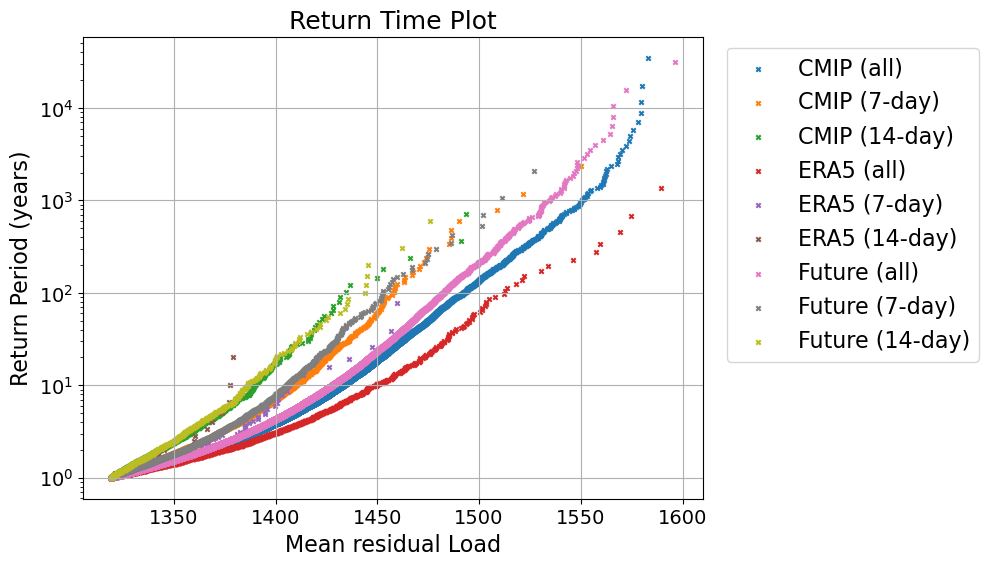

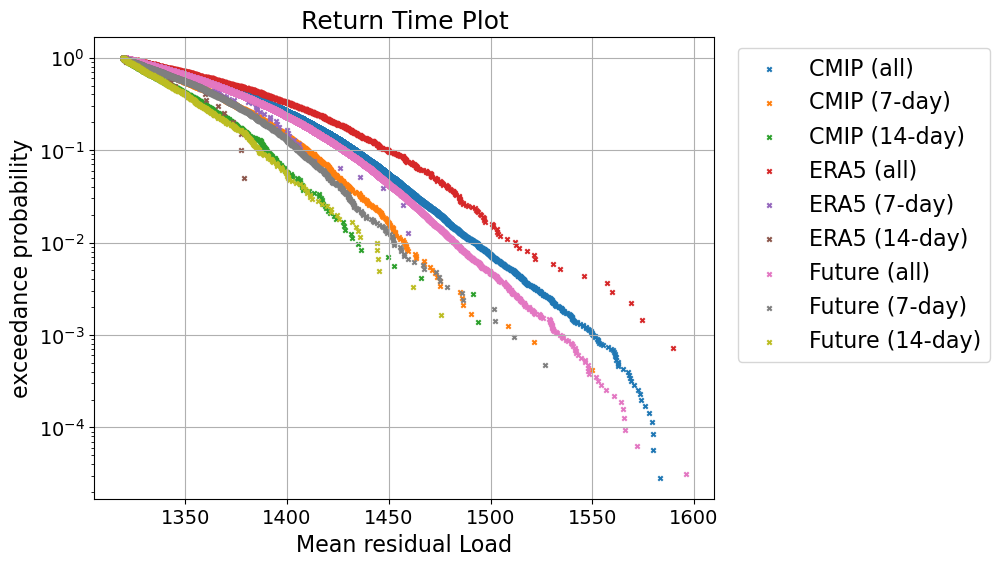

In [16]:
## Here problem: Observational period are only the length of extremes --> not realistic

LEEs = [LEE_dat_CMIP, LEE_7_CMIP, LEE_14_CMIP, LEE_dat_ERA5, LEE_7_ERA5, LEE_14_ERA5, LEE_dat_fut, LEE_7_fut, LEE_14_fut]
# LEEs = [LEE_dat_CMIP, LEE_dat_ERA5, LEE_dat_fut]

LEEs = [
    LEE_dat_CMIP, LEE_7_CMIP, LEE_14_CMIP,
    LEE_dat_ERA5, LEE_7_ERA5, LEE_14_ERA5,
    LEE_dat_fut, LEE_7_fut, LEE_14_fut
]

labels = [
    'CMIP (all)', 'CMIP (7-day)', 'CMIP (14-day)',
    'ERA5 (all)', 'ERA5 (7-day)', 'ERA5 (14-day)',
    'Future (all)', 'Future (7-day)', 'Future (14-day)'
]

# Plot
plt.figure(figsize=(8,6))

for LEE, label in zip(LEEs, labels):
    
    extremes = LEE['RL_mean']  # your event values

    # Sort descending
    x = np.sort(extremes)[::-1]

    # Rank
    m = np.arange(1, len(x) + 1)

    # Total observation period (important!)
    N = len(extremes)  # OR number of years, depending on method

    # Return period
    T = (N + 1) / m

    plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1
plt.yscale('log')
plt.ylabel('Return Period (years)')
plt.xlabel('Mean residual Load')
plt.title('Return Time Plot')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.grid(True)
plt.show()

# Plot
plt.figure(figsize=(8,6))

for LEE, label in zip(LEEs, labels):
    
    extremes = LEE['RL_mean']  # your event values

    # Sort ascending
    x = np.sort(extremes)

    # Rank
    m = np.arange(1, len(x) + 1)

    # Total observation period (important!)
    N = len(extremes)  # OR number of years, depending on method

    # Return period
    # T = (N + 1) / (N + 1 - m)
    T = (1 - (m/(N+1)))  # equivalent, more direct formula
    
    plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1
plt.yscale('log')
# plt.xscale('log')
plt.ylabel('exceedance probability')
plt.xlabel('Mean residual Load')
plt.title('Return Time Plot')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.grid(True)
plt.show()


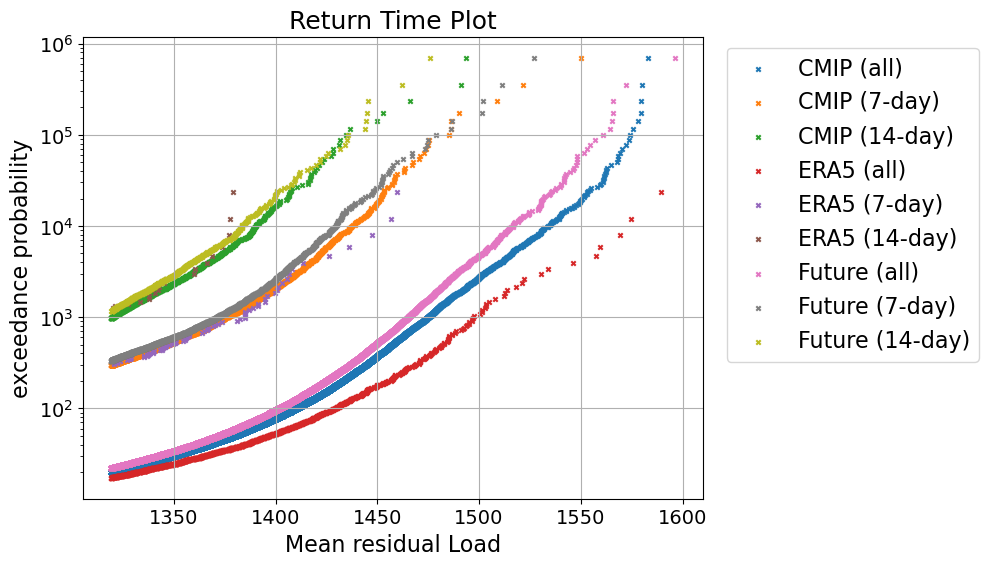

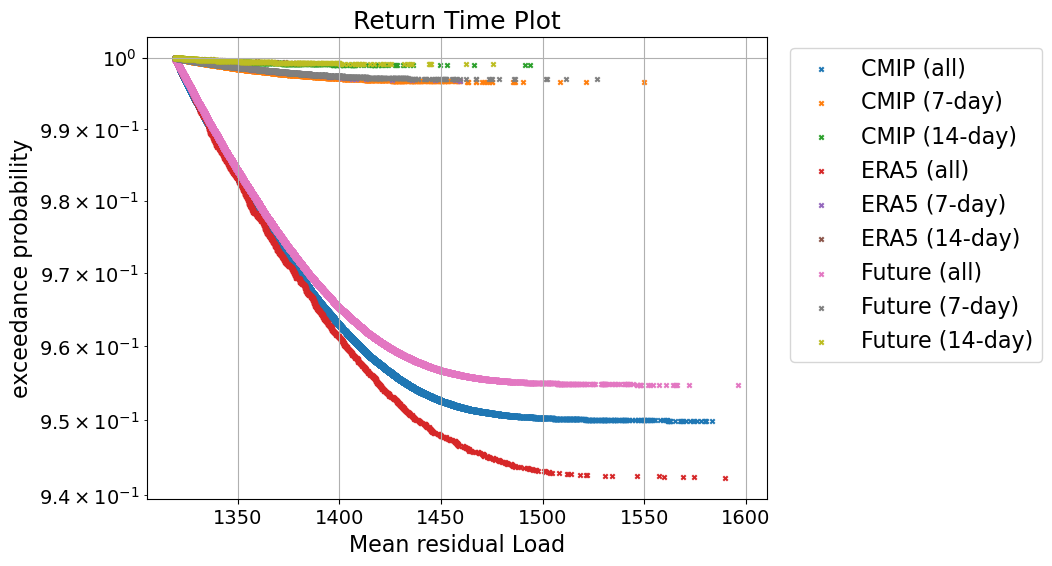

In [17]:
## Here: Observational period are appropriately long for CMIP and ERA5, but same for all LEE types (not ideal but better than before)

LEEs = [LEE_dat_CMIP, LEE_7_CMIP, LEE_14_CMIP, LEE_dat_ERA5, LEE_7_ERA5, LEE_14_ERA5, LEE_dat_fut, LEE_7_fut, LEE_14_fut]
# LEEs = [LEE_dat_CMIP, LEE_dat_ERA5, LEE_dat_fut]

LEEs = [
    LEE_dat_CMIP, LEE_7_CMIP, LEE_14_CMIP,
    LEE_dat_ERA5, LEE_7_ERA5, LEE_14_ERA5,
    LEE_dat_fut, LEE_7_fut, LEE_14_fut
]

labels = [
    'CMIP (all)', 'CMIP (7-day)', 'CMIP (14-day)',
    'ERA5 (all)', 'ERA5 (7-day)', 'ERA5 (14-day)',
    'Future (all)', 'Future (7-day)', 'Future (14-day)'
]

# Plot
plt.figure(figsize=(8,6))

for LEE, label in zip(LEEs, labels):
    
    extremes = LEE['RL_mean']  # your event values

    # Sort descending
    x = np.sort(extremes)[::-1]

    # Rank
    m = np.arange(1, len(x) + 1)

    # Total observation period (important!)
    if 'ERA5' in label:
        N = 365 * 65 # len(extremes)  # OR number of years, depending on method
    else:
        N = 365 * 10 * 192 # len(extremes)  # OR number of years, depending on method
    # print(f"{label}: N={N}, number of events={len(extremes)}")
    # if 'ERA5' in label:
    #     N = len(extremes) * 20  # OR number of years, depending on method
    # else:
    #     N = len(extremes) *20  # OR number of years, depending on method

    # Return period
    T = (N + 1) / m
    # T = m / (N + 1)  # exceedance probability

    # T = (N + 1) / (N + 1 - m)
    # Calculate exceedance probability    
    # T = (1 - (m/(N+1)))  # equivalent, more direct formula
    # T = 1 - (N + 1) / m
    
    
    plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1
plt.yscale('log')
plt.ylabel('exceedance probability')
plt.xlabel('Mean residual Load')
plt.title('Return Time Plot')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.grid(True)
plt.show()

# Plot
plt.figure(figsize=(8,6))

for LEE, label in zip(LEEs, labels):
    
    extremes = LEE['RL_mean']  # your event values

    # Sort ascending
    x = np.sort(extremes)

    # Rank
    m = np.arange(1, len(x) + 1)

    # Total observation period (important!)
    if 'ERA5' in label:
        N = 365 * 65 # len(extremes)  # OR number of years, depending on method
    else:
        N = 365 * 10 * 192 # len(extremes)  # OR number of years, depending on method

    # Return period
    # T = (N + 1) / m

    # T = (N + 1) / (N + 1 - m)
    # Calculate exceedance probability    
    # T = (1 - (m/(N+1)))  # equivalent, more direct formula
    # T = 1 - (N + 1) / m
    T = (1 - (m/(N+1)))
    # T = 1 / (1- (m / (N + 1)))
    
    plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1
plt.yscale('log')
plt.ylabel('exceedance probability')
plt.xlabel('Mean residual Load')
plt.title('Return Time Plot')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.grid(True)
plt.show()

In [11]:
print(35063*20)
print(1568*20)
print(31661*20)


701260
31360
633220


/tmp/ipykernel_3874954/1038781896.py:48: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax_main.set_xlim(0, max_rp)
/tmp/ipykernel_3874954/1038781896.py:48: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax_main.set_xlim(0, max_rp)
/tmp/ipykernel_3874954/1038781896.py:48: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax_main.set_xlim(0, max_rp)


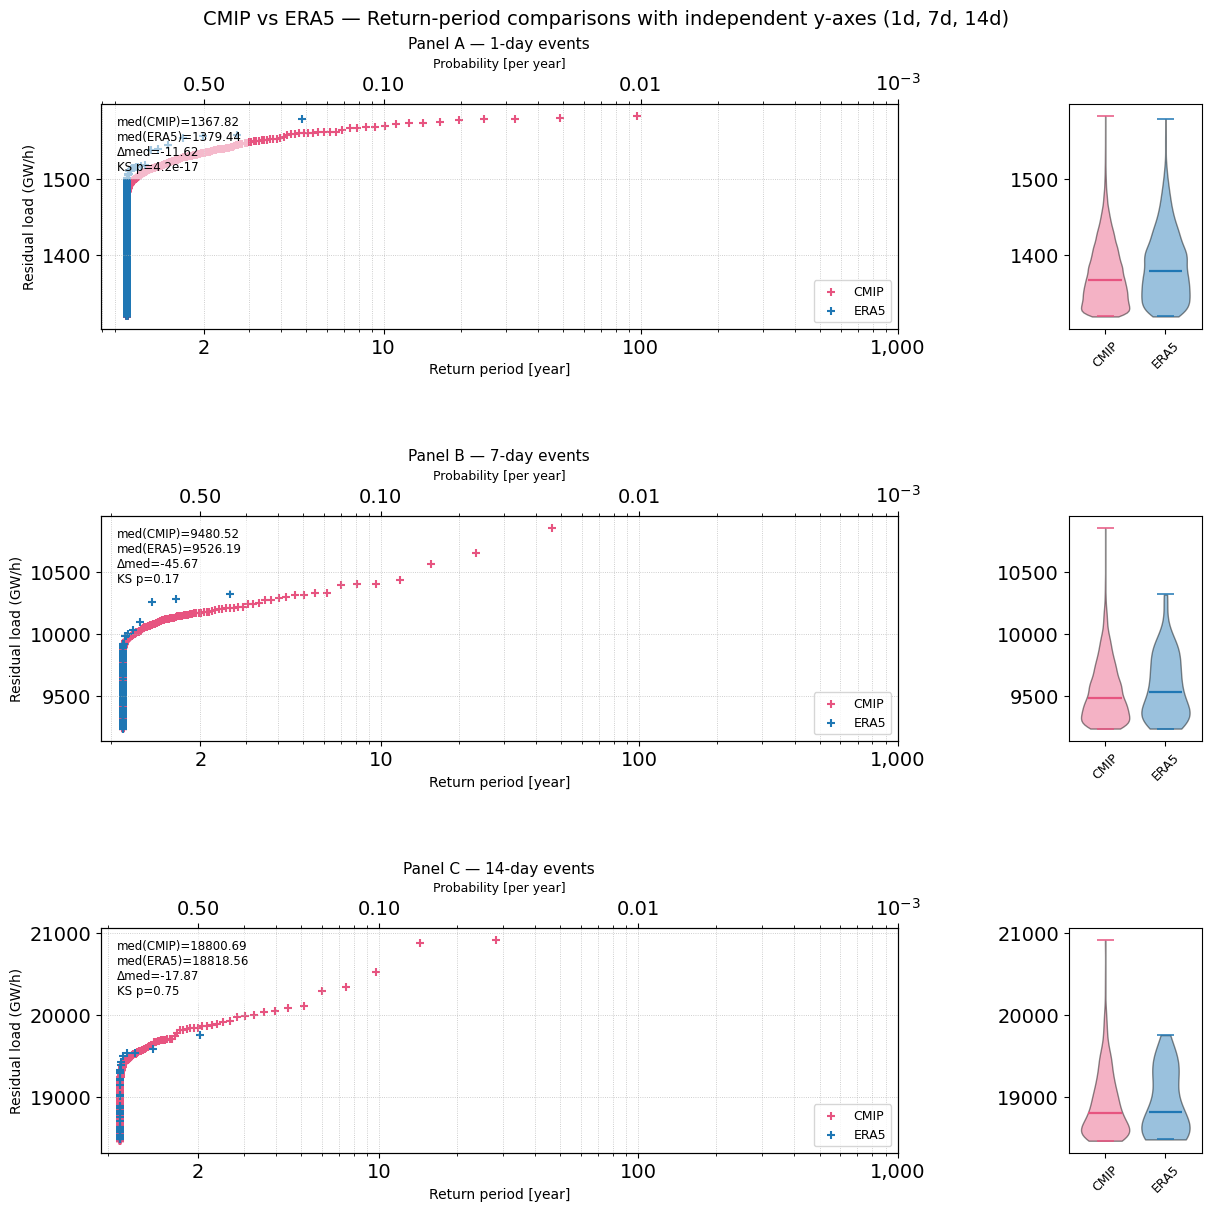

In [ ]:
# Old and not right (but maybe useful for plotting in the future)

# ---------- helper functions ----------
colors = ['#e75480', '#1f77b4']  # CMIP pink, ERA5 blue
days_per_year = 365.0
max_rp = 1e3
min_rp = 1.0

def to_numpy_dropna(series_like):
    if isinstance(series_like, (pd.Series, pd.DataFrame)):
        vals = series_like.values.ravel()
    else:
        vals = np.asarray(series_like).ravel()
    vals = vals[~np.isnan(vals)]
    return vals

def empirical_exceedance(values):
    vals = np.sort(values)
    n = len(vals)
    exceed_prob = 1.0 - np.arange(1, n + 1) / (n + 1)
    return vals, exceed_prob

def rp_from_period_exceedance(exceed_prob_period, duration_days):
    periods_per_year = days_per_year / float(duration_days)
    p_year = 1.0 - (1.0 - exceed_prob_period) ** periods_per_year
    rp = np.where(p_year > 0, 1.0 / p_year, np.inf)
    return rp

def plot_rp_and_violin(ax_main, ax_violin, cmip_arr, era_arr, duration_days, title_label):
    cmip = to_numpy_dropna(cmip_arr)
    era  = to_numpy_dropna(era_arr)

    era_vals, era_p_period = empirical_exceedance(era)
    cmip_vals, cmip_p_period = empirical_exceedance(cmip)

    era_rp = rp_from_period_exceedance(era_p_period, duration_days)
    cmip_rp = rp_from_period_exceedance(cmip_p_period, duration_days)

    era_mask  = np.isfinite(era_rp)  & (era_rp <= max_rp)  & (era_rp >= min_rp)
    cmip_mask = np.isfinite(cmip_rp) & (cmip_rp <= max_rp) & (cmip_rp >= min_rp)

    era_vals_plot, era_rp_plot   = era_vals[era_mask], era_rp[era_mask]
    cmip_vals_plot, cmip_rp_plot = cmip_vals[cmip_mask], cmip_rp[cmip_mask]

    # scatter points
    ax_main.scatter(cmip_rp_plot, cmip_vals_plot, marker='+', s=28, color=colors[0], label='CMIP')
    ax_main.scatter(era_rp_plot, era_vals_plot, marker='+', s=28, color=colors[1], label='ERA5')

    ax_main.set_xscale('log')
    ax_main.set_xlim(0, max_rp)
    ax_main.set_xlabel('Return period [year]', fontsize=10)
    ax_main.set_ylabel('Residual load (GW/h)', fontsize=10)
    ax_main.grid(which='both', linestyle=':', linewidth=0.6, alpha=0.8)

    bottom_ticks = [2, 10, 100, 1000]
    ax_main.set_xticks(bottom_ticks)
    ax_main.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

    top = ax_main.twiny()
    top.set_xscale('log')
    top.set_xlim(ax_main.get_xlim())
    top.set_xticks(bottom_ticks)
    # nicer labels for top axis
    top_labels_pretty = []
    for rp in bottom_ticks:
        prob = 1.0 / rp
        if prob < 1e-2:
            k = int(np.round(-np.log10(prob)))
            top_labels_pretty.append(r'$10^{-%d}$' % k)
        else:
            top_labels_pretty.append(f'{prob:.2f}')
    top.set_xticklabels(top_labels_pretty)
    top.set_xlabel('Probability [per year]', fontsize=9)

    ax_main.legend(loc='lower right', fontsize=9)
    ax_main.set_title(f'{title_label} — {duration_days}-day events', fontsize=11)

    # --- set y-limits PER ROW (so each row has own y-axis) ---
    # compute y-limits from the two arrays for this row
    combined = np.concatenate([cmip, era]) if (cmip.size + era.size) > 0 else np.array([0.0])
    vmin = np.nanmin(combined)
    vmax = np.nanmax(combined)
    if vmin == vmax:
        # small fudge to avoid zero-range
        vmin -= 0.5 * abs(vmin) + 0.5
        vmax += 0.5 * abs(vmax) + 0.5
    pad = 0.06 * (vmax - vmin)
    ax_main.set_ylim(vmin - pad, vmax + pad)

    # violin (do NOT share y with other rows)
    data_for_violin = [cmip, era]
    positions = [1.0, 2.0]
    parts = ax_violin.violinplot(dataset=data_for_violin, positions=positions, vert=True,
                                 widths=0.8, showextrema=False, showmedians=False)

    medians = [np.median(cmip) if cmip.size else np.nan, np.median(era) if era.size else np.nan]
    maxes   = [np.max(cmip) if cmip.size else np.nan,     np.max(era) if era.size else np.nan]
    mins    = [np.min(cmip) if cmip.size else np.nan,     np.min(era) if era.size else np.nan]

    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i])
        pc.set_edgecolor('black')
        pc.set_alpha(0.45)
        ax_violin.hlines(medians[i], positions[i] - 0.28, positions[i] + 0.28, color=colors[i], linewidth=1.6)
        ax_violin.hlines(maxes[i], positions[i] - 0.14, positions[i] + 0.14, color=colors[i], linewidth=1.1)
        ax_violin.hlines(mins[i],  positions[i] - 0.14, positions[i] + 0.14, color=colors[i], linewidth=1.1)

    ax_violin.set_xticks(positions)
    ax_violin.set_xticklabels(['CMIP', 'ERA5'], rotation=45, fontsize=9)
    # do NOT hide violin y ticks now — each row has its own y-axis so keep them visible for readability
    ax_violin.set_xlim(0.4, 2.6)
    # set violin y-limits to match the main axis for the same row so the shapes align vertically
    ax_violin.set_ylim(ax_main.get_ylim())

    # annotate statistics
    try:
        ks_stat, ks_p = stats.ks_2samp(cmip, era, alternative='two-sided', mode='asymp')
    except Exception:
        ks_stat, ks_p = np.nan, np.nan
    med_diff = medians[0] - medians[1]
    txt = f'med(CMIP)={medians[0]:.2f}\nmed(ERA5)={medians[1]:.2f}\nΔmed={med_diff:.2f}\nKS p={ks_p:.2g}'
    ax_main.text(0.02, 0.95, txt, transform=ax_main.transAxes, fontsize=8.5,
                 verticalalignment='top', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

# ---------- assemble figure with independent y-axes per row ----------
def make_three_rp_violins_independent_y(
    cmip_1, era_1,
    cmip_7, era_7,
    cmip_14, era_14,
    figsize=(12, 12)
):
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs = fig.add_gridspec(3, 2, width_ratios=[6, 1], hspace=0.18, wspace=0.12)

    datasets = [
        (cmip_1, era_1, 1, 'Panel A'),
        (cmip_7, era_7, 7, 'Panel B'),
        (cmip_14, era_14, 14, 'Panel C'),
    ]

    for row, (cmip_arr, era_arr, days, label) in enumerate(datasets):
        ax_main = fig.add_subplot(gs[row, 0])
        ax_violin = fig.add_subplot(gs[row, 1])  # no sharey
        plot_rp_and_violin(ax_main, ax_violin, cmip_arr, era_arr, duration_days=days, title_label=label)

    fig.suptitle('CMIP vs ERA5 — Return-period comparisons with independent y-axes (1d, 7d, 14d)', fontsize=14)
    plt.show()
    return fig

# ---------- Example call (uncomment to run) ----------
fig = make_three_rp_violins_independent_y(
    LEE_dat_CMIP['RL_cumulative'], LEE_dat_ERA5['RL_cumulative'],
    LEE_7_CMIP['RL_cumulative'], LEE_7_ERA5['RL_cumulative'],
    LEE_14_CMIP['RL_cumulative'], LEE_14_ERA5['RL_cumulative'],
)
# fig.savefig('CMIP_ERA5_RP_violins_1_7_14d_indepY.png', dpi=300, bbox_inches='tight')


In [4]:
# Function to add a winter season coordinate to an xarray Dataset
def add_winter_season_coordinate(ds, time_dim='time'):
    # Ensure the time coordinate is in datetime format
    time_values = pd.to_datetime(ds[time_dim].values)
    
    # Define a function to determine the winter season for each date
    def get_winter_season(date):
        year = date.year
        if date.month >= 7:  # July, August, September, October, November, December belong to the next year's winter
            return f"{year-2000}/{year-2000+1}"
        else:  # January, February, March, April, May, June belong to the current year's winter
            return f"{year-2000-1}/{year-2000}"
    
    # Apply the function to create a new array of winter seasons
    winter_seasons = np.array([get_winter_season(date) for date in time_values])
    
    # Add the new coordinate to the Dataset
    ds = ds.assign_coords(winter_season=(time_dim, winter_seasons))
    return ds

In [7]:
path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all_future.nc'
files = [path]

ds = xr.open_dataset(path)

ds = add_winter_season_coordinate(ds, time_dim='time')

ts_datasets = ds.where((ds.ESM_run != 'ERA5_hist_wwd') & (ds.ESM_run != 'SMARD_hist'),drop=True)
ts_datasets.load()


ds_CMIP6 = ds.where((ds.ESM_run != 'ERA5_hist_week') & (ds.ESM_run != 'ERA5_hist_wwd') & (ds.ESM_run != 'SMARD_hist'),drop=True)
ds_CMIP6.load()

res_load_fut = ts_datasets['Residual_load']
# Unravel the arrays to 1D for easier handling
res_load_fut_1d = res_load_fut.values.ravel()

res_load_fut_7d = res_load_fut.rolling(time=7, center=False).mean()
res_load_fut_14d = res_load_fut.rolling(time=14, center=False).mean()


In [5]:
path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all.nc'
files = [path]

ds = xr.open_dataset(path)
ds = add_winter_season_coordinate(ds, time_dim='time')

ts_datasets_ERA5 = ds.where(ds.ESM_run == 'ERA5_hist_week', drop=True)
ts_datasets_ERA5.load()
res_load_era5_15_24 = ts_datasets_ERA5['Residual_load']
res_load_era5_15_24_1d = res_load_era5_15_24.values.ravel()

res_load_era5_15_24_7d = res_load_era5_15_24.rolling(time=7, center=False).mean()
res_load_era5_15_24_14d = res_load_era5_15_24.rolling(time=14, center=False).mean()

ts_datasets_curr_clim = ds.where((ds.ESM_run != 'ERA5_hist_wwd') & (ds.ESM_run != 'SMARD_hist') & (ds.ESM_run != 'ERA5_hist_week'),drop=True)
ts_datasets_curr_clim.load()

res_load_curr_clim = ts_datasets_curr_clim['Residual_load']
# Unravel the arrays to 1D for easier handling
res_load_curr_clim_1d = res_load_curr_clim.values.ravel()

res_load_curr_clim_7d = res_load_curr_clim.rolling(time=7, center=False).mean()
res_load_curr_clim_14d = res_load_curr_clim.rolling(time=14, center=False).mean()


In [8]:
path = '/climca/people/onennecke/model_output/not_bias_corrected/full_year/ERA5_all_years/ERA5_hist_timeseries.nc'

ts_datasets_ERA5 = xr.open_dataset(path)
ts_datasets_ERA5 = add_winter_season_coordinate(ts_datasets_ERA5, time_dim='time')
ts_datasets_ERA5.load()
res_load_ERA5 = ts_datasets_ERA5['Residual_load']

res_load_ERA5_7d = res_load_ERA5.rolling(time=7, center=False).mean()
res_load_ERA5_14d = res_load_ERA5.rolling(time=14, center=False).mean()

In [9]:
res_load_ERA5_1960_1990 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 1960) & (ts_datasets_ERA5.time.dt.year <= 1990), drop=True)['Residual_load']
res_load_ERA5_1990_2014 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 1990) & (ts_datasets_ERA5.time.dt.year <= 2014), drop=True)['Residual_load']

res_load_ERA5_1960_1970 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 1960) & (ts_datasets_ERA5.time.dt.year <= 1970), drop=True)['Residual_load']
res_load_ERA5_1970_1980 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 1970) & (ts_datasets_ERA5.time.dt.year <= 1980), drop=True)['Residual_load']
res_load_ERA5_1980_1990 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 1980) & (ts_datasets_ERA5.time.dt.year <= 1990), drop=True)['Residual_load']
res_load_ERA5_1990_2000 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 1990) & (ts_datasets_ERA5.time.dt.year <= 2000), drop=True)['Residual_load']
res_load_ERA5_2000_2010 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 2000) & (ts_datasets_ERA5.time.dt.year <= 2010), drop=True)['Residual_load']
res_load_ERA5_2010_2020 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 2010) & (ts_datasets_ERA5.time.dt.year <= 2020), drop=True)['Residual_load']
res_load_ERA5_2020_2024 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 2020) & (ts_datasets_ERA5.time.dt.year <= 2024), drop=True)['Residual_load']

res_load_ERA5_2015_2019 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 2015) & (ts_datasets_ERA5.time.dt.year <= 2019), drop=True)['Residual_load']

In [10]:
res_load_ERA5_2015_2024 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 2015) & (ts_datasets_ERA5.time.dt.year <= 2024), drop=True)['Residual_load']
res_load_ERA5_2015_2024

<xarray.DataArray 'Residual_load' (time: 3650)> Size: 29kB
array([ 533.62954852, -124.66275289,  290.84286213, ...,  984.9126268 ,
        457.11872085,  402.62437437])
Coordinates:
  * time           (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    ESM            <U9 36B 'ERA5_week'
    run            <U4 16B 'hist'
    ESM_run        <U14 56B 'ERA5_hist_week'
    country        float64 8B 9.0
    period         <U4 16B 'week'
    winter_season  (time) <U7 102kB '14/15' '14/15' '14/15' ... '24/25' '24/25'

In [28]:
max(max(res_load_ERA5), max(res_load_curr_clim_1d), max(res_load_fut_1d))
# == np.float64(1596.223514139268)


np.float64(1596.223514139268)

In [29]:
# Connect both ERA5 periods to the same plot to see if they differ in the recent years (2015-2024)
res_load_tst = xr.concat([res_load_ERA5_2015_2019, res_load_ERA5_2020_2024], dim='time').values

# Check if they are exactly the same (they should be)
# np.allclose(res_load_tst, res_load_ERA5_2015_2024.values)


In [30]:
# Select values larger than threshold
threshold = np.float64(1319.138650687668)
print(len(res_load_ERA5_1960_1970[res_load_ERA5_1960_1970 > threshold]))
print(len(res_load_ERA5_1970_1980[res_load_ERA5_1970_1980 > threshold]))
print(len(res_load_ERA5_1980_1990[res_load_ERA5_1980_1990 > threshold]))
print(len(res_load_ERA5_1990_2000[res_load_ERA5_1990_2000 > threshold]))
print(len(res_load_ERA5_2000_2010[res_load_ERA5_2000_2010 > threshold]))
print(len(res_load_ERA5_2010_2020[res_load_ERA5_2010_2020 > threshold]))
print(len(res_load_ERA5_2020_2024[res_load_ERA5_2020_2024 > threshold]))

297
196
240
242
230
199
78


In [31]:
threshold = np.float64(1319.138650687668)
print(len(res_load_ERA5_1960_1970[res_load_ERA5_1960_1970 > threshold]))
# Select only year 1960
res_load_ERA5_1960 = ts_datasets_ERA5.where(ts_datasets_ERA5.time.dt.year == 1960, drop=True)['Residual_load']
print(len(res_load_ERA5_1960[res_load_ERA5_1960 > threshold]))
res_load_ERA5_1961 = ts_datasets_ERA5.where(ts_datasets_ERA5.time.dt.year == 1961, drop=True)['Residual_load']
print(len(res_load_ERA5_1961[res_load_ERA5_1961 > threshold]))
res_load_ERA5_1962 = ts_datasets_ERA5.where(ts_datasets_ERA5.time.dt.year == 1962, drop=True)['Residual_load']
print(len(res_load_ERA5_1962[res_load_ERA5_1962 > threshold]))
res_load_ERA5_1963 = ts_datasets_ERA5.where(ts_datasets_ERA5.time.dt.year == 1963, drop=True)['Residual_load']
print(len(res_load_ERA5_1963[res_load_ERA5_1963 > threshold]))
res_load_ERA5_1964 = ts_datasets_ERA5.where(ts_datasets_ERA5.time.dt.year == 1964, drop=True)['Residual_load']
print(len(res_load_ERA5_1964[res_load_ERA5_1964 > threshold]))
res_load_ERA5_1965 = ts_datasets_ERA5.where(ts_datasets_ERA5.time.dt.year == 1965, drop=True)['Residual_load']
print(len(res_load_ERA5_1965[res_load_ERA5_1965 > threshold]))
res_load_ERA5_1966 = ts_datasets_ERA5.where(ts_datasets_ERA5.time.dt.year == 1966, drop=True)['Residual_load']
print(len(res_load_ERA5_1966[res_load_ERA5_1966 > threshold]))
res_load_ERA5_1967 = ts_datasets_ERA5.where(ts_datasets_ERA5.time.dt.year == 1967, drop=True)['Residual_load']
print(len(res_load_ERA5_1967[res_load_ERA5_1967 > threshold]))
res_load_ERA5_1968 = ts_datasets_ERA5.where(ts_datasets_ERA5.time.dt.year == 1968, drop=True)['Residual_load']
print(len(res_load_ERA5_1968[res_load_ERA5_1968 > threshold]))
res_load_ERA5_1969 = ts_datasets_ERA5.where(ts_datasets_ERA5.time.dt.year == 1969, drop=True)['Residual_load']
print(len(res_load_ERA5_1969[res_load_ERA5_1969 > threshold]))

297
23
18
25
41
36
26
21
22
30
35


In [70]:
ts_datasets_ERA5['temp'].sel(time='1960-01-01').values


array(7.18517563)

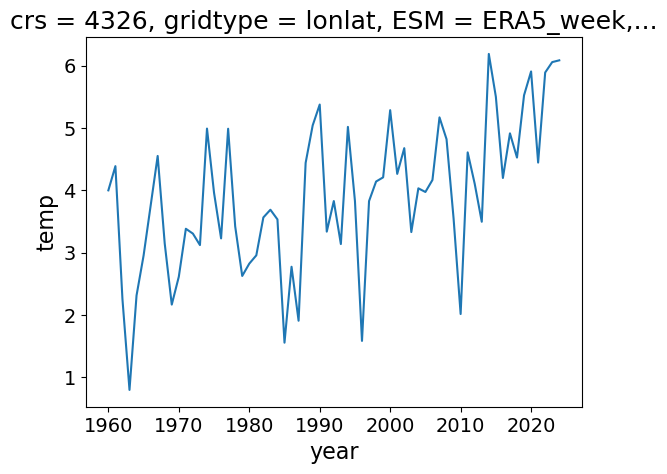

In [72]:
ts_datasets_ERA5['temp'].sel(time=ts_datasets_ERA5.time.dt.month.isin([1,2,3,10,11,12])).groupby('time.year').mean().plot()
# Filter for winter months (October to March)
# winter_months = [10, 11, 12, 1, 2, 3]
# winter_data = ts_datasets_ERA5['temp'].sel(time=ts_datasets_ERA5.time.dt.month.isin(winter_months))
# # Group by year and calculate the mean temperature for each winter season
# winter_season_means = winter_data.groupby('time.year').mean()
# # Plot the winter season means
# winter_season_means.plot()
# plt.title('Mean Winter Temperature (ERA5)')
# plt.xlabel('Year')
# plt.ylabel('Temperature (°C)')
# plt.grid()
# plt.show()


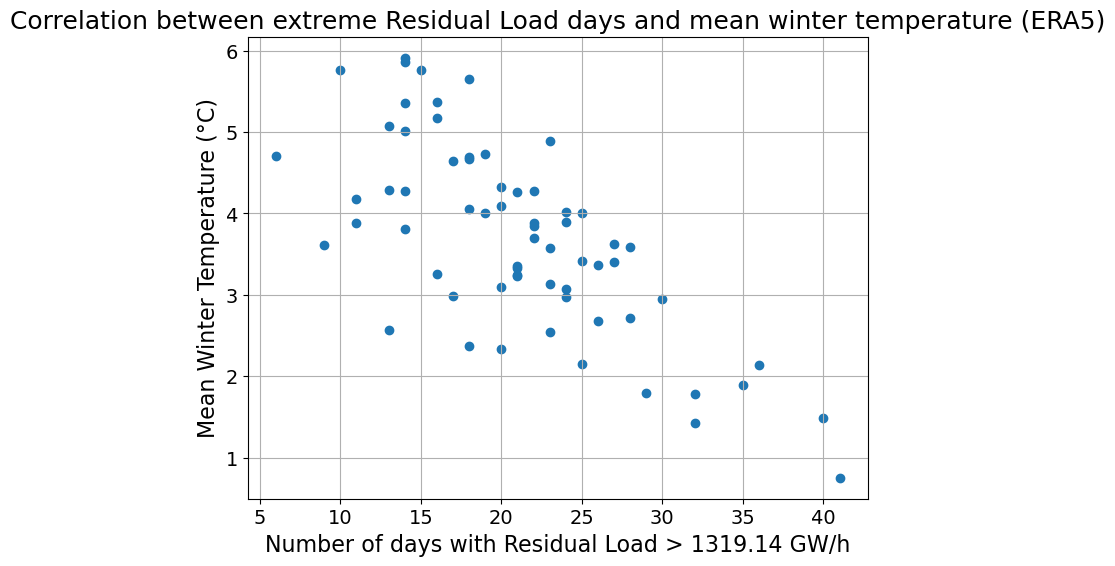

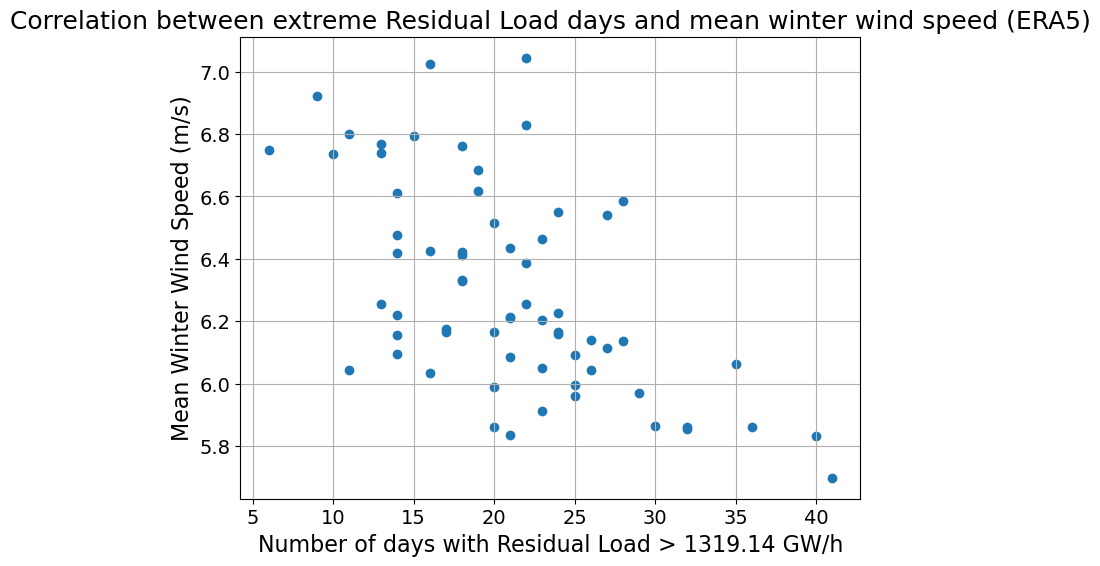

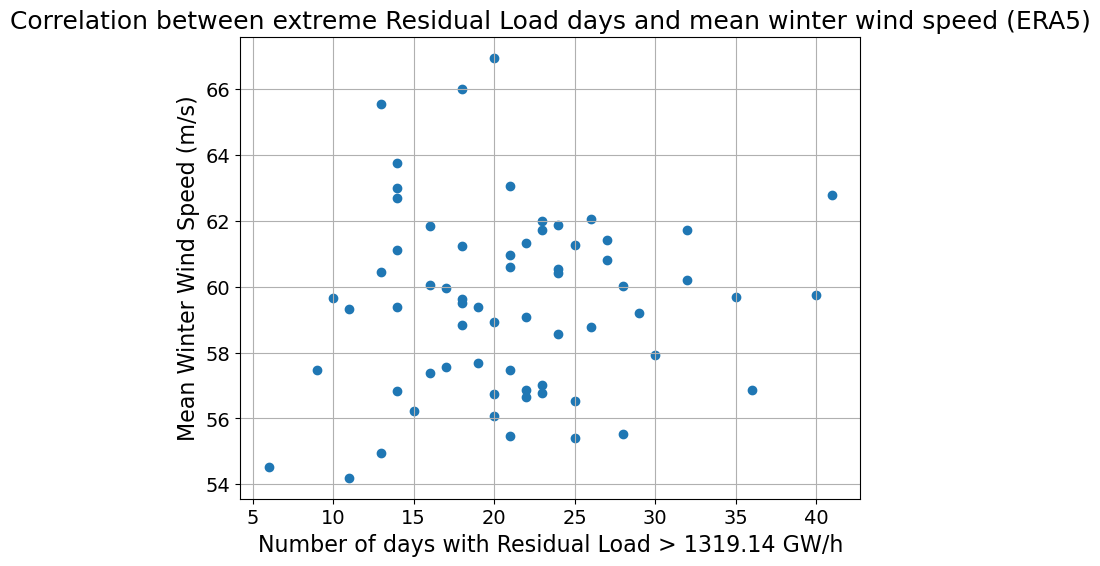

In [ ]:
x = res_load_ERA5.groupby('time.year').apply(lambda x: np.sum(x > threshold)).values
y = ts_datasets_ERA5['tas'].sel(time=ts_datasets_ERA5.time.dt.month.isin([1,2,3,10,11,12])).groupby('time.year').mean().values

# Correalte and plot x and y
plt.figure(figsize=(8,6))
plt.scatter(x, y)
plt.xlabel('Number of days with Residual Load > 1319.14 GW/h')
plt.ylabel('Mean Winter Temperature (°C)')
plt.title('Correlation between extreme Residual Load days and mean winter temperature (ERA5)')
plt.grid()
plt.show()

y = ts_datasets_ERA5['sfcWind'].sel(time=ts_datasets_ERA5.time.dt.month.isin([1,2,3,10,11,12])).groupby('time.year').mean().values

# Correalte and plot x and y
plt.figure(figsize=(8,6))
plt.scatter(x, y)
plt.xlabel('Number of days with Residual Load > 1319.14 GW/h')
plt.ylabel('Mean Winter Wind Speed (m/s)')
plt.title('Correlation between extreme Residual Load days and mean winter wind speed (ERA5)')
plt.grid()
plt.show()

y = ts_datasets_ERA5['rsds'].sel(time=ts_datasets_ERA5.time.dt.month.isin([1,2,3,10,11,12])).groupby('time.year').mean().values
    
# Correalte and plot x and y
plt.figure(figsize=(8,6))
plt.scatter(x, y)
plt.xlabel('Number of days with Residual Load > 1319.14 GW/h')
plt.ylabel('Mean Winter rsds (W/m²)')
plt.title('Correlation between extreme Residual Load days and mean winter rsds (ERA5)')
plt.grid()
plt.show()


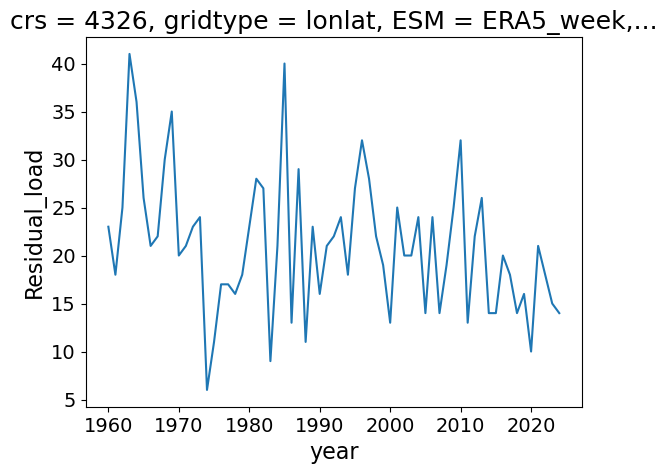

In [56]:
res_load_ERA5.groupby('time.year').apply(lambda x: np.sum(x > threshold)).plot()

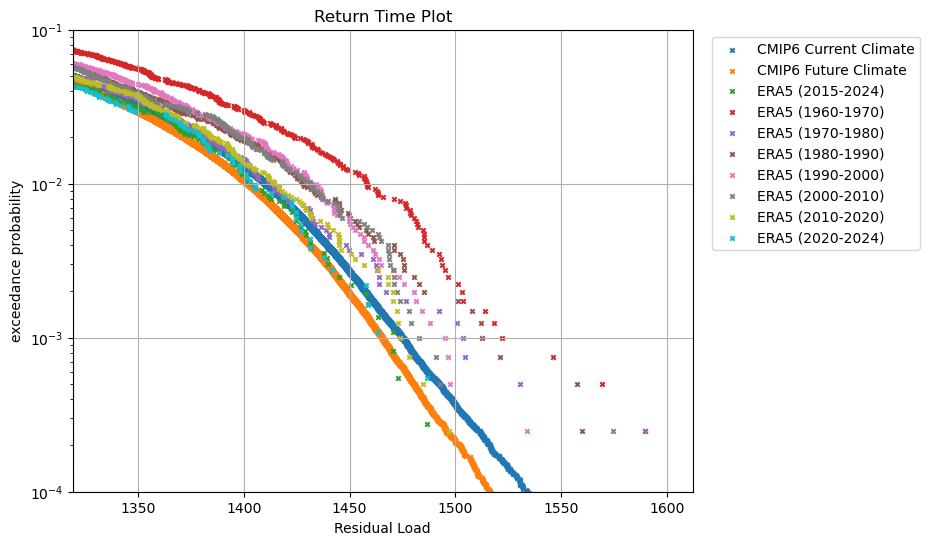

In [21]:
# This is only for the 1d values (but correct otherwise)

RLs = [res_load_ERA5, res_load_curr_clim_1d, res_load_fut_1d, res_load_era5_15_24_1d]
labels = ['ERA5 (1960-2024)', 'CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (2015-2024)']

RLs = [# res_load_ERA5, 
       res_load_curr_clim_1d, res_load_fut_1d, res_load_era5_15_24_1d,
       res_load_ERA5_1960_1970, res_load_ERA5_1970_1980, res_load_ERA5_1980_1990,
       res_load_ERA5_1990_2000, res_load_ERA5_2000_2010, res_load_ERA5_2010_2020, res_load_ERA5_2020_2024]
labels = [#'ERA5 (1960-2024)', 
          'CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (2015-2024)',
          'ERA5 (1960-1970)', 'ERA5 (1970-1980)', 'ERA5 (1980-1990)',
          'ERA5 (1990-2000)', 'ERA5 (2000-2010)', 'ERA5 (2010-2020)', 'ERA5 (2020-2024)']

# RLs = [# res_load_ERA5, 
#        res_load_curr_clim_1d, res_load_fut_1d, res_load_era5_15_24_1d,
#        res_load_ERA5_2015_2019, res_load_ERA5_2020_2024]
# labels = [#'ERA5 (1960-2024)', 
#           'CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (2015-2024)',
#           'ERA5 (2015-2019)', 'ERA5 (2020-2024)']


# RLs = [res_load_curr_clim_1d, res_load_fut_1d, res_load_ERA5_1960_1990, res_load_ERA5_1990_2014, res_load_era5_15_24_1d]
# labels = ['CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (1960-1990)', 'ERA5 (1990-2014)', 'ERA5 (2015-2024)']

# RLs = [res_load_era5_15_24]
# labels = ['ERA5 (2015-2024)']
# Plot
plt.figure(figsize=(8,6))


for res_load, label in zip(RLs, labels):

    # Example: extreme residual load values
    extremes = res_load # your event values

    # Sort ascending
    x = np.sort(extremes)

    # Rank
    m = np.arange(1, len(x) + 1)

    # Total observation period (important!)
    N = len(extremes)  # OR number of years, depending on method

    # Return period
    # T = (N + 1) / (N + 1 - m)
    T = (1 - (m/(N+1)))  # equivalent, more direct formula
        


    plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1
plt.vlines(np.float64(1319.138650687668), ymin=0, ymax=1, color='gray', linestyle='--', linewidth=0.8)
plt.yscale('log')
# plt.xscale('log')
plt.xlim(np.float64(1319.138650687668), np.float64(1596.223514139268)*1.01)
# plt.xlim(np.float64(1470.138650687668), np.float64(1480.223514139268)*1.01)

plt.ylim(1e-4, 1e-1)
plt.ylabel('exceedance probability')
plt.xlabel('Residual Load')
plt.title('Return Time Plot')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.grid(True)
plt.show()


# # Plot
# plt.figure(figsize=(8,6))


# for res_load, label in zip(RLs, labels):

#     # Example: extreme residual load values
#     extremes = res_load # your event values

#     # Sort descending
#     x = np.sort(extremes)[::-1]

#     # Rank
#     m = np.arange(1, len(x) + 1)

#     # Total observation period (important!)
#     N = len(extremes)  # OR number of years, depending on method

#     # Return period
#     # T = (N + 1) / (N + 1 - m)
#     # T = (1 - (m/(N+1)))  # equivalent, more direct formula
#     # Return period
#     T = (N + 1) / m
        


#     plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1
# plt.vlines(np.float64(1319.138650687668), ymin=0, ymax=1, color='gray', linestyle='--', linewidth=0.8)
# plt.yscale('log')
# # plt.xscale('log')
# plt.xlim(np.float64(1319.138650687668), np.float64(1596.223514139268)*1.01)
# plt.ylabel('Return Period')
# plt.xlabel('Residual Load')
# plt.title('Return Time Plot')
# plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
# plt.grid(True)
# plt.show()

In [35]:
parts

{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x7fdb93bd3b90>,
 'cmaxes': <matplotlib.collections.LineCollection at 0x7fdb935caa50>,
 'cmins': <matplotlib.collections.LineCollection at 0x7fdb931fc8f0>,
 'cbars': <matplotlib.collections.LineCollection at 0x7fdb93d22e40>,
 'cmedians': <matplotlib.collections.LineCollection at 0x7fdb93cd1850>}

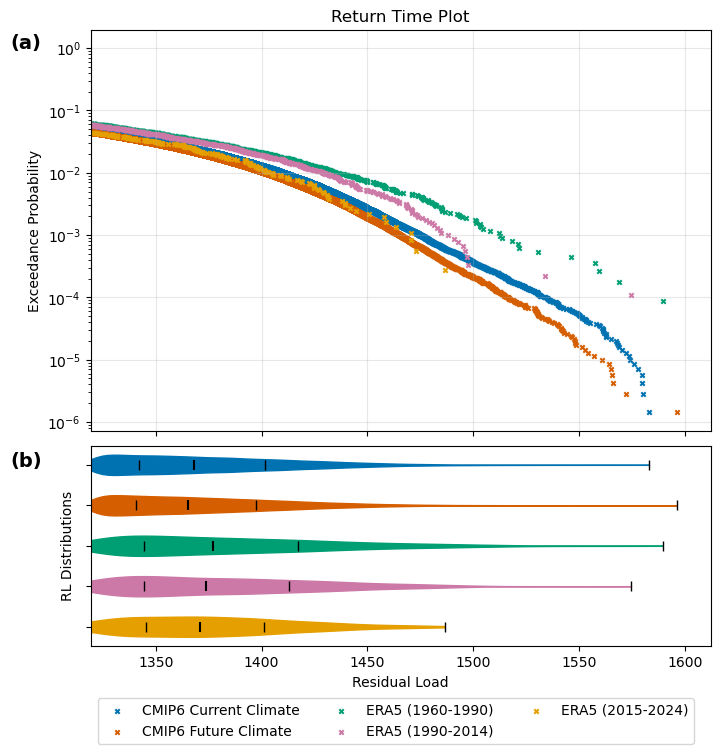

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

RLs = [res_load_curr_clim_1d, res_load_fut_1d, res_load_ERA5_1960_1990, res_load_ERA5_1990_2014, res_load_era5_15_24_1d]
labels = ['CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (1960-1990)', 'ERA5 (1990-2014)', 'ERA5 (2015-2024)']
RLs_filt = [rl[rl > np.float64(1319.138650687668)] for rl in RLs]


# Create figure with two vertically stacked axes
fig = plt.figure(figsize=(8, 8))
gs = GridSpec(2, 1, height_ratios=[3, 1.5], hspace=0.05)

ax_rt = fig.add_subplot(gs[0])
ax_violin = fig.add_subplot(gs[1], sharex=ax_rt)
colors = []
colors = plt.rcParams['axes.prop_cycle'].by_key()['color'][:len(RLs)]
# Okabe-Ito colour-blind friendly palette
colors = [
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#009E73",  # bluish green
    "#CC79A7",  # reddish purple
    "#E69F00",  # orange
]
# -------------------------
# Return time plot
# -------------------------
for i, (res_load, label) in enumerate(zip(RLs, labels)):

    extremes = np.asarray(res_load)

    x = np.sort(extremes)
    m = np.arange(1, len(x) + 1)
    N = len(extremes)

    T = 1 - (m / (N + 1))

    sc = ax_rt.scatter(
        x,
        T,
        marker='x',
        color=colors[i],
        s=10,
        label=label
    )
    colors.append(sc.get_facecolor()[0])
threshold = np.float64(1319.138650687668)

ax_rt.axvline(
    threshold,
    color='gray',
    linestyle='--',
    linewidth=0.8
)

ax_rt.set_yscale('log')
ax_rt.set_xlim(
    threshold,
    np.float64(1596.223514139268) * 1.01
)

ax_rt.set_ylabel('Exceedance Probability')
ax_rt.set_title('Return Time Plot')
ax_rt.grid(alpha=0.3)

ax_rt.legend(
    loc='upper left',
    bbox_to_anchor=(0, -0.65),
    ncol=3
)

# -------------------------
# Horizontal violin plots
# -------------------------
positions = np.arange(len(RLs_filt), 0, -1)

parts = ax_violin.violinplot(
    RLs_filt,
    positions=positions,
    vert=False,          # horizontal violins
    showmeans=False,
    showmedians=True,
    showextrema=False
)

# Width of the percentile markers
half_height = 0.12

for pos, data in zip(positions, RLs_filt):
    q25, med, q75 = np.percentile(data, [25, 50, 75])
    xmin = np.min(data)
    xmax = np.max(data)
    # 25th percentile
    ax_violin.vlines(
        q25, pos-half_height, pos+half_height,
        color='k', linewidth=1
    )
    # 75th percentile
    ax_violin.vlines(
        q75, pos-half_height, pos+half_height,
        color='k', linewidth=1
    )
    # Maximum
    ax_violin.vlines(
        xmax, pos-half_height, pos+half_height,
        color='k', linewidth=1
    )


# Color the violins
for body, color in zip(parts['bodies'], colors):
    body.set_facecolor(color)
    body.set_edgecolor(color)
    body.set_alpha(1)

# Optional: color the median lines as well
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(1.5)

parts
# ax_violin.axvline(
#     threshold,
#     color='gray',
#     linestyle='--',
#     linewidth=0.8
# )

ax_violin.set_yticks(positions)
# ax_violin.set_yticklabels(labels)
ax_violin.set_yticklabels("")

ax_violin.set_xlabel('Residual Load')
ax_violin.set_ylabel('RL Distributions')

# Hide top x tick labels
plt.setp(ax_rt.get_xticklabels(), visible=False)

# Panel labels
ax_rt.text(
    -0.13, 0.99, "(a)",
    transform=ax_rt.transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="left"
)

ax_violin.text(
    -0.13, 0.97, "(b)",
    transform=ax_violin.transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="left"
)

# plt.savefig(
#     '/home/onennecke/Code/Figures/return_time_plot_with_violins.png',
#     dpi=300,
#     bbox_inches='tight'
# )

plt.show()

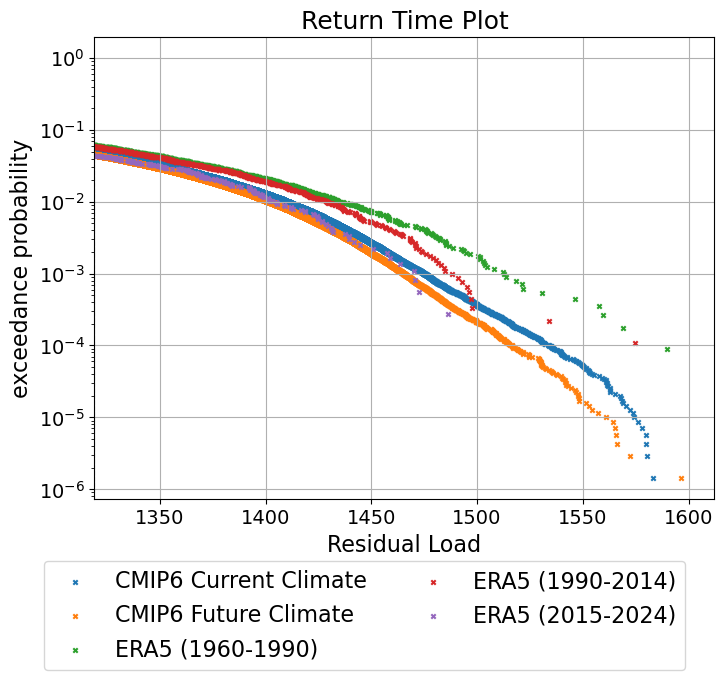

In [42]:
# This is only for the 1d values (but correct otherwise)

RLs = [res_load_ERA5, res_load_curr_clim_1d, res_load_fut_1d, res_load_era5_15_24_1d]
labels = ['ERA5 (1960-2024)', 'CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (2015-2024)']

RLs = [# res_load_ERA5, 
       res_load_curr_clim_1d, res_load_fut_1d, res_load_era5_15_24_1d,
       res_load_ERA5_1960_1970, res_load_ERA5_1970_1980, res_load_ERA5_1980_1990,
       res_load_ERA5_1990_2000, res_load_ERA5_2000_2010, res_load_ERA5_2010_2020, res_load_ERA5_2020_2024]
labels = [#'ERA5 (1960-2024)', 
          'CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (2015-2024)',
          'ERA5 (1960-1970)', 'ERA5 (1970-1980)', 'ERA5 (1980-1990)',
          'ERA5 (1990-2000)', 'ERA5 (2000-2010)', 'ERA5 (2010-2020)', 'ERA5 (2020-2024)']

# RLs = [# res_load_ERA5, 
#        res_load_curr_clim_1d, res_load_fut_1d, res_load_era5_15_24_1d,
#        res_load_ERA5_2015_2019, res_load_ERA5_2020_2024]
# labels = [#'ERA5 (1960-2024)', 
#           'CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (2015-2024)',
#           'ERA5 (2015-2019)', 'ERA5 (2020-2024)']


RLs = [res_load_curr_clim_1d, res_load_fut_1d, res_load_ERA5_1960_1990, res_load_ERA5_1990_2014, res_load_era5_15_24_1d]
labels = ['CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (1960-1990)', 'ERA5 (1990-2014)', 'ERA5 (2015-2024)']

# RLs = [res_load_era5_15_24]
# labels = ['ERA5 (2015-2024)']
# Plot
plt.figure(figsize=(8,6))


for res_load, label in zip(RLs, labels):

    # Example: extreme residual load values
    extremes = res_load # your event values

    # Sort ascending
    x = np.sort(extremes)

    # Rank
    m = np.arange(1, len(x) + 1)

    # Total observation period (important!)
    N = len(extremes)  # OR number of years, depending on method

    # Return period
    # T = (N + 1) / (N + 1 - m)
    T = (1 - (m/(N+1)))  # equivalent, more direct formula
        


    plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1
plt.vlines(np.float64(1319.138650687668), ymin=0, ymax=1, color='gray', linestyle='--', linewidth=0.8)
plt.yscale('log')
# plt.xscale('log')
plt.xlim(np.float64(1319.138650687668), np.float64(1596.223514139268)*1.01)
# plt.xlim(np.float64(1470.138650687668), np.float64(1480.223514139268)*1.01)

# plt.ylim(1e-4, 1e-1)
plt.ylabel('exceedance probability')
plt.xlabel('Residual Load')
plt.title('Return Time Plot')
plt.legend(loc='upper left', bbox_to_anchor=(-0.1, -0.11), ncol=2)
plt.grid(True)
plt.savefig('/home/onennecke/Code/Figures/return_time_plot_exceedance_prob.png', dpi=300, bbox_inches='tight')
plt.show()


# Plot
# plt.figure(figsize=(8,6))


# for res_load, label in zip(RLs, labels):

#     # Example: extreme residual load values
#     extremes = res_load # your event values

#     # Sort descending
#     x = np.sort(extremes)[::-1]

#     # Rank
#     m = np.arange(1, len(x) + 1)

#     # Total observation period (important!)
#     N = len(extremes)  # OR number of years, depending on method

#     # Return period
#     # T = (N + 1) / (N + 1 - m)
#     # T = (1 - (m/(N+1)))  # equivalent, more direct formula
#     # Return period
#     T = (N + 1) / m
        


#     plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1
# plt.vlines(np.float64(1319.138650687668), ymin=0, ymax=1, color='gray', linestyle='--', linewidth=0.8)
# plt.yscale('log')
# # plt.xscale('log')
# plt.xlim(np.float64(1319.138650687668), np.float64(1596.223514139268)*1.01)
# plt.ylabel('Return Period')
# plt.xlabel('Residual Load')
# plt.title('Return Time Plot')
# plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
# plt.grid(True)
# plt.show()

In [26]:
res_load_fut

<xarray.DataArray 'Residual_load' (ESM_run: 192, time: 3650)> Size: 6MB
array([[1221.20013817, 1071.59187726, 1250.71236328, ..., 1124.18602803,
        1314.31349002, 1291.64656601],
       [1236.05905651, 1028.26014001,  859.23223506, ..., 1200.41834566,
        1364.94718233, 1281.12595676],
       [ 958.52142067,  762.15764943,  424.02704545, ...,  993.32481832,
         955.29524753,  721.85881236],
       ...,
       [  -6.01077866,  382.37037722,  319.39666533, ...,  948.5305033 ,
         523.1708532 ,  580.68592875],
       [1544.47081279, 1272.66468121,  766.56365913, ...,  989.08750978,
        1239.88797735,  934.47109452],
       [ 131.16803645,  280.03751942,  555.75631081, ..., 1106.66151732,
         674.92395871,   71.73037994]])
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    ESM            (ESM_run) <U13 10kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run            (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2'
  * ESM_run        (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL...
    country        float64 8B 9.0
    period         <U4 16B 'week'
  * time           (time) datetime64[ns] 29kB 2039-01-01 ... 2048-12-31
    doy            (time) int64 29kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
    winter_season  (time) <U5 73kB '38/39' '38/39' '38/39' ... '48/49' '48/49'

In [35]:
len(res_load_fut.where(res_load_fut.ESM == 'ACCESS-CM2', drop=True).values.ravel())/3

3650.0

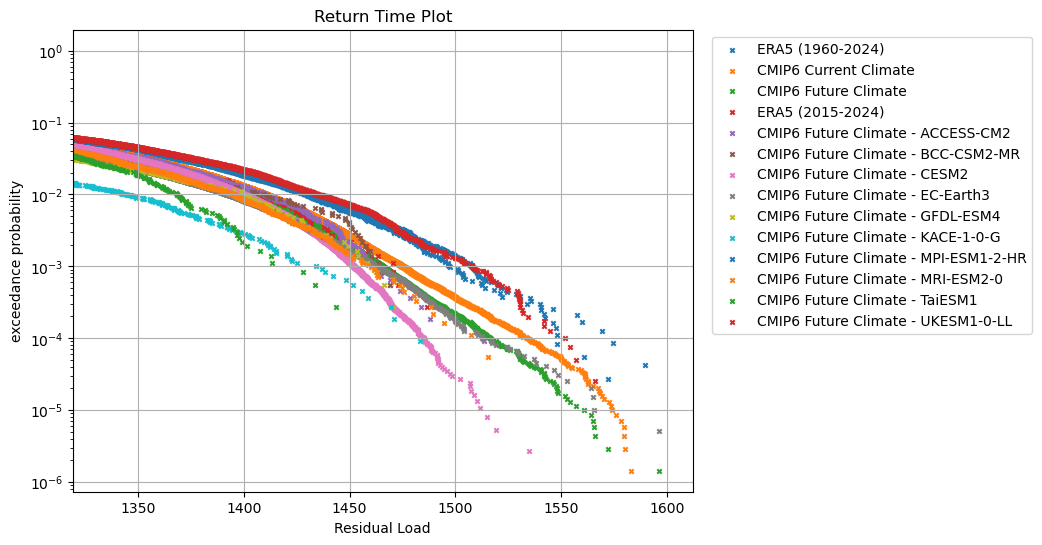

In [38]:
# This is only for the 1d values (but correct otherwise)

RLs = [res_load_ERA5, res_load_curr_clim_1d, res_load_fut_1d, res_load_era5_15_24_1d]
labels = ['ERA5 (1960-2024)', 'CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (2015-2024)']

# Plot
plt.figure(figsize=(8,6))

for res_load, label in zip(RLs, labels):

    # Example: extreme residual load values
    extremes = res_load # your event values

    # Sort ascending
    x = np.sort(extremes)

    # Rank
    m = np.arange(1, len(x) + 1)

    # Total observation period (important!)
    N = len(extremes)  # OR number of years, depending on method

    # Return period
    # T = (N + 1) / (N + 1 - m)
    T = (1 - (m/(N+1)))  # equivalent, more direct formula
        


    plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1

for esm in np.unique(res_load_fut.ESM):

    # Example: extreme residual load values
    extremes = res_load_fut.where(res_load_fut.ESM == esm, drop=True).values.ravel() 
    label = f'CMIP6 Future Climate - {esm}'
    # Sort ascending
    x = np.sort(extremes)

    # Rank
    m = np.arange(1, len(x) + 1)

    # Total observation period (important!)
    N = len(extremes)  # OR number of years, depending on method

    # Return period
    # T = (N + 1) / (N + 1 - m)
    T = (1 - (m/(N+1)))  # equivalent, more direct formula
        


    plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1
plt.vlines(np.float64(1319.138650687668), ymin=0, ymax=1, color='gray', linestyle='--', linewidth=0.8)
plt.yscale('log')
# plt.xscale('log')
plt.xlim(np.float64(1319.138650687668), np.float64(1596.223514139268)*1.01)
# plt.xlim(np.float64(1470.138650687668), np.float64(1480.223514139268)*1.01)

# plt.ylim(1e-4, 1e-1)
plt.ylabel('exceedance probability')
plt.xlabel('Residual Load')
plt.title('Return Time Plot')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.grid(True)
plt.show()

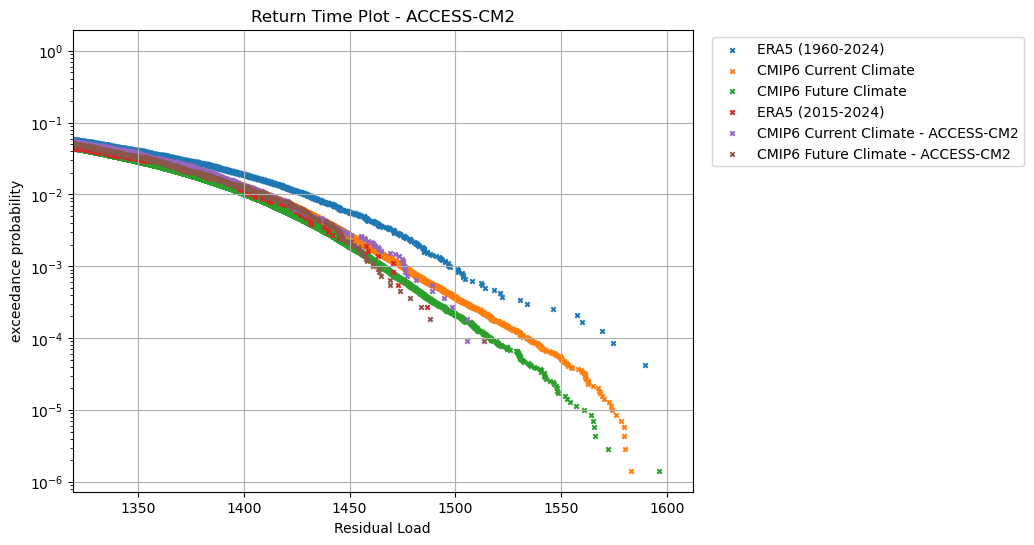

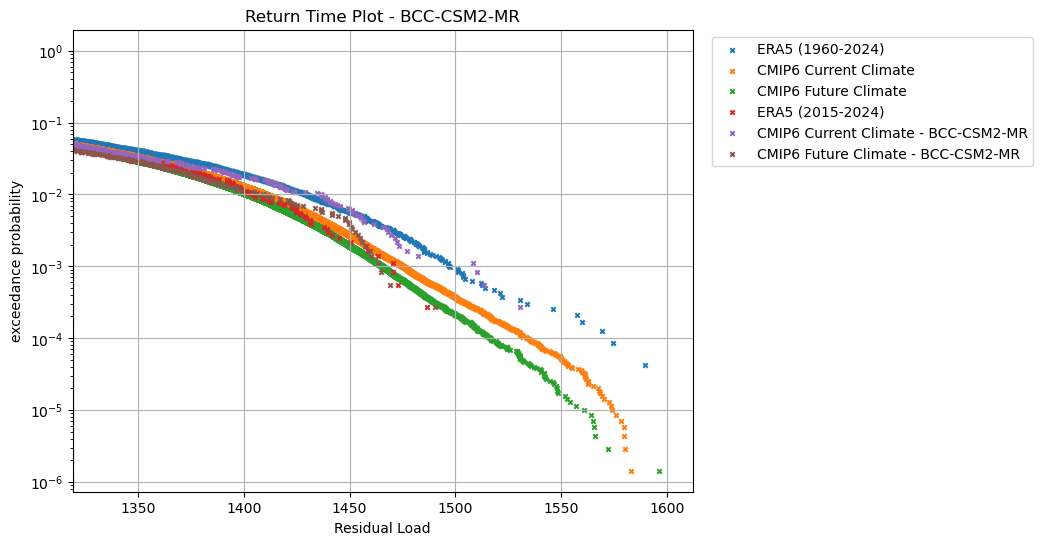

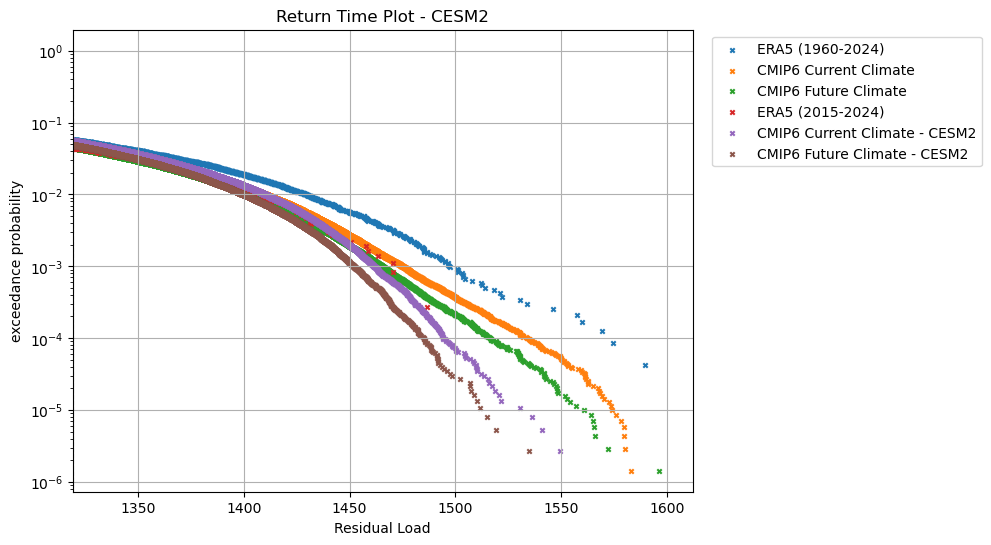

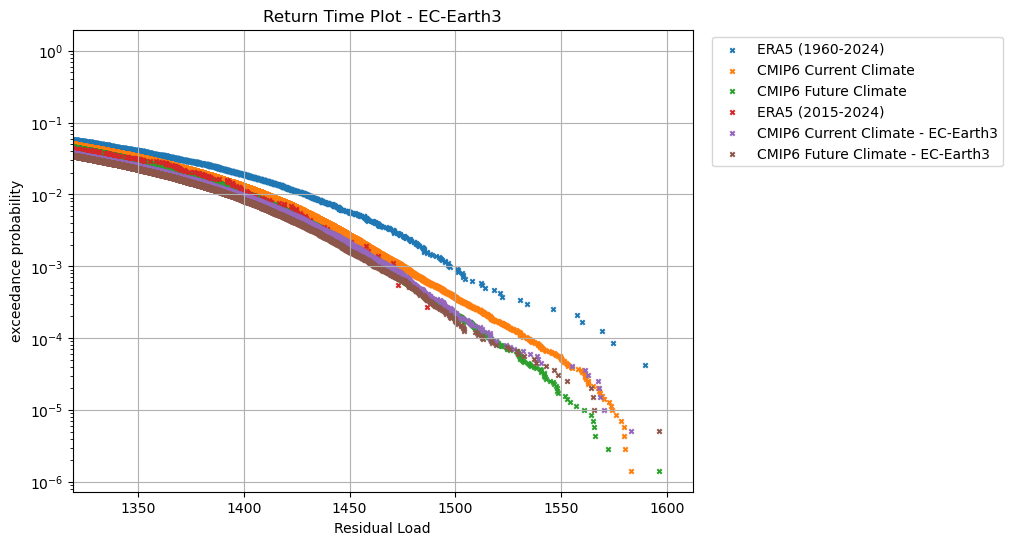

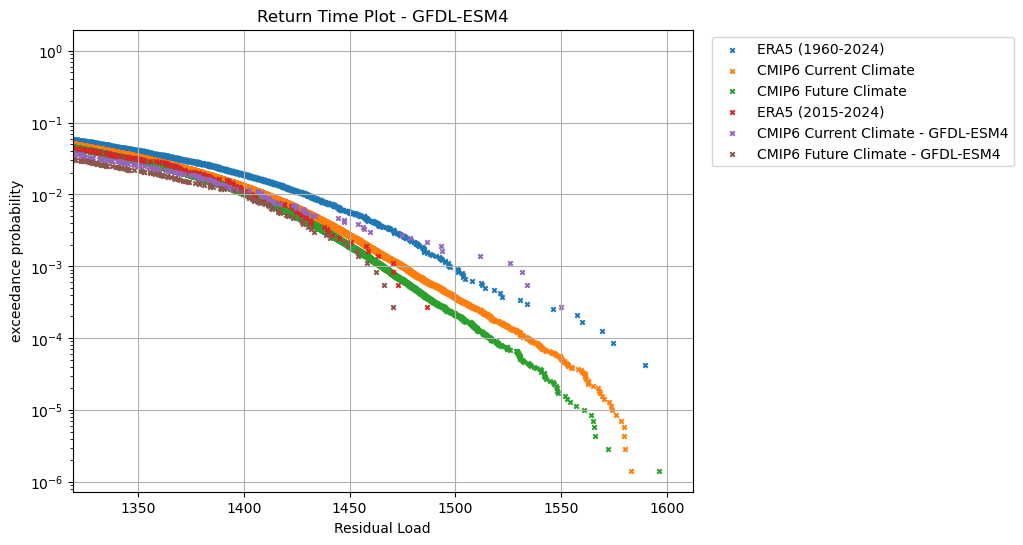

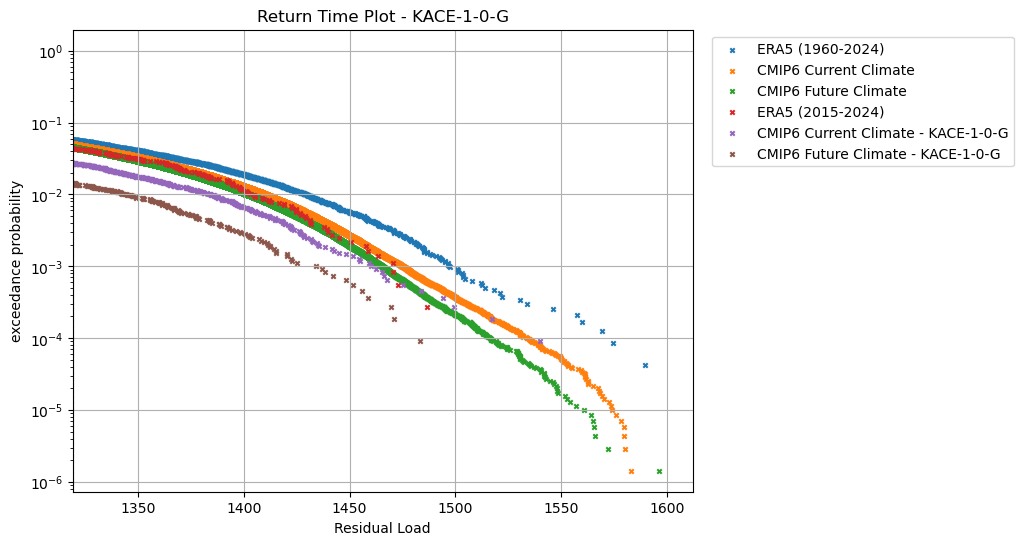

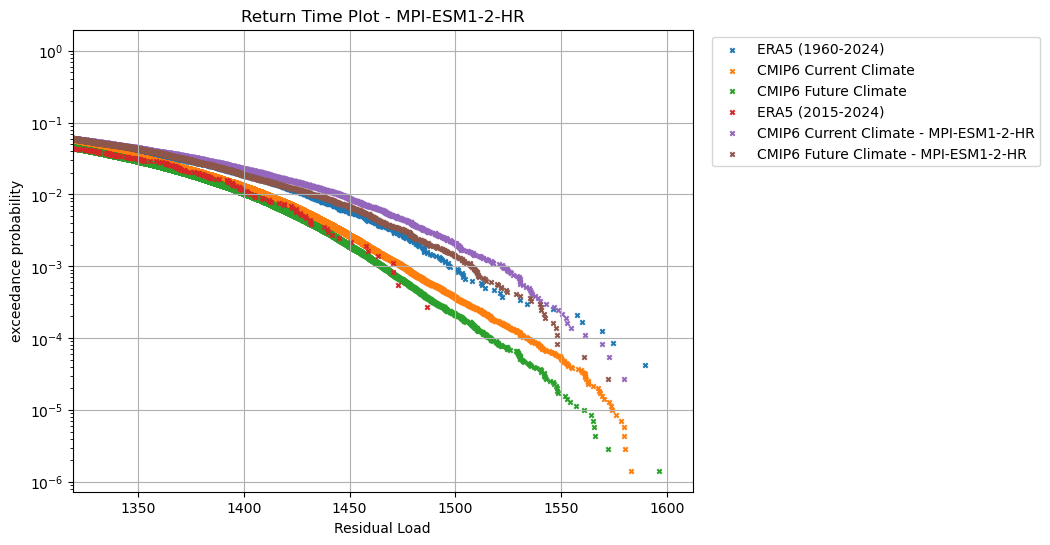

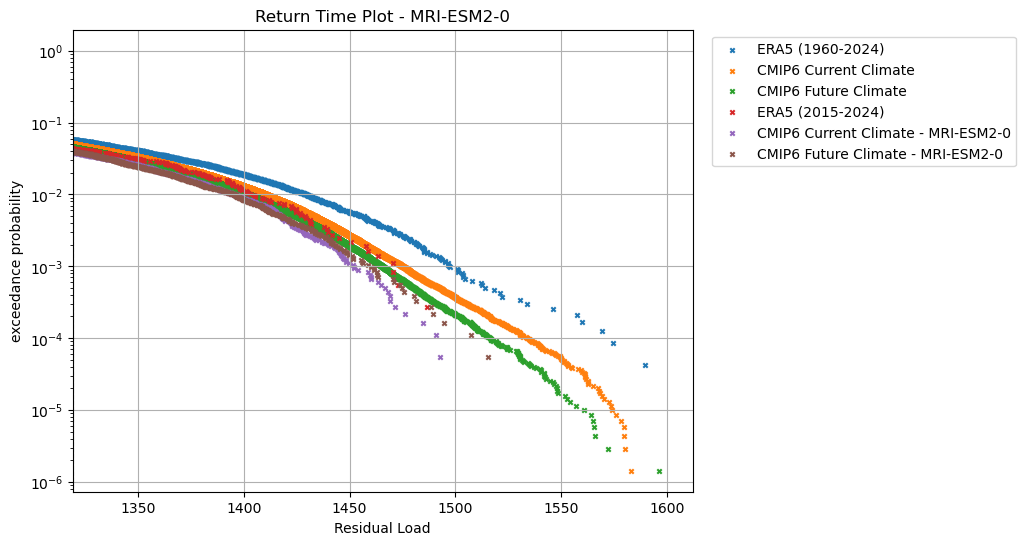

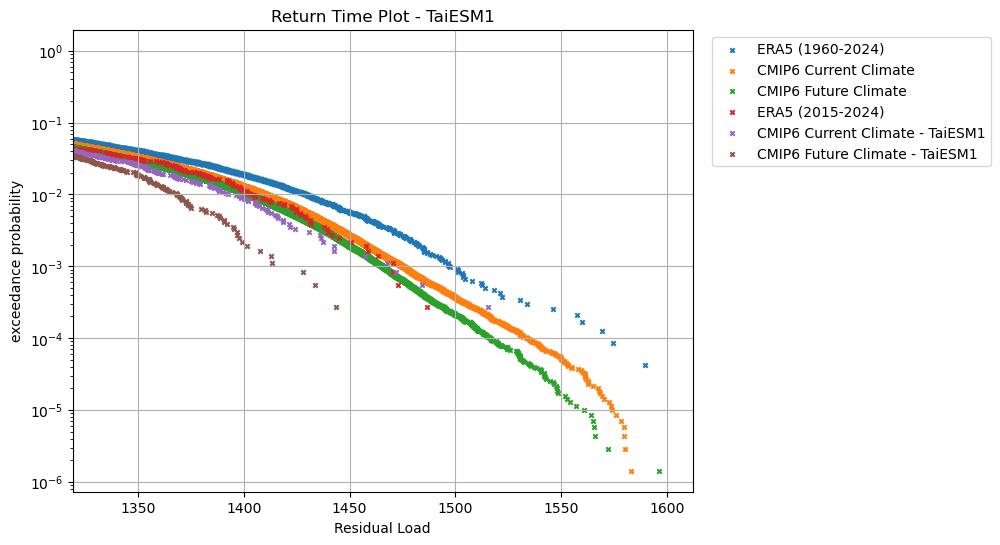

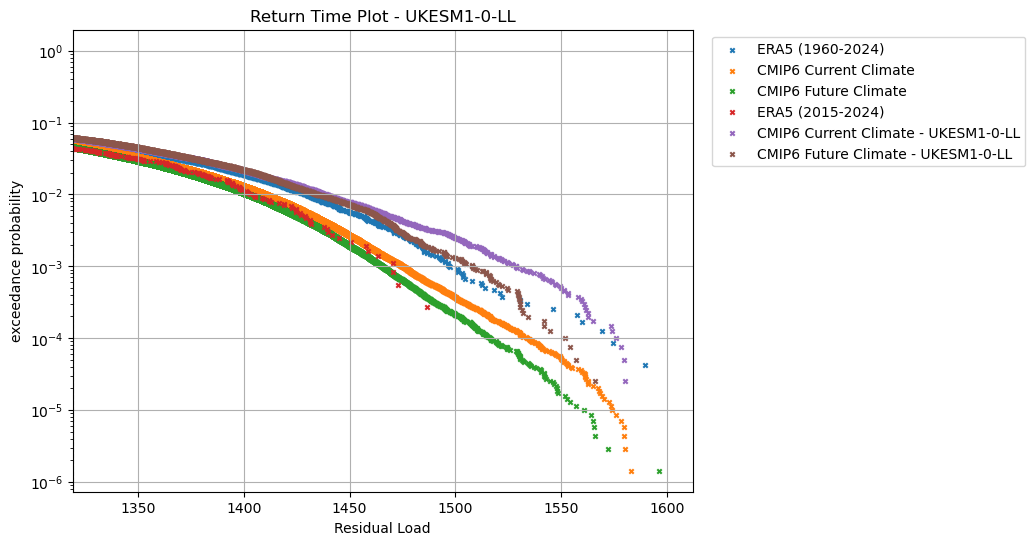

In [40]:
# This is only for the 1d values (but correct otherwise)

RLs = [res_load_ERA5, res_load_curr_clim_1d, res_load_fut_1d, res_load_era5_15_24_1d]
labels = ['ERA5 (1960-2024)', 'CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (2015-2024)']


for esm in np.unique(res_load_fut.ESM):
    # Plot
    plt.figure(figsize=(8,6))

    for res_load, label in zip(RLs, labels):

        # Example: extreme residual load values
        extremes = res_load # your event values

        # Sort ascending
        x = np.sort(extremes)

        # Rank
        m = np.arange(1, len(x) + 1)

        # Total observation period (important!)
        N = len(extremes)  # OR number of years, depending on method

        # Return period
        # T = (N + 1) / (N + 1 - m)
        T = (1 - (m/(N+1)))  # equivalent, more direct formula
            


        plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1



    extremes = res_load_curr_clim.where(res_load_curr_clim.ESM == esm, drop=True).values.ravel() 
    label = f'CMIP6 Current Climate - {esm}'
    # Sort ascending
    x = np.sort(extremes)

    # Rank
    m = np.arange(1, len(x) + 1)

    # Total observation period (important!)
    N = len(extremes)  # OR number of years, depending on method

    # Return period
    # T = (N + 1) / (N + 1 - m)
    T = (1 - (m/(N+1)))  # equivalent, more direct formula
    plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1
    
    extremes = res_load_fut.where(res_load_fut.ESM == esm, drop=True).values.ravel() 
    label = f'CMIP6 Future Climate - {esm}'
    # Sort ascending
    x = np.sort(extremes)

    # Rank
    m = np.arange(1, len(x) + 1)

    # Total observation period (important!)
    N = len(extremes)  # OR number of years, depending on method

    # Return period
    # T = (N + 1) / (N + 1 - m)
    T = (1 - (m/(N+1)))  # equivalent, more direct formula
    plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1
    plt.vlines(np.float64(1319.138650687668), ymin=0, ymax=1, color='gray', linestyle='--', linewidth=0.8)
    plt.yscale('log')
    # plt.xscale('log')
    plt.xlim(np.float64(1319.138650687668), np.float64(1596.223514139268)*1.01)
    # plt.xlim(np.float64(1470.138650687668), np.float64(1480.223514139268)*1.01)

    # plt.ylim(1e-4, 1e-1)
    plt.ylabel('exceedance probability')
    plt.xlabel('Residual Load')
    plt.title(f'Return Time Plot - {esm}')
    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    plt.grid(True)
    plt.show()

In [63]:
# np.max(res_load_fut.values.ravel().max(), res_load_curr_clim.values.ravel().max())
max(res_load_fut.values.ravel().max(), res_load_curr_clim.values.ravel().max())

np.float64(1596.223514139268)

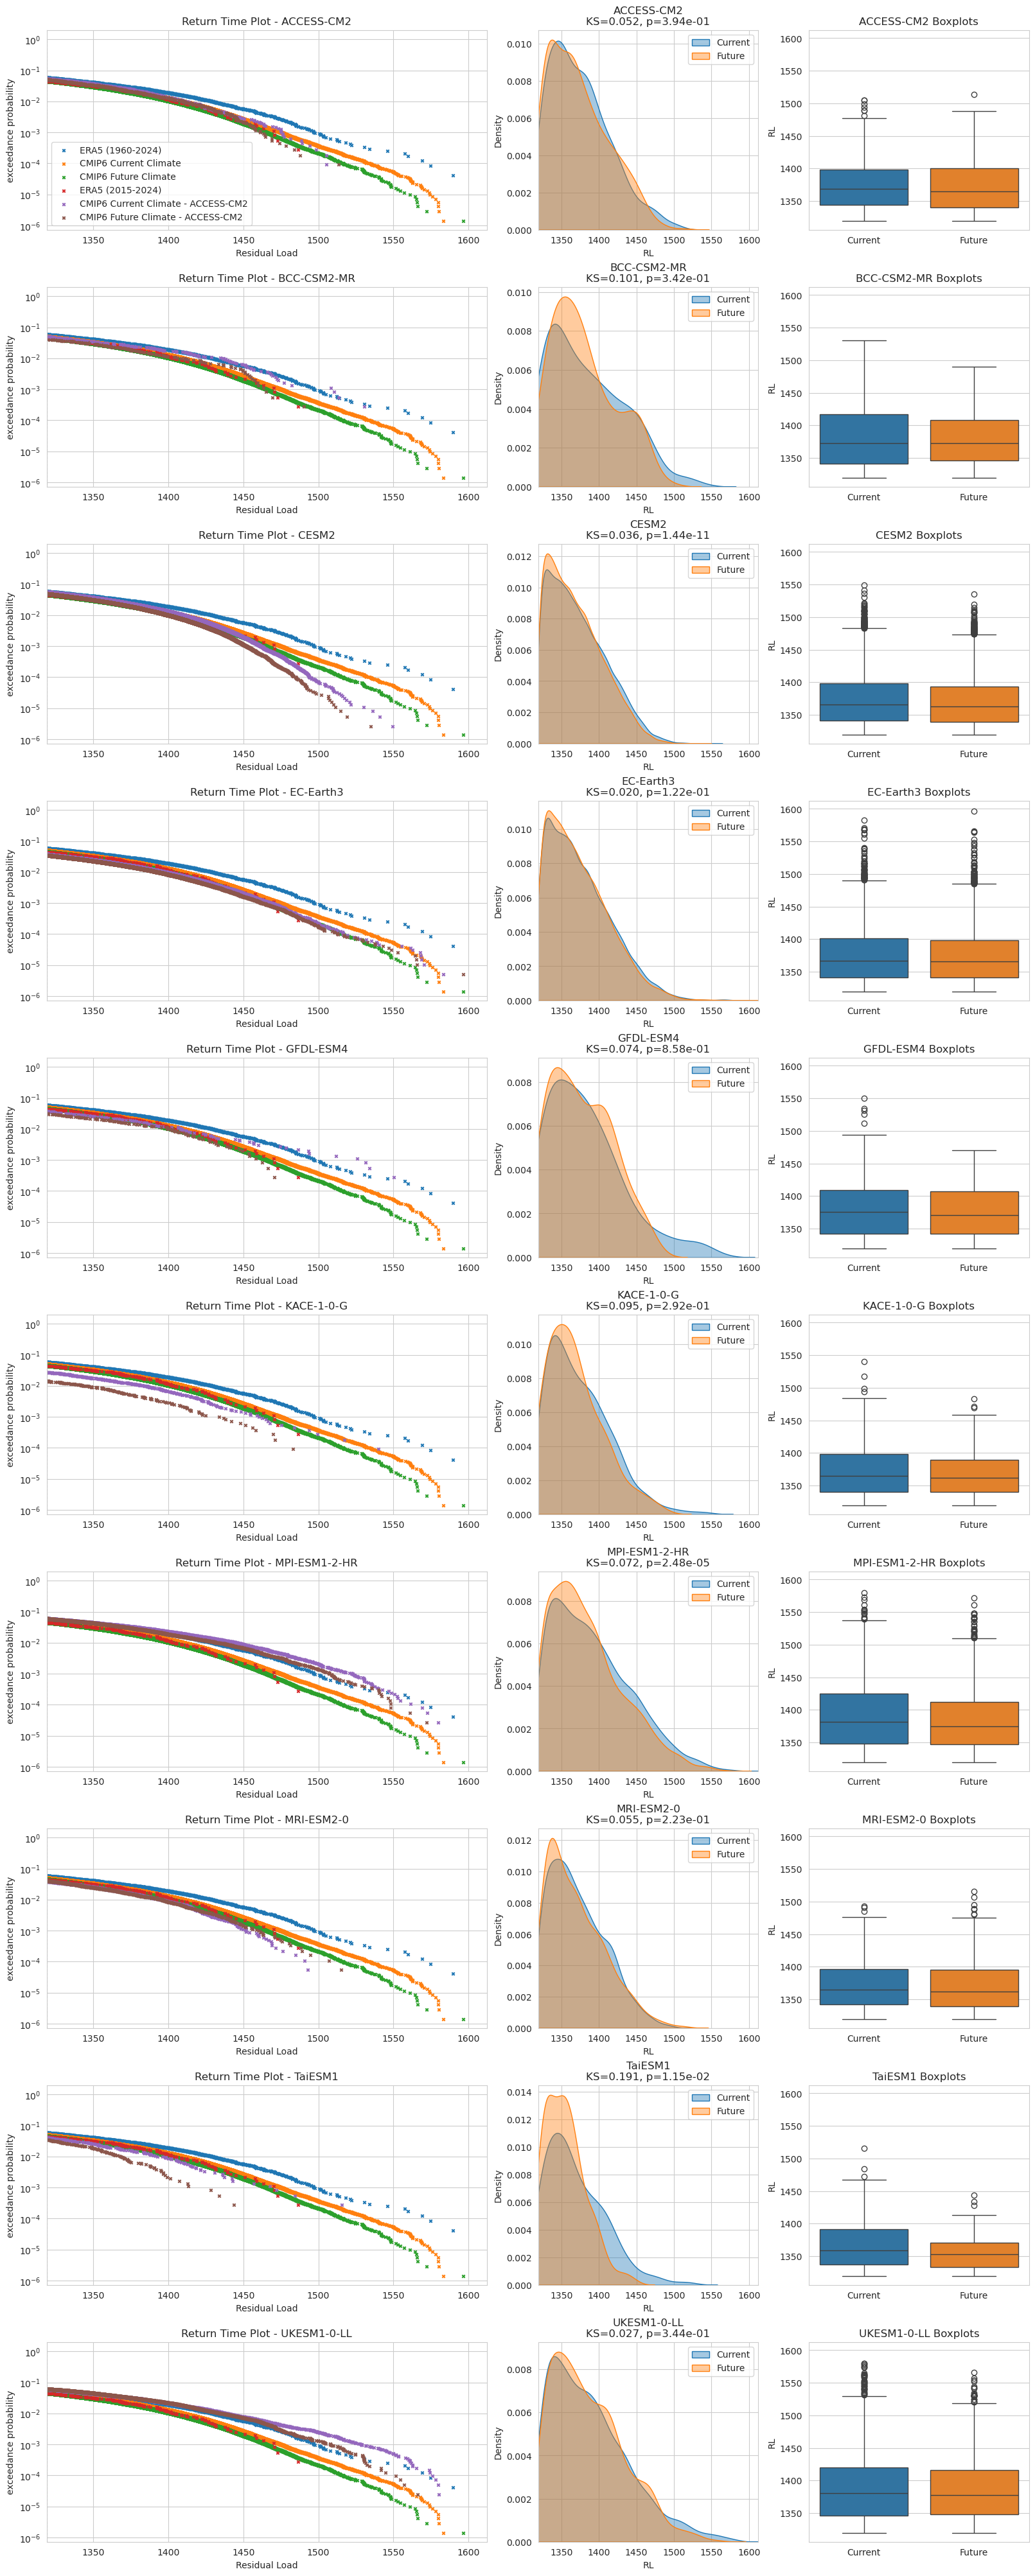

In [ ]:

sns.set_style("whitegrid")

n = len(np.unique(res_load_fut.ESM))

fig, axes = plt.subplots(
    nrows=n,
    ncols=3,
    figsize=(16, 4 * n),
    width_ratios=[2, 1, 1],
    constrained_layout=True,
    sharex=False,
    sharey=False
)
threshold = np.float64(1319.138650687668)
maximum = max(res_load_fut.values.ravel().max(), res_load_curr_clim.values.ravel().max())


for i, esm in enumerate(np.unique(res_load_fut.ESM)):


    cur_all = res_load_curr_clim.where(res_load_curr_clim.ESM == esm, drop=True).values.ravel()
    cur = cur_all[cur_all > threshold]
    fut_all = res_load_fut.where(res_load_fut.ESM == esm, drop=True).values.ravel() 
    fut = fut_all[fut_all > threshold]

    # -------------------------
    # Returntime plot
    # -------------------------
    ax_1 = axes[i, 0]
    for res_load, label in zip(RLs, labels):

        # Example: extreme residual load values
        extremes = res_load # your event values

        # Sort ascending
        x = np.sort(extremes)

        # Rank
        m = np.arange(1, len(x) + 1)

        # Total observation period (important!)
        N = len(extremes)  # OR number of years, depending on method

        # Return period
        # T = (N + 1) / (N + 1 - m)
        T = (1 - (m/(N+1)))  # equivalent, more direct formula
            


        ax_1.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1

    extremes = res_load_curr_clim.where(res_load_curr_clim.ESM == esm, drop=True).values.ravel() 
    label = f'CMIP6 Current Climate'
    # Sort ascending
    x = np.sort(extremes)

    # Rank
    m = np.arange(1, len(x) + 1)

    # Total observation period (important!)
    N = len(extremes)  # OR number of years, depending on method

    # Return period
    # T = (N + 1) / (N + 1 - m)
    T = (1 - (m/(N+1)))  # equivalent, more direct formula
    ax_1.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1
    
    extremes = res_load_fut.where(res_load_fut.ESM == esm, drop=True).values.ravel() 
    label = f'CMIP6 Future Climate'
    # Sort ascending
    x = np.sort(extremes)

    # Rank
    m = np.arange(1, len(x) + 1)

    # Total observation period (important!)
    N = len(extremes)  # OR number of years, depending on method

    # Return period
    # T = (N + 1) / (N + 1 - m)
    T = (1 - (m/(N+1)))  # equivalent, more direct formula
    ax_1.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1
    ax_1.vlines(threshold, ymin=0, ymax=1, color='gray', linestyle='--', linewidth=0.8)
    ax_1.set_yscale('log')
    # ax_1.xscale('log')
    ax_1.set_xlim(threshold, maximum*1.01)
    # ax_1.set_xlim(np.float64(1470.138650687668), np.float64(1480.223514139268)*1.01)

    # ax_1.set_ylim(1e-4, 1e-1)
    ax_1.set_ylabel('exceedance probability')
    ax_1.set_xlabel('Residual Load')
    ax_1.set_title(f'Return Time Plot - {esm}')
    # ax_1.legend(loc='upper left', bbox_to_anchor=(0.5, -0.41))
    if i == 0:
        ax_1.legend(loc='lower left')
    ax_1.grid(True)

    

    # -------------------------
    # KDE plot
    # -------------------------
    ax_2 = axes[i, 1]

    sns.kdeplot(cur, ax=ax_2, label='Current', fill=True, alpha=0.4)
    sns.kdeplot(fut, ax=ax_2, label='Future', fill=True, alpha=0.4)
    # ax_2.set_xlim(0, 25)
    # metrics
    ks_stat, ks_p = ks_2samp(cur, fut)

    ax_2.set_xlim(threshold, maximum*1.01)
    ax_2.set_title(f"{esm}\nKS={ks_stat:.3f}, p={ks_p:.2e}")
    ax_2.set_xlabel('RL')
    ax_2.legend()

    # -------------------------
    # Boxplot
    # -------------------------
    ax3 = axes[i, 2]

    sns.boxplot(
        data=[cur, fut],
        ax=ax3
    )
    ax3.set_ylim(threshold*0.99, maximum*1.01)
    ax3.set_xticks([0, 1])
    ax3.set_xticklabels(['Current', 'Future'])
    ax3.set_title(f"{esm} Boxplots")
    ax3.set_ylabel('RL')

plt.show()

In [43]:
10**5 * 7 / 365

# 365 * 10* 192

1917.8082191780823

In [ ]:
res_load_ERA5_7d
LEE_7_ERA5['RL_cumulative']
LEE_7_CMIP['RL_cumulative']
LEE_7_fut['RL_cumulative']
LEE_7_ERA5_15_24['RL_cumulative']

0     9584.428025
1     9411.793076
2     9806.489237
3     9294.940874
4     9380.513610
         ...     
72    9501.744800
73    9364.921762
74    9892.719655
75    9299.234201
76    9494.402708
Name: RL_cumulative, Length: 77, dtype: float64

In [89]:
LEE_7_ERA5_15_24

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy,winter_season
2001,2015-01-19,2015-01-25,2015-01-19 00:00:00.000000001,18,24,19,7,1439.293940,1364.007977,66.664621,9548.055836,2002,ERA5_week,ERA5_hist_week,2015,19,14/15
2002,2016-01-15,2016-01-21,2016-01-15 00:00:00.000000006,379,385,385,7,1431.707705,1366.706032,43.255350,9566.942225,2003,ERA5_week,ERA5_hist_week,2016,15,15/16
2003,2016-12-12,2016-12-18,2016-12-12 00:00:00.000000000,710,716,710,7,1394.297059,1328.784991,68.631400,9301.494934,2004,ERA5_week,ERA5_hist_week,2016,346,16/17
2004,2017-01-19,2017-01-25,2017-01-19 00:00:00.000000004,748,754,752,7,1470.397466,1394.847373,60.301206,9763.931611,2005,ERA5_week,ERA5_hist_week,2017,19,16/17
2005,2019-01-19,2019-01-25,2019-01-19 00:00:00.000000005,1478,1484,1483,7,1470.620258,1357.392115,97.549782,9501.744807,2006,ERA5_week,ERA5_hist_week,2019,19,18/19
2006,2020-11-26,2020-12-02,2020-11-26 00:00:00.000000006,2154,2160,2160,7,1395.032961,1337.845965,54.717352,9364.921757,2007,ERA5_week,ERA5_hist_week,2020,330,20/21
2007,2022-12-10,2022-12-16,2022-12-10 00:00:00.000000006,2898,2904,2904,7,1486.441387,1413.245666,35.261726,9892.719664,2008,ERA5_week,ERA5_hist_week,2022,344,22/23
2008,2023-01-22,2023-01-28,2023-01-22 00:00:00.000000004,2941,2947,2945,7,1388.191698,1328.462027,73.743845,9299.234188,2009,ERA5_week,ERA5_hist_week,2023,22,22/23
2009,2023-11-27,2023-12-03,2023-11-27 00:00:00.000000005,3250,3256,3255,7,1463.499258,1356.343244,103.949461,9494.402705,2010,ERA5_week,ERA5_hist_week,2023,331,23/24


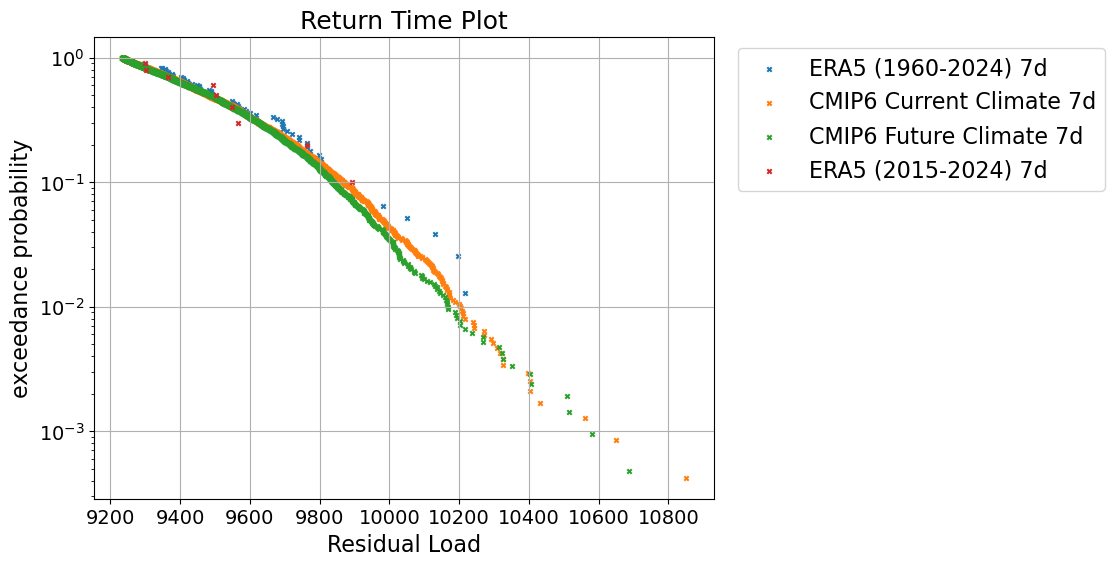

In [43]:
# This is only for the 1d values (but correct otherwise)

RLs = [LEE_7_ERA5['RL_cumulative'], LEE_7_CMIP['RL_cumulative'], LEE_7_fut['RL_cumulative'], LEE_7_ERA5_15_24['RL_cumulative']]
labels = ['ERA5 (1960-2024) 7d', 'CMIP6 Current Climate 7d', 'CMIP6 Future Climate 7d', 'ERA5 (2015-2024) 7d']

# RLs = [# res_load_ERA5, 
#        res_load_curr_clim_1d, res_load_fut_1d, res_load_era5_15_24_1d,
#        res_load_ERA5_1960_1970, res_load_ERA5_1970_1980, res_load_ERA5_1980_1990,
#        res_load_ERA5_1990_2000, res_load_ERA5_2000_2010, res_load_ERA5_2010_2020, res_load_ERA5_2020_2024]
# labels = [#'ERA5 (1960-2024)', 
#           'CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (2015-2024)',
#           'ERA5 (1960-1970)', 'ERA5 (1970-1980)', 'ERA5 (1980-1990)',
#           'ERA5 (1990-2000)', 'ERA5 (2000-2010)', 'ERA5 (2010-2020)', 'ERA5 (2020-2024)']

# RLs = [# res_load_ERA5, 
#        res_load_curr_clim_1d, res_load_fut_1d, res_load_era5_15_24_1d,
#        res_load_ERA5_2015_2019, res_load_ERA5_2020_2024]
# labels = [#'ERA5 (1960-2024)', 
#           'CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (2015-2024)',
#           'ERA5 (2015-2019)', 'ERA5 (2020-2024)']

# RLs = [res_load_era5_15_24]
# labels = ['ERA5 (2015-2024)']
# Plot
plt.figure(figsize=(8,6))


for res_load, label in zip(RLs, labels):

    # Example: extreme residual load values
    extremes = res_load # your event values

    # Sort ascending
    x = np.sort(extremes)

    # Rank
    m = np.arange(1, len(x) + 1)

    # Total observation period (important!)
    N = len(extremes)  # OR number of years, depending on method

    # event rate
    if ('ERA5' in label) and ('15' in label):
        n_years = 10  # ERA5 covers 2015-2024 for this subset
    elif 'ERA5' in label:
        n_years = 65  # ERA5 covers 1960-2024
    else:
        n_years = 10 * 192  # 10 years for each of the 192 runs
    
    lambda_ = N / n_years
    
    # Return period
    # T = (N + 1) / (N + 1 - m)
    T = (1 - (m/(N+1)))  # equivalent, more direct formula
        


    plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1
# plt.vlines(np.float64(1319.138650687668), ymin=0, ymax=1, color='gray', linestyle='--', linewidth=0.8)
plt.yscale('log')
# plt.xscale('log')
# plt.xlim(np.float64(1319.138650687668), np.float64(1596.223514139268)*1.01)
# plt.xlim(np.float64(1470.138650687668), np.float64(1480.223514139268)*1.01)

# plt.ylim(1e-4, 1e-1)
plt.ylabel('exceedance probability')
plt.xlabel('Residual Load')
plt.title('Return Time Plot')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.grid(True)
plt.show()


# # Plot
# plt.figure(figsize=(8,6))


# for res_load, label in zip(RLs, labels):

#     # Example: extreme residual load values
#     extremes = res_load # your event values

#     # Sort descending
#     x = np.sort(extremes)[::-1]

#     # Rank
#     m = np.arange(1, len(x) + 1)

#     # Total observation period (important!)
#     N = len(extremes)  # OR number of years, depending on method

#     # Return period
#     # T = (N + 1) / (N + 1 - m)
#     # T = (1 - (m/(N+1)))  # equivalent, more direct formula
#     # Return period
#     T = (N + 1) / m
        


#     plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1
# plt.vlines(np.float64(1319.138650687668), ymin=0, ymax=1, color='gray', linestyle='--', linewidth=0.8)
# plt.yscale('log')
# # plt.xscale('log')
# plt.xlim(np.float64(1319.138650687668), np.float64(1596.223514139268)*1.01)
# plt.ylabel('Return Period')
# plt.xlabel('Residual Load')
# plt.title('Return Time Plot')
# plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
# plt.grid(True)
# plt.show()

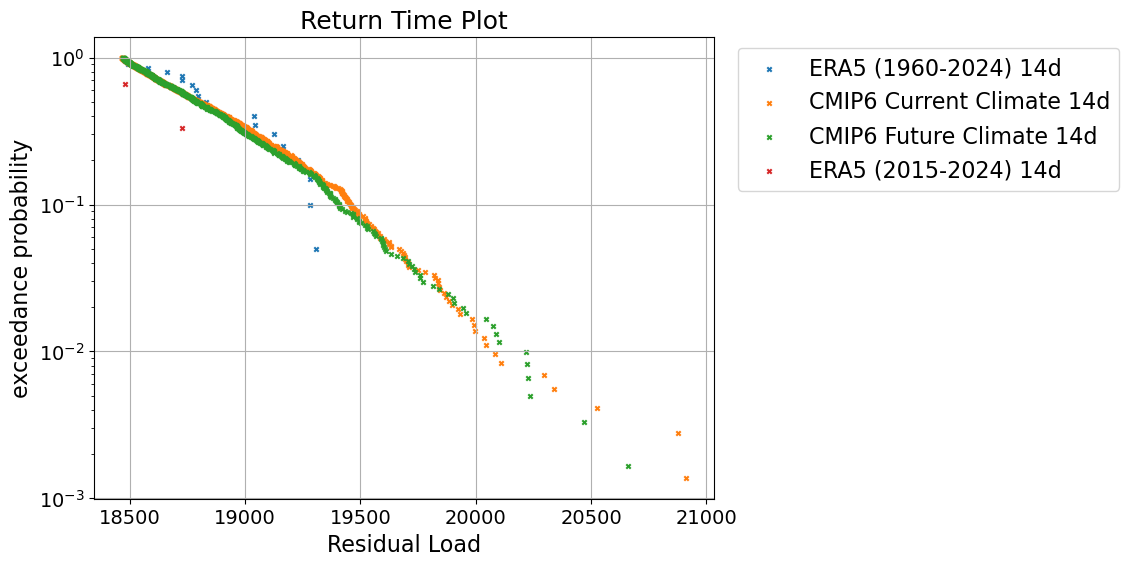

In [44]:
# This is only for the 1d values (but correct otherwise)

RLs = [LEE_14_ERA5['RL_cumulative'], LEE_14_CMIP['RL_cumulative'], LEE_14_fut['RL_cumulative'], LEE_14_ERA5_15_24['RL_cumulative']]
labels = ['ERA5 (1960-2024) 14d', 'CMIP6 Current Climate 14d', 'CMIP6 Future Climate 14d', 'ERA5 (2015-2024) 14d']

# RLs = [# res_load_ERA5, 
#        res_load_curr_clim_1d, res_load_fut_1d, res_load_era5_15_24_1d,
#        res_load_ERA5_1960_1970, res_load_ERA5_1970_1980, res_load_ERA5_1980_1990,
#        res_load_ERA5_1990_2000, res_load_ERA5_2000_2010, res_load_ERA5_2010_2020, res_load_ERA5_2020_2024]
# labels = [#'ERA5 (1960-2024)', 
#           'CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (2015-2024)',
#           'ERA5 (1960-1970)', 'ERA5 (1970-1980)', 'ERA5 (1980-1990)',
#           'ERA5 (1990-2000)', 'ERA5 (2000-2010)', 'ERA5 (2010-2020)', 'ERA5 (2020-2024)']

# RLs = [# res_load_ERA5, 
#        res_load_curr_clim_1d, res_load_fut_1d, res_load_era5_15_24_1d,
#        res_load_ERA5_2015_2019, res_load_ERA5_2020_2024]
# labels = [#'ERA5 (1960-2024)', 
#           'CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (2015-2024)',
#           'ERA5 (2015-2019)', 'ERA5 (2020-2024)']

# RLs = [res_load_era5_15_24]
# labels = ['ERA5 (2015-2024)']
# Plot
plt.figure(figsize=(8,6))


for res_load, label in zip(RLs, labels):

    # Example: extreme residual load values
    extremes = res_load # your event values

    # Sort ascending
    x = np.sort(extremes)

    # Rank
    m = np.arange(1, len(x) + 1)

    # Total observation period (important!)
    N = len(extremes)  # OR number of years, depending on method

    # event rate
    if ('ERA5' in label) and ('15' in label):
        n_years = 10  # ERA5 covers 2015-2024 for this subset
    elif 'ERA5' in label:
        n_years = 65  # ERA5 covers 1960-2024
    else:
        n_years = 10 * 192  # 10 years for each of the 192 runs
    
    lambda_ = N / n_years
    
    # Return period
    # T = (N + 1) / (N + 1 - m)
    T = (1 - (m/(N+1)))  # equivalent, more direct formula
        


    plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1
# plt.vlines(np.float64(1319.138650687668), ymin=0, ymax=1, color='gray', linestyle='--', linewidth=0.8)
plt.yscale('log')
# plt.xscale('log')
# plt.xlim(np.float64(1319.138650687668), np.float64(1596.223514139268)*1.01)
# plt.xlim(np.float64(1470.138650687668), np.float64(1480.223514139268)*1.01)

# plt.ylim(1e-4, 1e-1)
plt.ylabel('exceedance probability')
plt.xlabel('Residual Load')
plt.title('Return Time Plot')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.grid(True)
plt.show()


# # Plot
# plt.figure(figsize=(8,6))


# for res_load, label in zip(RLs, labels):

#     # Example: extreme residual load values
#     extremes = res_load # your event values

#     # Sort descending
#     x = np.sort(extremes)[::-1]

#     # Rank
#     m = np.arange(1, len(x) + 1)

#     # Total observation period (important!)
#     N = len(extremes)  # OR number of years, depending on method

#     # Return period
#     # T = (N + 1) / (N + 1 - m)
#     # T = (1 - (m/(N+1)))  # equivalent, more direct formula
#     # Return period
#     T = (N + 1) / m
        


#     plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1
# plt.vlines(np.float64(1319.138650687668), ymin=0, ymax=1, color='gray', linestyle='--', linewidth=0.8)
# plt.yscale('log')
# # plt.xscale('log')
# plt.xlim(np.float64(1319.138650687668), np.float64(1596.223514139268)*1.01)
# plt.ylabel('Return Period')
# plt.xlabel('Residual Load')
# plt.title('Return Time Plot')
# plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
# plt.grid(True)
# plt.show()

# GPD

In [15]:
threshold = np.float64(1319.138650687668)

excesses_LEE = LEE_dat['RL_mean'] - threshold
excesses_LEE7 = LEE_7['RL_mean'] - threshold
excesses_LEE14 = LEE_14['RL_mean'] - threshold

excesses_LEE_fut = LEE_dat_fut['RL_mean'] - threshold
excesses_LEE7_fut = LEE_7_fut['RL_mean'] - threshold
excesses_LEE14_fut = LEE_14_fut['RL_mean'] - threshold

excesses_LEE_era = LEE_dat_ERA5['RL_mean'] - threshold
excesses_LEE7_era = LEE_7_ERA5['RL_mean'] - threshold
excesses_LEE14_era = LEE_14_ERA5['RL_mean'] - threshold

excesses_LEE_era5_15_24 = LEE_dat_ERA5_15_24['RL_mean'] - threshold
excesses_LEE7_era5_15_24 = LEE_7_ERA5_15_24['RL_mean'] - threshold
excesses_LEE14_era5_15_24 = LEE_14_ERA5_15_24['RL_mean'] - threshold
excesses = [excesses_LEE, excesses_LEE7, excesses_LEE14, 
            excesses_LEE_fut, excesses_LEE7_fut, excesses_LEE14_fut, 
            excesses_LEE_era, excesses_LEE7_era, excesses_LEE14_era,
            excesses_LEE_era5_15_24, excesses_LEE7_era5_15_24, excesses_LEE14_era5_15_24]
labels = ['LEE', 'LEE7', 'LEE14', 
          'LEE_fut', 'LEE7_fut', 'LEE14_fut', 
          'LEE_era', 'LEE7_era', 'LEE14_era', 
          'LEE_era5_15_24', 'LEE7_era5_15_24', 'LEE14_era5_15_24']


In [105]:
len(LEE_7['ESM_run'].unique())

192

In [67]:
def GPD_fit(excesses, threshold, label):
    
    # Fit GPD to excesses    
    shape, loc, scale = genpareto.fit(excesses, floc=0)
    
    # print("shape (xi):", shape)
    # print("scale (sigma):", scale)
    
    
    # parameters
    u = threshold
    xi = shape
    sigma = scale

    # event rate
    if ('ERA5' in label) and ('15' in label):
        n_years = 10  # ERA5 covers 2015-2024 for this subset
    elif 'ERA5' in label:
        n_years = 65  # ERA5 covers 1960-2024
    else:
        n_years = 10 * 192  # 10 years for each of the 192 runs
    lambda_ = len(excesses) / n_years

    # return periods
    T = np.array([1.1, 1.5, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 1500, 2000])  # in years

    # return levels
    z_T = u + (sigma / xi) * ((lambda_ * T)**xi - 1)

    # Exceedance probability for return levels
    p_T = 1 - (1 + xi * (z_T - u) / sigma)**(-1/xi)

    return z_T

In [60]:
GPD_fit(excesses[0], threshold)

array([1361.298757  , 1396.54960888, 1419.0300351 , 1438.44689127,
       1460.11444377, 1473.93243084, 1485.867341  , 1499.18568102,
       1507.67914839, 1512.10030096, 1515.01514961])

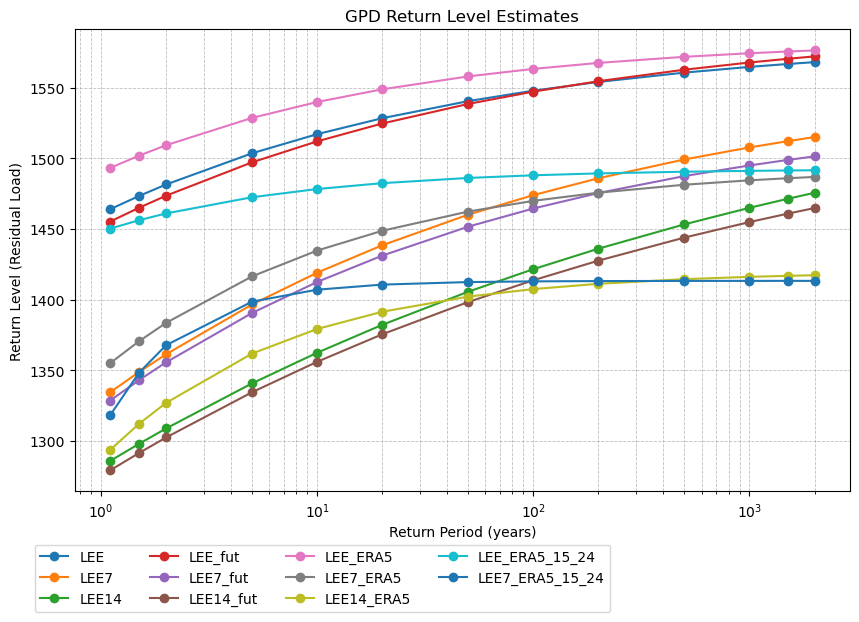

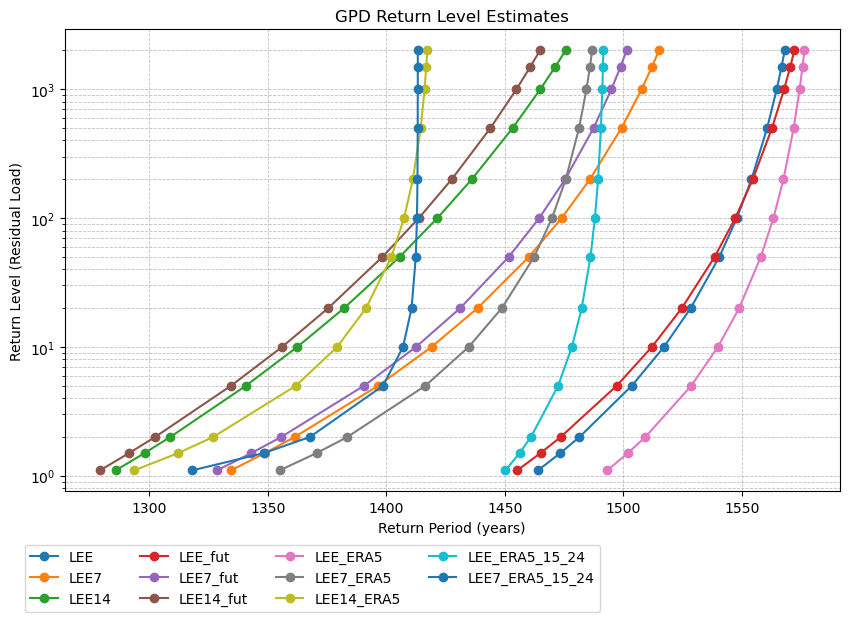

In [68]:
excesses = [excesses_LEE, excesses_LEE7, excesses_LEE14, 
            excesses_LEE_fut, excesses_LEE7_fut, excesses_LEE14_fut, 
            excesses_LEE_era, excesses_LEE7_era, excesses_LEE14_era,
            excesses_LEE_era5_15_24, excesses_LEE7_era5_15_24
            ]
labels = ['LEE', 'LEE7', 'LEE14', 
          'LEE_fut', 'LEE7_fut', 'LEE14_fut', 
          'LEE_ERA5', 'LEE7_ERA5', 'LEE14_ERA5',
          'LEE_ERA5_15_24', 'LEE7_ERA5_15_24'
          ]

z_T_list = []
for exc, label in zip(excesses, labels):
    # print(f"Fitting GPD for {label}...")
    z_T = GPD_fit(exc, threshold, label)
    z_T_list.append(z_T)

# Plot return levels
plt.figure(figsize=(10, 6))
T = np.array([1.1, 1.5, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 1500, 2000])  # in years
for z_T, label in zip(z_T_list, labels):
    plt.plot(T, z_T, marker='o', label=label)
plt.xscale('log')
plt.xlabel('Return Period (years)')
plt.ylabel('Return Level (Residual Load)')
plt.title('GPD Return Level Estimates')
plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.8)
plt.legend(bbox_to_anchor=(0.7, -0.1), ncols=4)
plt.show()

# Plot return levels
plt.figure(figsize=(10, 6))
T = np.array([1.1, 1.5, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 1500, 2000])  # in years
for z_T, label in zip(z_T_list, labels):
    plt.plot(z_T, T, marker='o', label=label)
plt.yscale('log')
plt.xlabel('Return Period (years)')
plt.ylabel('Return Level (Residual Load)')
plt.title('GPD Return Level Estimates')
plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.8)
plt.legend(bbox_to_anchor=(0.7, -0.1), ncols=4)
plt.show()

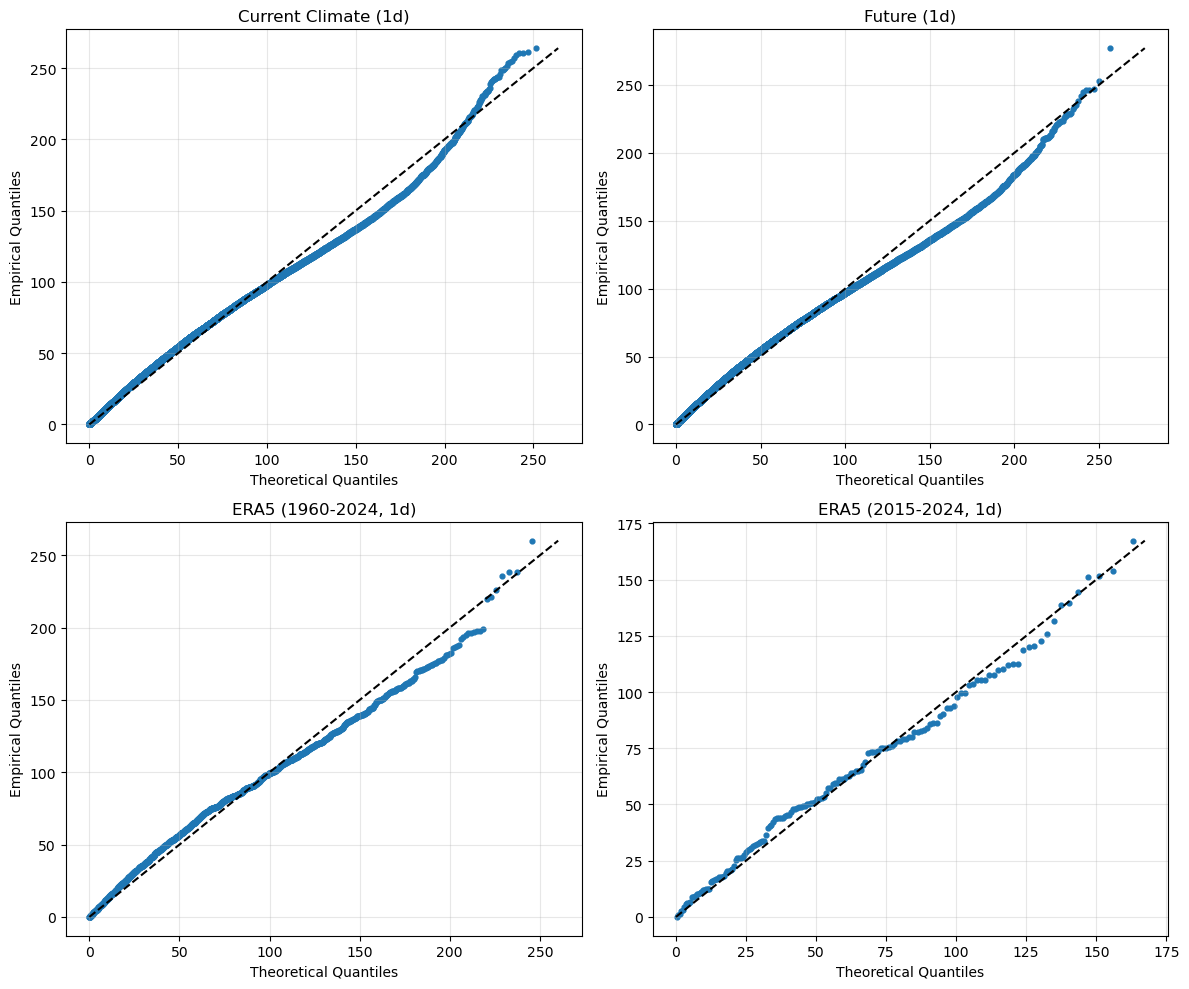

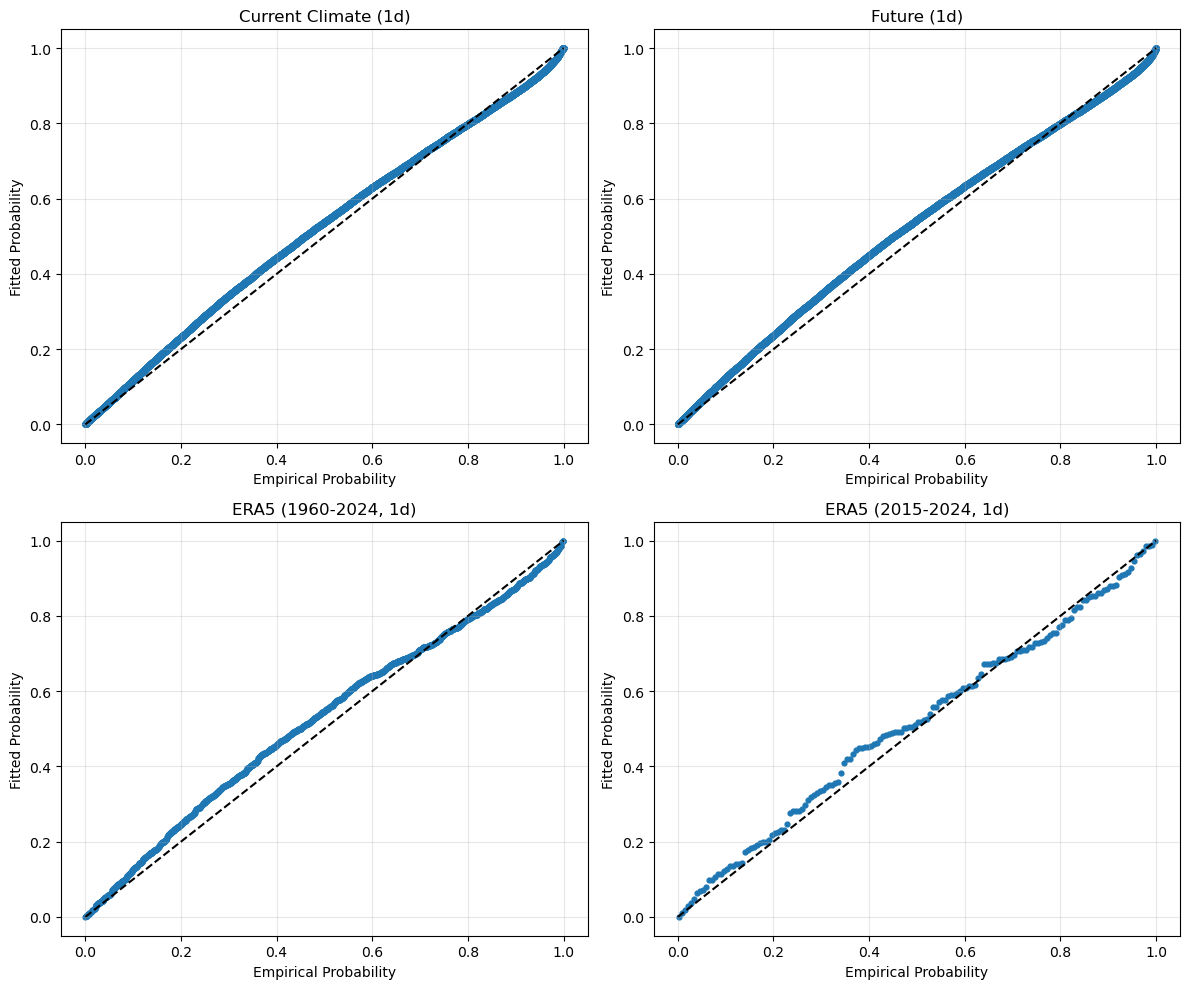

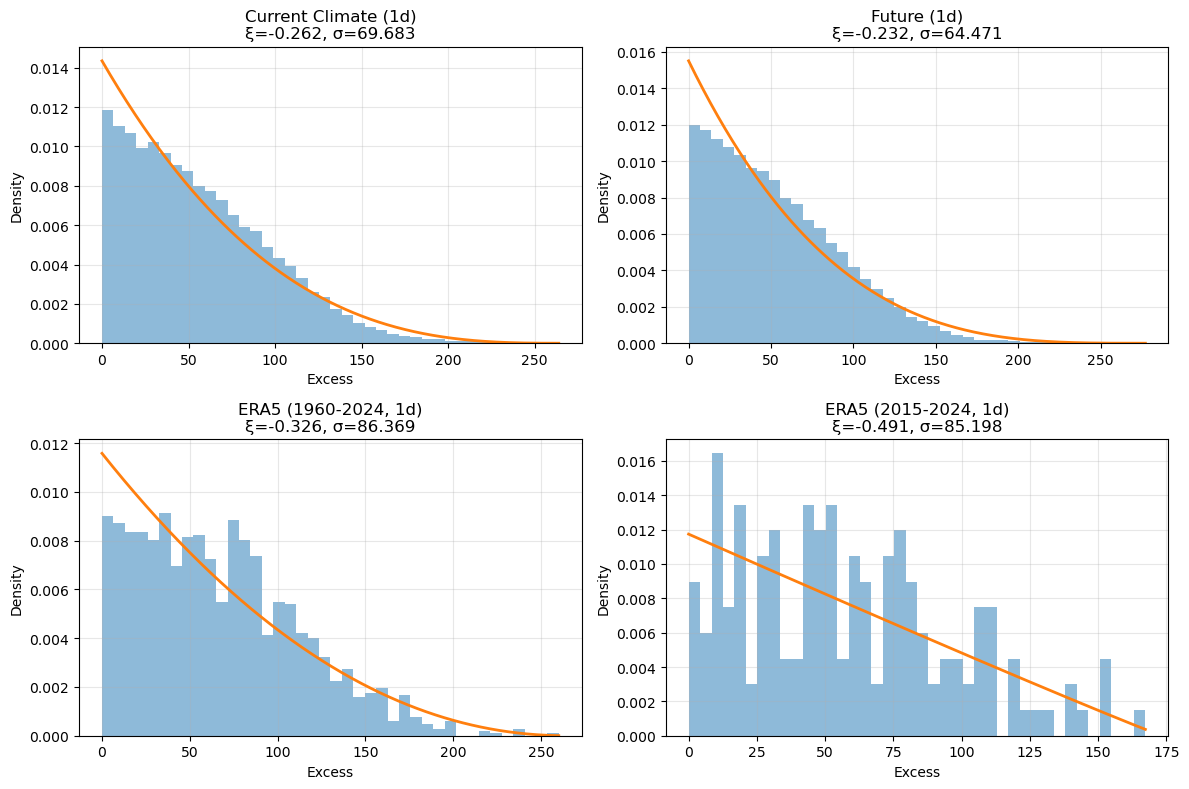

In [84]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import genpareto


# ============================================================
# SETTINGS
# ============================================================

T = np.array([1.1, 1.5, 2, 5, 10, 20,
              50, 100, 200, 500,
              1000, 1500, 2000])


# ============================================================
# HELPERS
# ============================================================

def get_nyears(label):

    # IMPORTANT: fixed logical condition
    if ('ERA5' in label) and ('15' in label):
        return 10

    elif 'ERA5' in label:
        return 65

    else:
        return 10 * 192


def fit_gpd(excesses):

    xi, loc, sigma = genpareto.fit(excesses, floc=0)

    return xi, sigma


def return_level(T, u, xi, sigma, lam):

    # Stable xi -> 0 limit
    if abs(xi) < 1e-6:
        return u + sigma * np.log(lam * T)

    return u + (sigma / xi) * ((lam * T)**xi - 1)


# ============================================================
# MAIN FIT STORAGE
# ============================================================

fit_results = {}

for exc, label in zip(excesses, labels):

    xi, sigma = fit_gpd(exc)

    n_years = get_nyears(label)

    lam = len(exc) / n_years

    zT = return_level(T, threshold, xi, sigma, lam)

    fit_results[label] = {
        'excesses': exc,
        'xi': xi,
        'sigma': sigma,
        'lambda': lam,
        'n_years': n_years,
        'zT': zT
    }


# # ============================================================
# # 1. PARAMETER COMPARISON
# # ============================================================

# xis = [fit_results[l]['xi'] for l in labels]
# sigmas = [fit_results[l]['sigma'] for l in labels]
# lambdas = [fit_results[l]['lambda'] for l in labels]

# fig, ax = plt.subplots(3, 1, figsize=(12, 10))

# ax[0].bar(labels, xis)
# ax[0].set_ylabel("Shape ξ")
# ax[0].grid(alpha=0.3)

# ax[1].bar(labels, sigmas)
# ax[1].set_ylabel("Scale σ")
# ax[1].grid(alpha=0.3)

# ax[2].bar(labels, lambdas)
# ax[2].set_ylabel("Exceedance rate λ")
# ax[2].grid(alpha=0.3)

# for a in ax:
#     a.tick_params(axis='x', rotation=90)

# plt.tight_layout()
# plt.show()


# # ============================================================
# # 2. RETURN LEVEL PLOTS
# # ============================================================

# plt.figure(figsize=(10, 6))

# for label in labels:

#     plt.plot(
#         T,
#         fit_results[label]['zT'],
#         marker='o',
#         label=label
#     )

# plt.xscale('log')

# plt.xlabel('Return Period (years)')
# plt.ylabel('Return Level')
# plt.title('GPD Return Levels')

# plt.grid(True, which='both',
#          linestyle='--',
#          alpha=0.5)

# plt.legend(bbox_to_anchor=(1.02, 1),
#            loc='upper left')

# plt.tight_layout()
# plt.show()


# # ============================================================
# # 3. RETURN LEVEL PLOTS + EMPIRICAL POINTS
# # ============================================================

# plt.figure(figsize=(12, 7))

# for label in labels:

#     result = fit_results[label]

#     exc = result['excesses']

#     n_years = result['n_years']

#     zT = result['zT']

#     # fitted curve
#     plt.plot(T, zT,
#              linewidth=2,
#              label=label)

#     # empirical return periods
#     exc_sorted = np.sort(exc)[::-1]

#     ranks = np.arange(1, len(exc_sorted)+1)

#     T_emp = n_years / ranks

#     z_emp = threshold + exc_sorted

#     plt.scatter(
#         T_emp,
#         z_emp,
#         s=12,
#         alpha=0.5
#     )

# plt.xscale('log')

# plt.xlabel('Return Period (years)')
# plt.ylabel('Return Level')

# plt.title('Return Levels with Empirical Observations')

# plt.grid(True, which='both',
#          linestyle='--',
#          alpha=0.5)

# plt.legend(bbox_to_anchor=(1.02, 1),
#            loc='upper left')

# plt.tight_layout()
# plt.show()


# ============================================================
# 4. QQ PLOTS
# ============================================================

ncols = 2
nrows = int(np.ceil(len(labels) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(12, 5 * nrows)
)

axes = axes.flatten()

for i, label in enumerate(labels):

    ax = axes[i]

    result = fit_results[label]

    exc = np.sort(result['excesses'])

    xi = result['xi']
    sigma = result['sigma']

    n = len(exc)

    p = (np.arange(1, n + 1) - 0.5) / n

    q_theory = genpareto.ppf(
        p,
        c=xi,
        scale=sigma
    )

    ax.scatter(q_theory, exc, s=12)

    maxv = max(q_theory.max(), exc.max())

    ax.plot(
        [0, maxv],
        [0, maxv],
        'k--'
    )

    ax.set_title(label)

    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Empirical Quantiles')

    ax.grid(alpha=0.3)

# remove empty panels
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# ============================================================
# 5. PP PLOTS
# ============================================================

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(12, 5 * nrows)
)

axes = axes.flatten()

for i, label in enumerate(labels):

    ax = axes[i]

    result = fit_results[label]

    exc = np.sort(result['excesses'])

    xi = result['xi']
    sigma = result['sigma']

    n = len(exc)

    p_emp = (np.arange(1, n + 1) - 0.5) / n

    p_fit = genpareto.cdf(
        exc,
        c=xi,
        scale=sigma
    )

    ax.scatter(p_emp, p_fit, s=12)

    ax.plot([0, 1],
            [0, 1],
            'k--')

    ax.set_title(label)

    ax.set_xlabel('Empirical Probability')
    ax.set_ylabel('Fitted Probability')

    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# ============================================================
# 6. DENSITY OVERLAY
# ============================================================

ncols = 2
nrows = int(np.ceil(len(labels) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(12, 4 * nrows)
)

axes = axes.flatten()

for i, label in enumerate(labels):

    ax = axes[i]

    result = fit_results[label]

    exc = result['excesses']

    xi = result['xi']
    sigma = result['sigma']

    xgrid = np.linspace(0, exc.max(), 500)

    pdf = genpareto.pdf(
        xgrid,
        c=xi,
        scale=sigma
    )

    ax.hist(
        exc,
        bins=40,
        density=True,
        alpha=0.5
    )

    ax.plot(
        xgrid,
        pdf,
        linewidth=2
    )

    ax.set_title(
        f'{label}\n'
        f'ξ={xi:.3f}, σ={sigma:.3f}'
    )

    ax.set_xlabel('Excess')
    ax.set_ylabel('Density')

    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Fitting GPD for LEE...
Fitting GPD for LEE_fut...
Fitting GPD for LEE_ERA5...
Fitting GPD for LEE_ERA5 (2015-2024)...


/tmp/ipykernel_2303071/3218305994.py:57: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 2500)


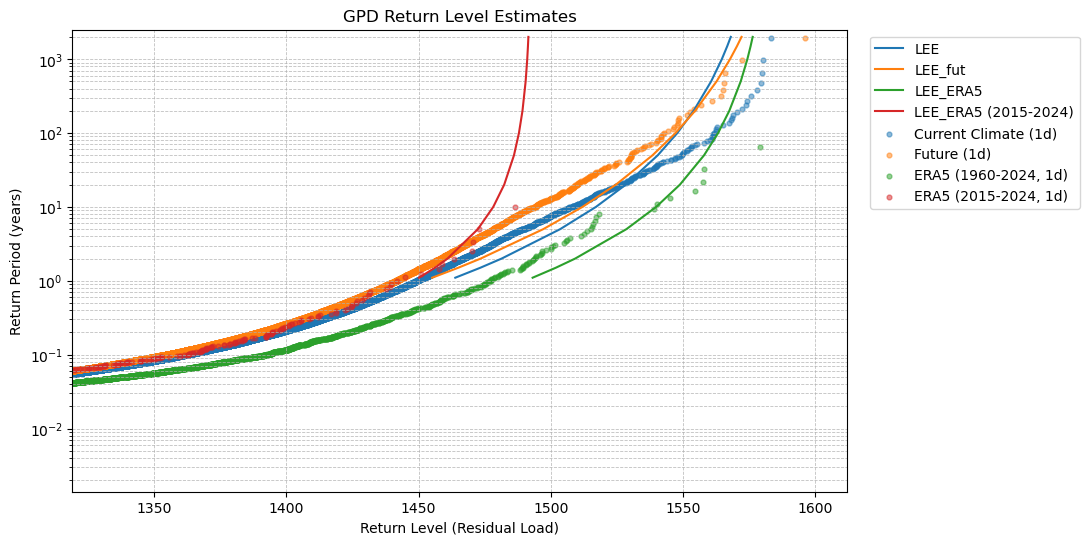

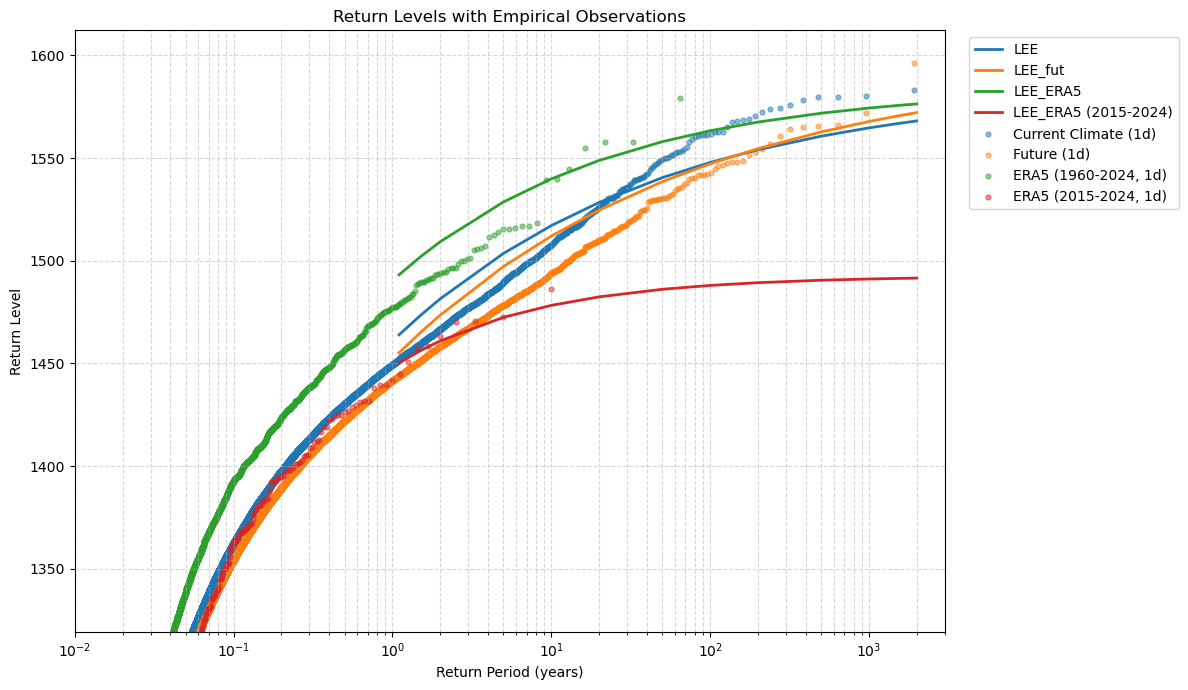

In [ ]:
# GPD Fit with return level plots and empirical points
RLs = [res_load_curr_clim_1d, res_load_fut_1d, res_load_ERA5, res_load_era5_15_24_1d]

labels = ['Current Climate (1d)', 
          'Future (1d)', 
          'ERA5 (1960-2024, 1d)', 
          'ERA5 (2015-2024, 1d)' ]

T = np.array([1.1, 1.5, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 1500, 2000])  # in years

excesses = [excesses_LEE, 
            excesses_LEE_fut, 
            excesses_LEE_era,
            excesses_LEE_era5_15_24
            ]
labels_GPD = ['LEE', 
          'LEE_fut',
          'LEE_ERA5',
          'LEE_ERA5 (2015-2024)'
          ]

z_T_list = []
for exc, label in zip(excesses, labels_GPD):
    print(f"Fitting GPD for {label}...")
    z_T = GPD_fit(exc, threshold, label)
    z_T_list.append(z_T)
    

# Plot return levels
plt.figure(figsize=(10, 6))
for z_T, label in zip(z_T_list, labels_GPD):
    # marker = '^'
    plt.plot(z_T, T, label=label)
for res_load, label in zip(RLs, labels):

    # Example: extreme residual load values
    extremes = res_load # your event values

    # Sort descending
    x = np.sort(extremes)[::-1]

    # Rank
    m = np.arange(1, len(x) + 1)

    # Total observation period (important!)
    N = len(extremes)  # OR number of years, depending on method

    # Return period
    # T = (N + 1) / (N + 1 - m)
    T_all_point = ((N + 1) / m) / 365


    plt.scatter(x, T_all_point, alpha=0.5, s=12, label=label) # Marker = cross, size = 1


plt.yscale('log')
plt.xlim(np.float64(1319.138650687668), np.float64(1596.223514139268)*1.01)
plt.ylim(0, 2500)
plt.ylabel('Return Period (years)')
plt.xlabel('Return Level (Residual Load)')
plt.title('GPD Return Level Estimates')
plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.8)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()



plt.figure(figsize=(12, 7))

for z_T, label in zip(z_T_list, labels_GPD):
    # marker = '^'
    plt.plot(T, z_T, linewidth=2, label=label)
for res_load, label in zip(RLs, labels):

    # Example: extreme residual load values
    extremes = res_load - threshold # your event values

    # Sort descending
    x = np.sort(extremes)[::-1]

    # Rank
    m = np.arange(1, len(x) + 1)

    if 'ERA5' in label and '15' in label:
        N = 10  # ERA5 2015-2024
    elif 'ERA5' in label:
        N = 65  # ERA5 1960-2024
    else:
        N = 10 * 192  # CMIP6 runs
    
    T_emp = N / m
    
    z_emp = threshold + x

    # # Return period
    # # T = (N + 1) / (N + 1 - m)
    # T_all_point = ((N + 1) / m) / 365

    plt.scatter(T_emp, z_emp, alpha=0.5, s=12, label=label) # Marker = cross, size = 1

plt.ylim(np.float64(1319.138650687668), np.float64(1596.223514139268)*1.01)
plt.xlim(10**-2, 10**3 + 2000)
plt.xscale('log')
plt.xlabel('Return Period (years)')
plt.ylabel('Return Level')
plt.title('Return Levels with Empirical Observations')

plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()


# GEV

In [26]:
datasets = [res_load_fut, res_load_fut_7d, res_load_fut_14d,
            res_load_era5_15_24, res_load_era5_15_24_7d, res_load_era5_15_24_14d,
            res_load_curr_clim, res_load_curr_clim_7d , res_load_curr_clim_14d,
            res_load_ERA5, res_load_ERA5_7d , res_load_ERA5_14d]
res_load_fut_sm = res_load_fut.groupby('winter_season').max(dim='time').values.ravel()
res_load_fut_7d_sm = res_load_fut_7d.groupby('winter_season').max(dim='time').values.ravel()
res_load_fut_14d_sm = res_load_fut_14d.groupby('winter_season').max(dim='time').values.ravel()

res_load_era5_15_24_sm = res_load_era5_15_24.groupby('winter_season').max(dim='time').values.ravel()
res_load_era5_15_24_7d_sm = res_load_era5_15_24_7d.groupby('winter_season').max(dim='time').values.ravel()
res_load_era5_15_24_14d_sm = res_load_era5_15_24_14d.groupby('winter_season').max(dim='time').values.ravel()

res_load_curr_clim_sm = res_load_curr_clim.groupby('winter_season').max(dim='time').values.ravel()
res_load_curr_clim_7d_sm = res_load_curr_clim_7d.groupby('winter_season').max(dim='time').values.ravel()
res_load_curr_clim_14d_sm = res_load_curr_clim_14d.groupby('winter_season').max(dim='time').values.ravel()

res_load_ERA5_sm = res_load_ERA5.groupby('winter_season').max(dim='time').values.ravel()
res_load_ERA5_7d_sm = res_load_ERA5_7d.groupby('winter_season').max(dim='time').values.ravel()
res_load_ERA5_14d_sm = res_load_ERA5_14d.groupby('winter_season').max(dim='time').values.ravel()

In [28]:
seasonal_maxima = [res_load_fut_sm, res_load_fut_7d_sm, res_load_fut_14d_sm,
            res_load_era5_15_24_sm, res_load_era5_15_24_7d_sm, res_load_era5_15_24_14d_sm,
            res_load_curr_clim_sm, res_load_curr_clim_7d_sm , res_load_curr_clim_14d_sm,
            res_load_ERA5_sm, res_load_ERA5_7d_sm , res_load_ERA5_14d_sm]

labels = ['Future (1d)', 'Future (7d)', 'Future (14d)',
          'ERA5 (2015-2024, 1d)', 'ERA5 (2015-2024, 7d)', 'ERA5 (2015-2024, 14d)',
          'Current Climate (1d)', 'Current Climate (7d)', 'Current Climate (14d)',
          'ERA5 (1960-2024, 1d)', 'ERA5 (1960-2024, 7d)', 'ERA5 (1960-2024, 14d)']

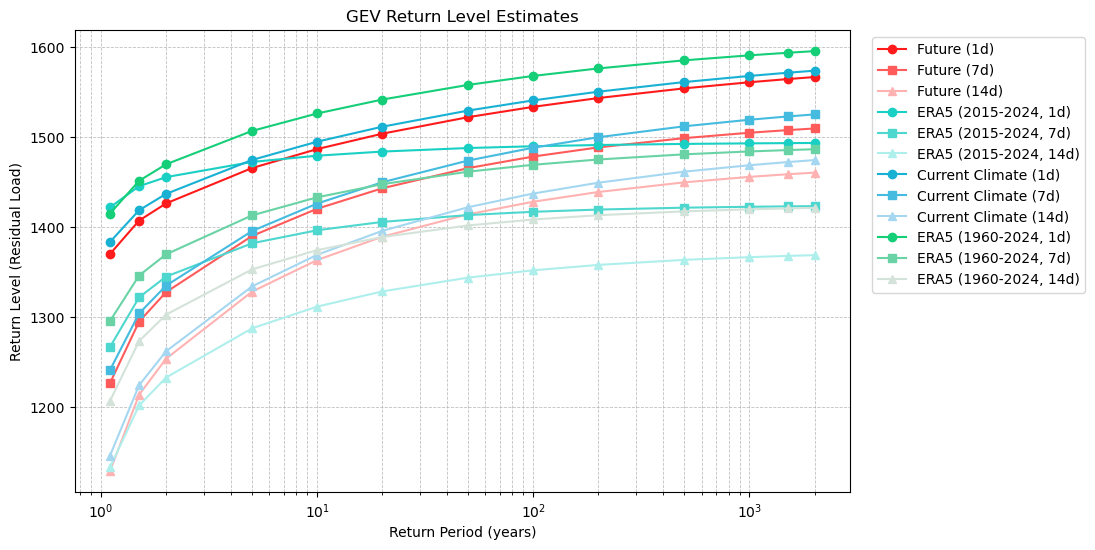

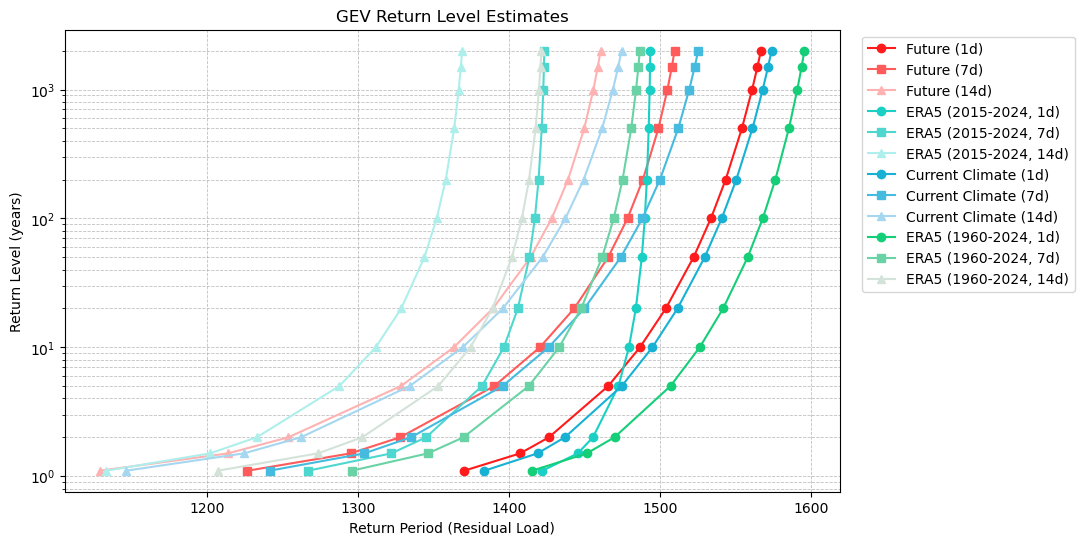

In [29]:
seasonal_maxima = [res_load_fut_sm, res_load_fut_7d_sm, res_load_fut_14d_sm,
            res_load_era5_15_24_sm, res_load_era5_15_24_7d_sm, res_load_era5_15_24_14d_sm,
            res_load_curr_clim_sm, res_load_curr_clim_7d_sm , res_load_curr_clim_14d_sm,
            res_load_ERA5_sm, res_load_ERA5_7d_sm , res_load_ERA5_14d_sm]

labels = ['Future (1d)', 'Future (7d)', 'Future (14d)',
          'ERA5 (2015-2024, 1d)', 'ERA5 (2015-2024, 7d)', 'ERA5 (2015-2024, 14d)',
          'Current Climate (1d)', 'Current Climate (7d)', 'Current Climate (14d)',
          'ERA5 (1960-2024, 1d)', 'ERA5 (1960-2024, 7d)', 'ERA5 (1960-2024, 14d)']

# Make a color scale with a different color for each time frame and a different shade for each data source (CMIP vs ERA5)
colors = [
    # Future
    "#FF1B1B",  # Future (1d) - dark red
    "#FF5B5B",  # Future (7d) - soft red
    '#FFB2B2',  # Future (14d) - Lightest red

    # ERA5 (2015-2024)
    "#1AD0C4",  # ERA5 (2015-2024, 1d) - Teal
    "#4ED7CE",  # ERA5 (2015-2024, 7d) - Lighter teal
    '#AEEFEC',  # ERA5 (2015-2024, 14d) - Lightest teal

    # Current Climate
    "#18B1D3",  # Current Climate (1d) - Sky blue
    "#45BBDF",  # Current Climate (7d) - Lighter sky blue
    '#A5D7F1',  # Current Climate (14d) - Lightest sky blue

    # ERA5 (1960-2024)
    "#15CE78",  # ERA5 (1960-2024, 1d) - Mint green
    "#69D3A5",  # ERA5 (1960-2024, 7d) - Lighter mint green
    '#D4E3DA'   # ERA5 (1960-2024, 14d) - Lightest mint green
]


z_T_list = []
T = np.array([1.1, 1.5, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 1500, 2000])  # in years

for seas_max, label in zip(seasonal_maxima, labels):
    # print(f"Fitting GEV for {label}...")
    x = np.asarray(seas_max)

    # standardize
    x_std = (x - x.mean()) / x.std()

    shape, loc, scale = genextreme.fit(x_std)
    
    # shape, loc, scale = genextreme.fit(seas_max)

    # return levels
    # z_T = genextreme.ppf(1 - 1/T, shape, loc=loc, scale=scale)
    
    mu = x.mean()
    sigma = x.std()

    z_T_std = genextreme.ppf(
        1 - 1/T,
        shape,
        loc=loc,
        scale=scale
    )

    # transform back
    z_T = z_T_std * sigma + mu
    
    z_T_list.append(z_T)

# Plot return levels
plt.figure(figsize=(10, 6))
for z_T, label, color in zip(z_T_list, labels, colors):
    if '1d' in label:
        marker = 'o'
    elif '7d' in label:
        marker = 's'
    else:        
        marker = '^'
    plt.plot(T, z_T, marker=marker, label=label, color=color)
plt.xscale('log')
plt.xlabel('Return Period (years)')
plt.ylabel('Return Level (Residual Load)')
plt.title('GEV Return Level Estimates')
plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.8)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

# Plot return levels
plt.figure(figsize=(10, 6))
for z_T, label, color in zip(z_T_list, labels, colors):
    if '1d' in label:
        marker = 'o'
    elif '7d' in label:
        marker = 's'
    else:        
        marker = '^'
    plt.plot(z_T,T, marker=marker, label=label, color=color)
plt.yscale('log')
plt.xlabel('Return Period (Residual Load)')
plt.ylabel('Return Level (years)')
plt.title('GEV Return Level Estimates')
plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.8)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

Fitting GEV for Future (1d)...
Fitting GEV for ERA5 (2015-2024, 1d)...
Fitting GEV for Current Climate (1d)...
Fitting GEV for ERA5 (1960-2024, 1d)...


/tmp/ipykernel_2303071/3204027361.py:158: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 2500)


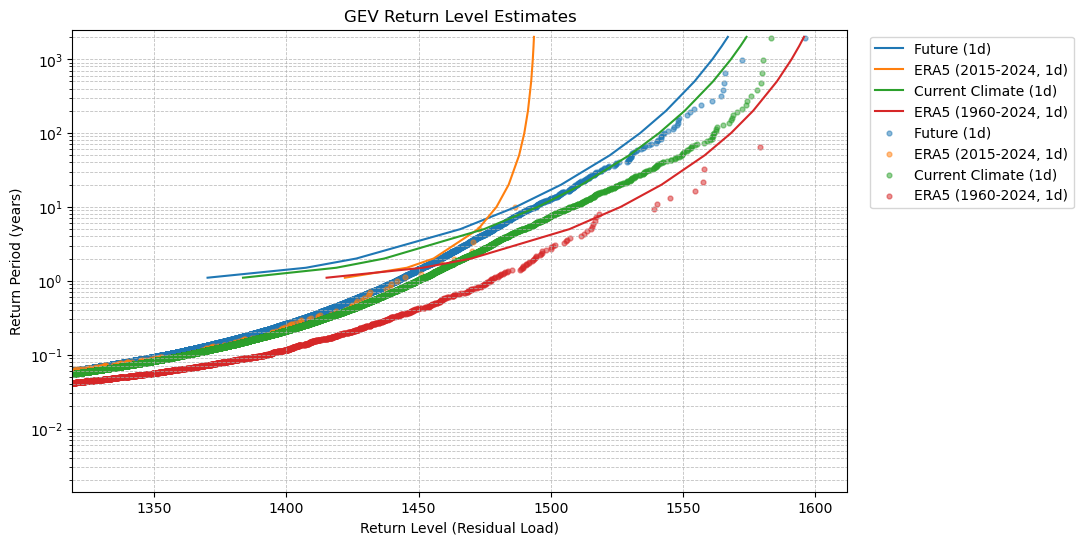

In [87]:
seasonal_maxima = [res_load_fut_sm, 
            res_load_era5_15_24_sm, 
            res_load_curr_clim_sm, 
            res_load_ERA5_sm]

RLs = [res_load_fut_1d, res_load_era5_15_24_1d, res_load_curr_clim_1d, res_load_ERA5]

labels = ['Future (1d)', 
          'ERA5 (2015-2024, 1d)', 
          'Current Climate (1d)', 
          'ERA5 (1960-2024, 1d)' ]

z_T_list = []
z_T_list_2 = []
T = np.array([1.1, 1.5, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 1500, 2000])  # in years

for seas_max, label in zip(seasonal_maxima, labels):
    print(f"Fitting GEV for {label}...")
    
    
    x = np.asarray(seas_max)

    # standardize
    x_std = (x - x.mean()) / x.std()

    shape, loc, scale = genextreme.fit(x_std)
    
    # shape, loc, scale = genextreme.fit(seas_max)

    # return levels
    # z_T = genextreme.ppf(1 - 1/T, shape, loc=loc, scale=scale)
    
    mu = x.mean()
    sigma = x.std()

    z_T_std = genextreme.ppf(
        1 - 1/T,
        shape,
        loc=loc,
        scale=scale
    )

    # transform back
    z_T = z_T_std * sigma + mu
    
    z_T_list.append(z_T)
    
    # x_fit_std = np.linspace(x_std.min()-1, x_std.max()+1, 500)

    # p_fit = genextreme.sf(
    #     x_fit_std,
    #     shape,
    #     loc=loc,
    #     scale=scale
    # )

    # # back transform
    # x_fit = x_fit_std * sigma + mu

    # z_T_list_2.append((x_fit, p_fit))


# # Plot return levels
# plt.figure(figsize=(10, 6))
# # for z_T, label in zip(z_T_list_2, labels):
#     # marker = '^'
# for (x_fit, p_fit), label in zip(z_T_list_2, labels):
#     plt.plot(x_fit, p_fit, label=label)
#     # plt.plot(z_T, T, label=label)
# for res_load, label in zip(RLs, labels):

#     # Example: extreme residual load values
#     extremes = res_load # your event values

#     # Sort ascending
#     x = np.sort(extremes)

#     # Rank
#     m = np.arange(1, len(x) + 1)

#     # Total observation period (important!)
#     N = len(extremes)  # OR number of years, depending on method

#     # Return period
#     # T = (N + 1) / (N + 1 - m)
#     T_all_point = (1 - (m/(N+1)))
        
#     plt.scatter(x, T_all_point, marker='x', s=10, label=label) # Marker = cross, size = 1


# plt.yscale('log')
# plt.xlim(np.float64(1319.138650687668), np.float64(1596.223514139268)*1.01)
# plt.ylim(10**-9, 0)
# plt.xlabel('Return Period (years)')
# plt.ylabel('Return Level (Residual Load)')
# plt.title('GEV Return Level Estimates')
# plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.8)
# plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
# plt.show()


# Plot return levels
plt.figure(figsize=(10, 6))
for z_T, label in zip(z_T_list, labels):
    # marker = '^'
    plt.plot(z_T, T, label=label)
# for res_load, label in zip(RLs, labels):

#     # Example: extreme residual load values
#     extremes = res_load # your event values

#     # Sort ascending
#     x = np.sort(extremes)[::-1]

#     # Rank
#     m = np.arange(1, len(x) + 1)

#     # Total observation period (important!)
#     N = len(extremes)  # OR number of years, depending on method

#     # Return period
#     # T = (N + 1) / (N + 1 - m)
#     T_all_point = (N + 1) / m 
        


#     plt.scatter(x, T_all_point/365, marker='x', s=10, label=label) # Marker = cross, size = 1
for res_load, label in zip(RLs, labels):

    # Example: extreme residual load values
    extremes = res_load - threshold # your event values

    # Sort descending
    x = np.sort(extremes)[::-1]

    # Rank
    m = np.arange(1, len(x) + 1)

    if 'ERA5' in label and '15' in label:
        N = 10  # ERA5 2015-2024
    elif 'ERA5' in label:
        N = 65  # ERA5 1960-2024
    else:
        N = 10 * 192  # CMIP6 runs
    
    T_emp = N / m
    
    z_emp = threshold + x

    # # Return period
    # # T = (N + 1) / (N + 1 - m)
    # T_all_point = ((N + 1) / m) / 365

    plt.scatter(z_emp, T_emp, alpha=0.5, s=12, label=label) # Marker = cross, size = 1

plt.yscale('log')
plt.xlim(np.float64(1319.138650687668), np.float64(1596.223514139268)*1.01)
plt.ylim(0, 2500)
plt.ylabel('Return Period (years)')
plt.xlabel('Return Level (Residual Load)')
plt.title('GEV Return Level Estimates')
plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.8)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

Fitting GEV for Future (1d)...
Fitting GEV for ERA5 (2015-2024, 1d)...
Fitting GEV for Current Climate (1d)...
Fitting GEV for ERA5 (1960-2024, 1d)...


/tmp/ipykernel_2303071/1501391703.py:78: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 2500)


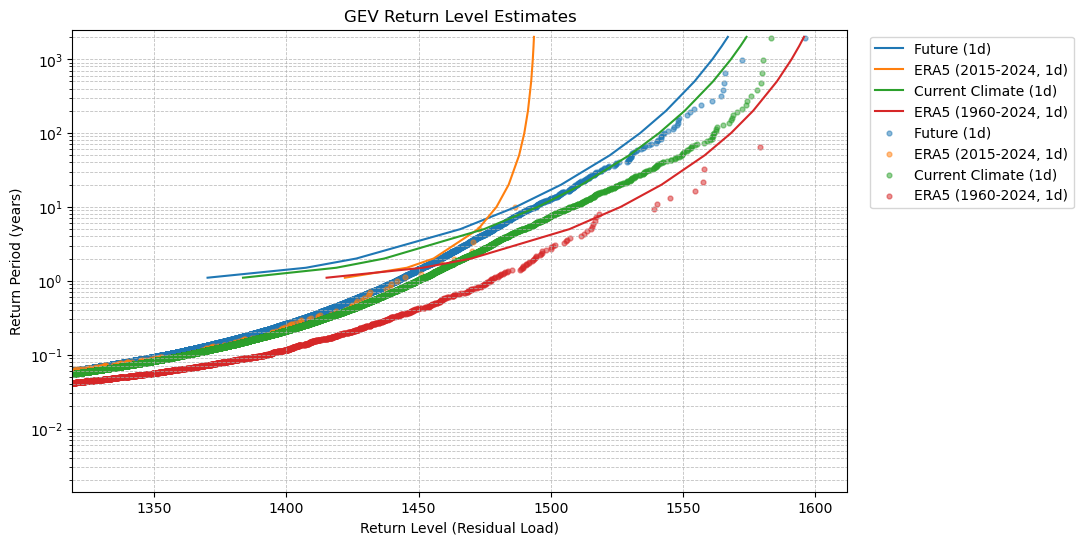

In [88]:
seasonal_maxima = [res_load_fut_sm, 
            res_load_era5_15_24_sm, 
            res_load_curr_clim_sm, 
            res_load_ERA5_sm]

RLs = [res_load_fut_1d, res_load_era5_15_24_1d, res_load_curr_clim_1d, res_load_ERA5]

labels = ['Future (1d)', 
          'ERA5 (2015-2024, 1d)', 
          'Current Climate (1d)', 
          'ERA5 (1960-2024, 1d)' ]

z_T_list = []
z_T_list_2 = []
T = np.array([1.1, 1.5, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 1500, 2000])  # in years

for seas_max, label in zip(seasonal_maxima, labels):
    print(f"Fitting GEV for {label}...")
    
    
    x = np.asarray(seas_max)

    # standardize
    x_std = (x - x.mean()) / x.std()

    shape, loc, scale = genextreme.fit(x_std)
    
    mu = x.mean()
    sigma = x.std()

    z_T_std = genextreme.ppf(
        1 - 1/T,
        shape,
        loc=loc,
        scale=scale
    )

    # transform back
    z_T = z_T_std * sigma + mu
    
    z_T_list.append(z_T)


# Plot return levels
plt.figure(figsize=(10, 6))
for z_T, label in zip(z_T_list, labels):
    # marker = '^'
    plt.plot(z_T, T, label=label)

#     plt.scatter(x, T_all_point/365, marker='x', s=10, label=label) # Marker = cross, size = 1
for res_load, label in zip(RLs, labels):

    # Example: extreme residual load values
    extremes = res_load - threshold # your event values

    # Sort descending
    x = np.sort(extremes)[::-1]

    # Rank
    m = np.arange(1, len(x) + 1)

    if 'ERA5' in label and '15' in label:
        N = 10  # ERA5 2015-2024
    elif 'ERA5' in label:
        N = 65  # ERA5 1960-2024
    else:
        N = 10 * 192  # CMIP6 runs
    
    T_emp = N / m
    
    z_emp = threshold + x


    plt.scatter(z_emp, T_emp, alpha=0.5, s=12, label=label) # Marker = cross, size = 1

plt.yscale('log')
plt.xlim(np.float64(1319.138650687668), np.float64(1596.223514139268)*1.01)
plt.ylim(0, 2500)
plt.ylabel('Return Period (years)')
plt.xlabel('Return Level (Residual Load)')
plt.title('GEV Return Level Estimates')
plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.8)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

/tmp/ipykernel_2303071/2492177577.py:101: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 2500)


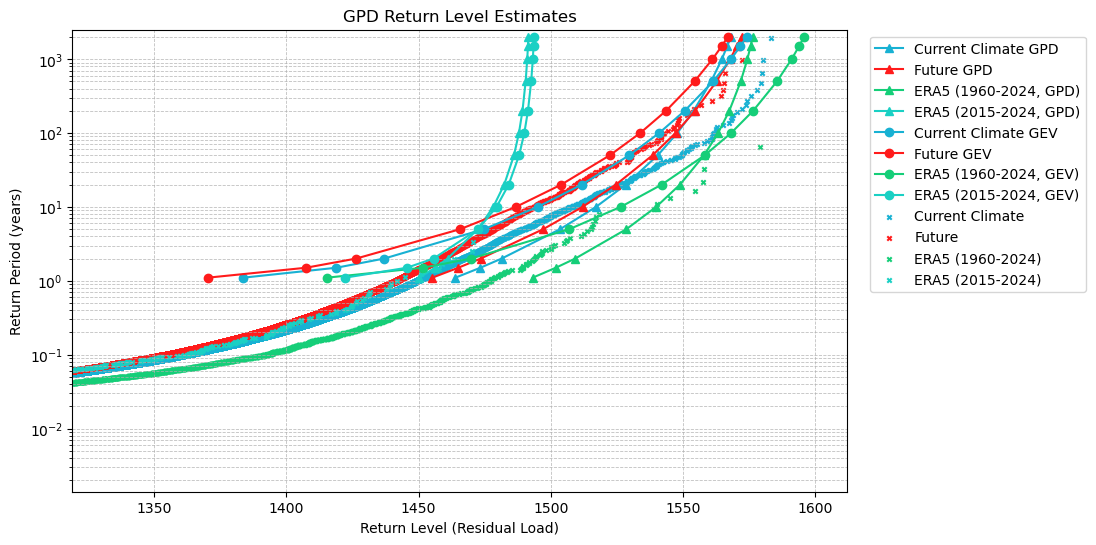

In [48]:
# 1 Day event GEV/GPD return levels comparison
RLs = [res_load_curr_clim_1d, res_load_fut_1d, res_load_ERA5, res_load_era5_15_24_1d]

seasonal_maxima = [res_load_curr_clim_sm, res_load_fut_sm, res_load_ERA5_sm, res_load_era5_15_24_sm]

labels = ['Current Climate', 
          'Future', 
          'ERA5 (1960-2024)', 
          'ERA5 (2015-2024)' ]

labels_GEV = ['Current Climate GEV', 
          'Future GEV', 
          'ERA5 (1960-2024, GEV)', 
          'ERA5 (2015-2024, GEV)' ]

colors = [
    "#18B1D3",  # Current Climate (1d) - Sky blue
    "#FF1B1B",  # Future (1d) - dark red
    "#15CE78",  # ERA5 (1960-2024, 1d) - Mint green
    "#1AD0C4",  # ERA5 (2015-2024, 1d) - Teal
]

T = np.array([1.1, 1.5, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 1500, 2000])  # in years

excesses = [excesses_LEE, 
            excesses_LEE_fut, 
            excesses_LEE_era,
            excesses_LEE_era5_15_24
            ]


labels_GPD = ['Current Climate GPD', 
          'Future GPD', 
          'ERA5 (1960-2024, GPD)', 
          'ERA5 (2015-2024, GPD)' ]

z_T_list_GPD = []
for exc, label in zip(excesses, labels_GPD):
    # print(f"Fitting GPD for {label}...")
    z_T = GPD_fit(exc, threshold, label)
    z_T_list_GPD.append(z_T)


z_T_list_GEV = []
for seas_max in seasonal_maxima:

    x = np.asarray(seas_max)

    # standardize
    x_std = (x - x.mean()) / x.std()

    shape, loc, scale = genextreme.fit(x_std)
    
    mu = x.mean()
    sigma = x.std()

    z_T_std = genextreme.ppf(
        1 - 1/T,
        shape,
        loc=loc,
        scale=scale
    )

    # transform back
    z_T = z_T_std * sigma + mu
    
    z_T_list_GEV.append(z_T)


# Plot return levels
plt.figure(figsize=(10, 6))
for z_T, label, color in zip(z_T_list_GPD, labels_GPD, colors):
    marker = '^'
    plt.plot(z_T, T, label=label, color=color, marker=marker)
for z_T, label, color in zip(z_T_list_GEV, labels_GEV, colors):
    marker = 'o'
    plt.plot(z_T, T, label=label, color=color, marker=marker)
for res_load, label, color in zip(RLs, labels, colors):

    # Example: extreme residual load values
    extremes = res_load # your event values

    # Sort descending
    x = np.sort(extremes)[::-1]

    # Rank
    m = np.arange(1, len(x) + 1)

    # Total observation period (important!)
    N = len(extremes)  # OR number of years, depending on method

    # Return period
    # T = (N + 1) / (N + 1 - m)
    T_all_point = ((N + 1) / m) / 365

    plt.scatter(x, T_all_point, marker='x', s=10, label=label, color=color) # Marker = cross, size = 1


plt.yscale('log')
plt.xlim(np.float64(1319.138650687668), np.float64(1596.223514139268)*1.01)
plt.ylim(0, 2500)
plt.ylabel('Return Period (years)')
plt.xlabel('Return Level (Residual Load)')
plt.title('GPD Return Level Estimates')
plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.8)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

Fitting GEV for Future (7d)...
Fitting GEV for ERA5 (2015-2024, 7d)...
Fitting GEV for Current Climate (7d)...
Fitting GEV for ERA5 (1960-2024, 7d)...


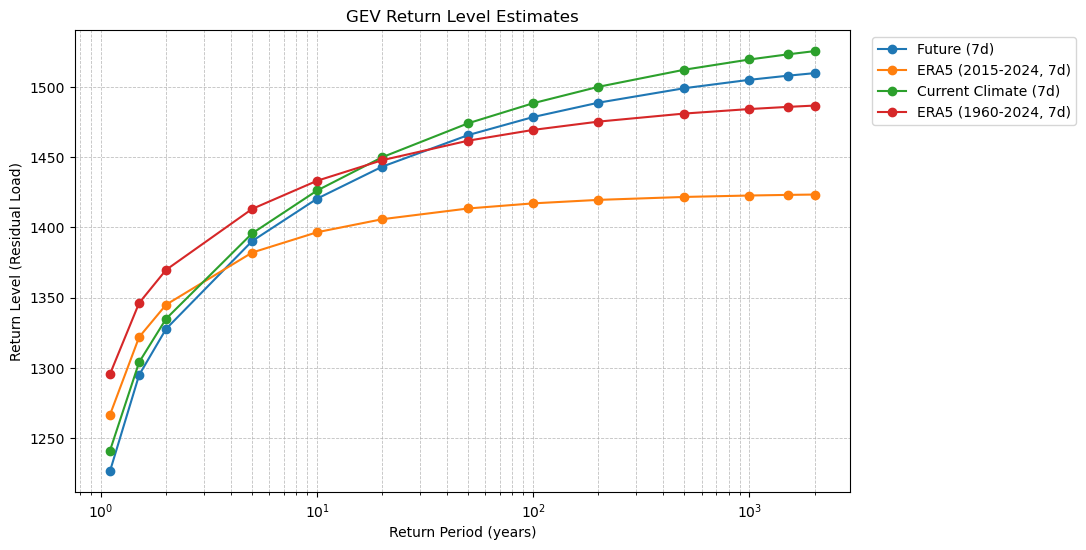

In [32]:
seasonal_maxima = [res_load_fut_7d_sm,
            res_load_era5_15_24_7d_sm, 
            res_load_curr_clim_7d_sm , 
            res_load_ERA5_7d_sm]

labels = ['Future (7d)',
          'ERA5 (2015-2024, 7d)', 
          'Current Climate (7d)', 
          'ERA5 (1960-2024, 7d)']

z_T_list = []
T = np.array([1.1, 1.5, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 1500, 2000])  # in years

for seas_max, label in zip(seasonal_maxima, labels):
    print(f"Fitting GEV for {label}...")
    
    
    x = np.asarray(seas_max)

    # standardize
    x_std = (x - x.mean()) / x.std()

    shape, loc, scale = genextreme.fit(x_std)
    
    # shape, loc, scale = genextreme.fit(seas_max)

    # return levels
    # z_T = genextreme.ppf(1 - 1/T, shape, loc=loc, scale=scale)
    
    mu = x.mean()
    sigma = x.std()

    z_T_std = genextreme.ppf(
        1 - 1/T,
        shape,
        loc=loc,
        scale=scale
    )

    # transform back
    z_T = z_T_std * sigma + mu
    
    z_T_list.append(z_T)

# Plot return levels
plt.figure(figsize=(10, 6))
for z_T, label in zip(z_T_list, labels):
    plt.plot(T, z_T, marker='o', label=label)
plt.xscale('log')
plt.xlabel('Return Period (years)')
plt.ylabel('Return Level (Residual Load)')
plt.title('GEV Return Level Estimates')
plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.8)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

Fitting GPD for GPD Current Climate...
Fitting GPD for GPD Future...
Fitting GPD for GPD ERA5 (1960-2024)...


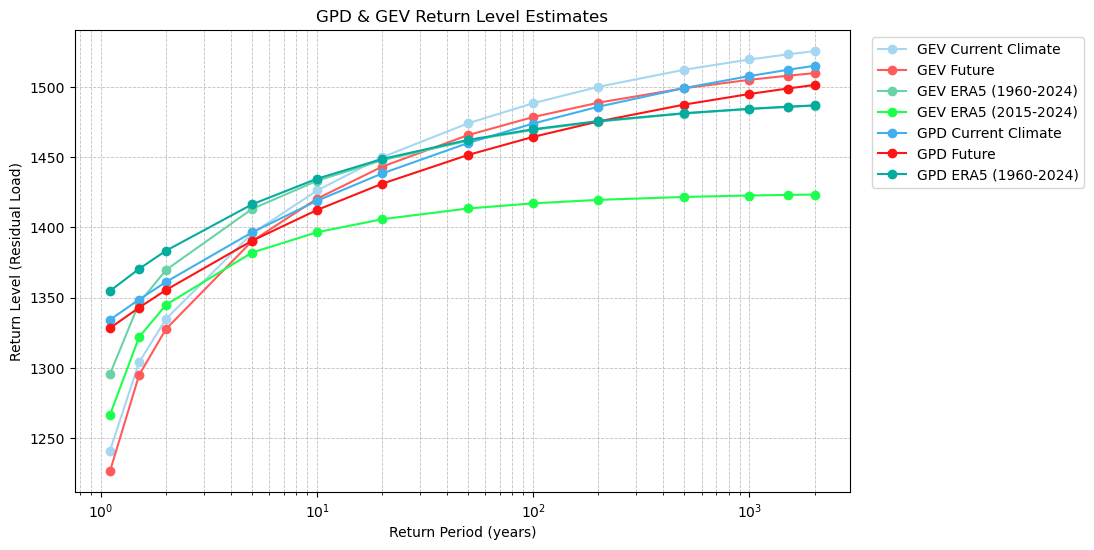

In [ ]:
# 7 Day event GEV/GPD return levels comparison
seasonal_maxima = [res_load_curr_clim_7d_sm, 
                   res_load_fut_7d_sm,
                   res_load_ERA5_7d_sm,
                   res_load_era5_15_24_7d_sm]

labels = ['GEV Current Climate', 
          'GEV Future',
          'GEV ERA5 (1960-2024)', 
          'GEV ERA5 (2015-2024)']

colors = [
    '#A5D7F1',  # Current Climate (7d) - Lightest sky blue
    "#FF5B5B",  # Future (7d) - soft red
    "#69D3A5",  # ERA5 (1960-2024, 7d) - Lighter mint green
    "#1CFF4D",  # ERA5 (2015-2024, 7d) - Lighter teal
]

z_T_list = []
T = np.array([1.1, 1.5, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 1500, 2000])  # in years

for seas_max, label in zip(seasonal_maxima, labels):
    x = np.asarray(seas_max)

    # standardize
    x_std = (x - x.mean()) / x.std()

    shape, loc, scale = genextreme.fit(x_std)
    
    # shape, loc, scale = genextreme.fit(seas_max)

    # return levels
    # z_T = genextreme.ppf(1 - 1/T, shape, loc=loc, scale=scale)
    
    mu = x.mean()
    sigma = x.std()

    z_T_std = genextreme.ppf(
        1 - 1/T,
        shape,
        loc=loc,
        scale=scale
    )

    # transform back
    z_T = z_T_std * sigma + mu
    
    z_T_list.append(z_T)

excesses = [excesses_LEE7, excesses_LEE7_fut, excesses_LEE7_era]
labels_GPD = [
          'GPD Current Climate',
          'GPD Future',
          'GPD ERA5 (1960-2024)']
colors_GPD = [
    "#41B0EC",  # Current Climate (7d) - Lightest sky blue
    "#FD1515",  # Future (7d) - soft red
    "#04ACA0",  # ERA5 (2015-2024, 7d) - Lighter teal
]


z_T_list_GPD = []
for exc, label in zip(excesses, labels_GPD):
    print(f"Fitting GPD for {label}...")
    z_T = GPD_fit(exc, threshold, label)
    z_T_list_GPD.append(z_T)


# Plot return levels
plt.figure(figsize=(10, 6))
for z_T, label, color in zip(z_T_list, labels, colors):
    plt.plot(T, z_T, marker='o', label=label, color=color)
for z_T, label, color in zip(z_T_list_GPD, labels_GPD, colors_GPD):
    plt.plot(T, z_T, marker='o', label=label, color=color)
plt.xscale('log')
plt.xlabel('Return Period (years)')
plt.ylabel('Return Level (Residual Load)')
plt.title('GPD & GEV Return Level Estimates')
plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.8)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

Fitting GEV for Future (14d)...
Fitting GEV for ERA5 (2015-2024, 14d)...
Fitting GEV for Current Climate (14d)...
Fitting GEV for ERA5 (1960-2024, 14d)...


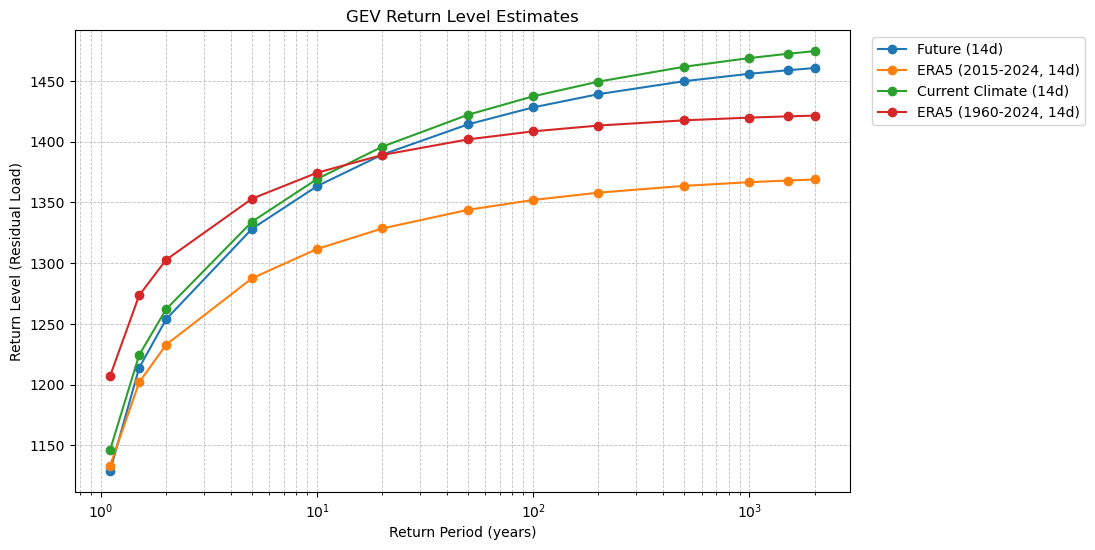

In [35]:
seasonal_maxima = [res_load_fut_14d_sm,
            res_load_era5_15_24_14d_sm,
            res_load_curr_clim_14d_sm,
            res_load_ERA5_14d_sm]

labels = ['Future (14d)',
          'ERA5 (2015-2024, 14d)',
          'Current Climate (14d)',
          'ERA5 (1960-2024, 14d)']

z_T_list = []
T = np.array([1.1, 1.5, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 1500, 2000])  # in years

for seas_max, label in zip(seasonal_maxima, labels):
    print(f"Fitting GEV for {label}...")
    
    
    x = np.asarray(seas_max)

    # standardize
    x_std = (x - x.mean()) / x.std()

    shape, loc, scale = genextreme.fit(x_std)
    
    # shape, loc, scale = genextreme.fit(seas_max)

    # return levels
    # z_T = genextreme.ppf(1 - 1/T, shape, loc=loc, scale=scale)
    
    mu = x.mean()
    sigma = x.std()

    z_T_std = genextreme.ppf(
        1 - 1/T,
        shape,
        loc=loc,
        scale=scale
    )

    # transform back
    z_T = z_T_std * sigma + mu
    
    z_T_list.append(z_T)

# Plot return levels
plt.figure(figsize=(10, 6))
for z_T, label in zip(z_T_list, labels):
    plt.plot(T, z_T, marker='o', label=label)
plt.xscale('log')
plt.xlabel('Return Period (years)')
plt.ylabel('Return Level (Residual Load)')
plt.title('GEV Return Level Estimates')
plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.8)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

Fitting GPD for GPD Current Climate...
Fitting GPD for GPD Future...
Fitting GPD for GPD ERA5 (1960-2024)...


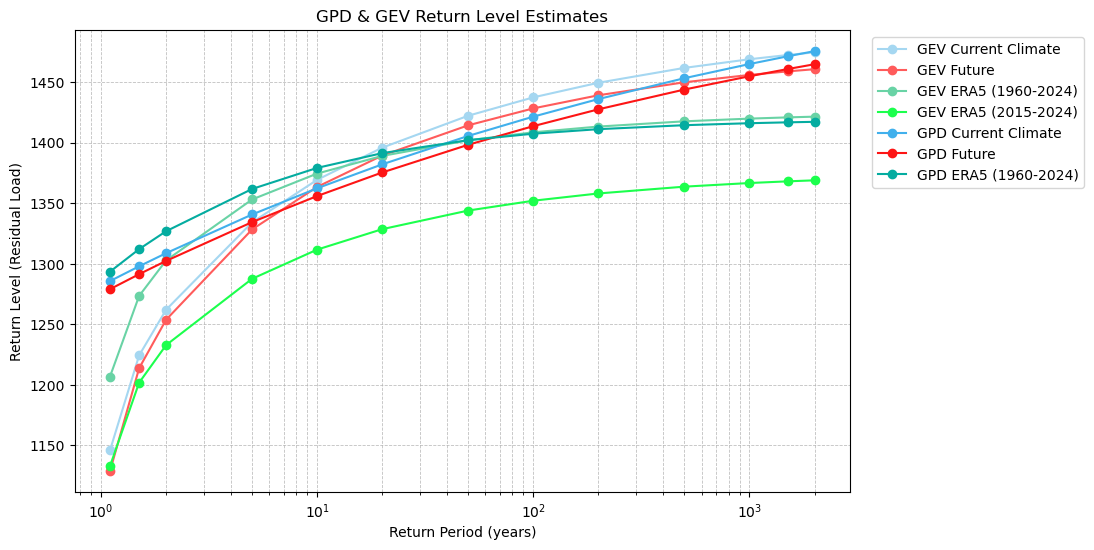

In [ ]:
# 14 Day event GEV/GPD return levels comparison
seasonal_maxima = [res_load_curr_clim_14d_sm, 
                   res_load_fut_14d_sm,
                   res_load_ERA5_14d_sm,
                   res_load_era5_15_24_14d_sm]

labels = ['GEV Current Climate', 
          'GEV Future',
          'GEV ERA5 (1960-2024)', 
          'GEV ERA5 (2015-2024)']

colors = [
    '#A5D7F1',  # Current Climate (14d) - Lightest sky blue
    "#FF5B5B",  # Future (14d) - soft red
    "#69D3A5",  # ERA5 (1960-2024, 14d) - Lighter mint green
    "#1CFF4D",  # ERA5 (2015-2024, 14d) - Lighter teal
]

z_T_list = []
T = np.array([1.1, 1.5, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 1500, 2000])  # in years

for seas_max, label in zip(seasonal_maxima, labels):
    x = np.asarray(seas_max)

    # standardize
    x_std = (x - x.mean()) / x.std()

    shape, loc, scale = genextreme.fit(x_std)
    
    # shape, loc, scale = genextreme.fit(seas_max)

    # return levels
    # z_T = genextreme.ppf(1 - 1/T, shape, loc=loc, scale=scale)
    
    mu = x.mean()
    sigma = x.std()

    z_T_std = genextreme.ppf(
        1 - 1/T,
        shape,
        loc=loc,
        scale=scale
    )

    # transform back
    z_T = z_T_std * sigma + mu
    
    z_T_list.append(z_T)

excesses = [excesses_LEE14, excesses_LEE14_fut, excesses_LEE14_era]
labels_GPD = [
          'GPD Current Climate',
          'GPD Future',
          'GPD ERA5 (1960-2024)']
colors_GPD = [
    "#41B0EC",  # Current Climate (7d) - Lightest sky blue
    "#FD1515",  # Future (7d) - soft red
    "#04ACA0",  # ERA5 (2015-2024, 7d) - Lighter teal
]


z_T_list_GPD = []
for exc, label in zip(excesses, labels_GPD):
    print(f"Fitting GPD for {label}...")
    z_T = GPD_fit(exc, threshold, label)
    z_T_list_GPD.append(z_T)


# Plot return levels
plt.figure(figsize=(10, 6))
for z_T, label, color in zip(z_T_list, labels, colors):
    plt.plot(T, z_T, marker='o', label=label, color=color)
for z_T, label, color in zip(z_T_list_GPD, labels_GPD, colors_GPD):
    plt.plot(T, z_T, marker='o', label=label, color=color)
plt.xscale('log')
plt.xlabel('Return Period (years)')
plt.ylabel('Return Level (Residual Load)')
plt.title('GPD & GEV Return Level Estimates')
plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.8)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

In [147]:
x = np.asarray(res_load_fut_sm)

# standardize
x_std = (x - x.mean()) / x.std()

shape, loc, scale = genextreme.fit(x_std)

print(shape, loc, scale)

0.22472208151606737 -0.3835055852044337 1.031601328373896


In [ ]:

shape, loc, scale = genextreme.fit(res_load_curr_clim_7d_sm)

# return levels
T = np.array([1.1, 10, 20, 50, 100, 200, 500, 1000, 1500, 2000])  # in years
z_T = genextreme.ppf(1 - 1/T, shape, loc=loc, scale=scale)
z_T

array([          nan,           nan, 1222.38793759, 1550.06153006,
       1550.06153174, 1550.06153176, 1550.06153176, 1550.06153176,
       1550.06153176, 1550.06153176, 1550.06153176, 1550.06153176])

In [129]:
shape, loc, scale = genextreme.fit(res_load_fut_sm)

print(shape, loc, scale)

7.330195208476984 1595.728653272607 3.627426753660716


Standardized fit:
shape = 0.21695058410932722
loc   = -0.38013513713226477
scale = 1.0037247076081086

Original-scale parameters:
shape = 0.21695058410932722
loc   = 1422.7529422511152
scale = 40.62753853971841


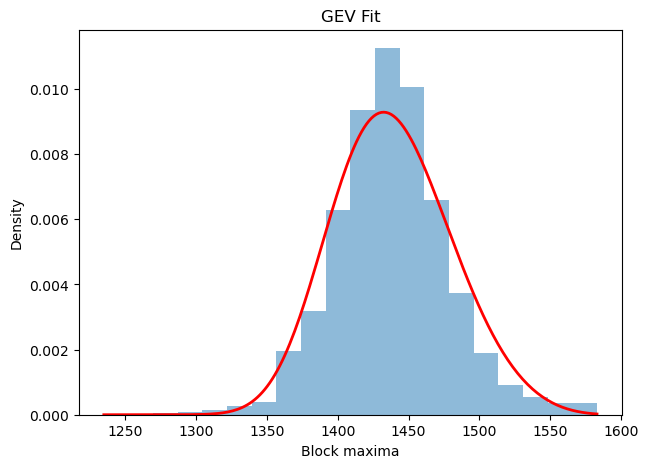

100-year return level: 1540.9902647764773


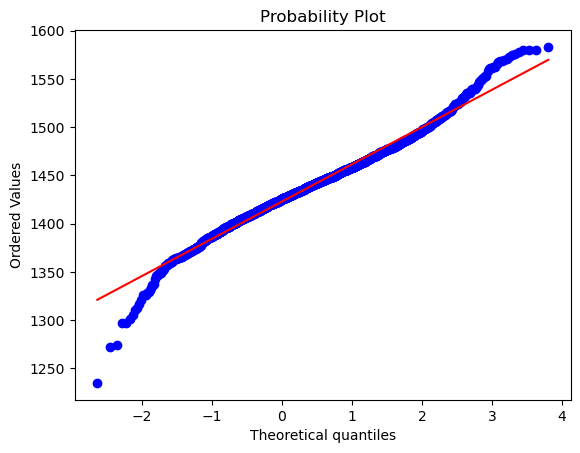

In [85]:

x_data = np.asarray(res_load_curr_clim_sm)

# -----------------------------------
# Standardize
# -----------------------------------

mu = x_data.mean()
sigma = x_data.std()

x_std = (x_data - mu) / sigma

# -----------------------------------
# Fit GEV on standardized data
# -----------------------------------

shape, loc, scale = genextreme.fit(x_std)

print("Standardized fit:")
print("shape =", shape)
print("loc   =", loc)
print("scale =", scale)

# -----------------------------------
# Transform parameters back
# -----------------------------------

loc_orig = mu + sigma * loc
scale_orig = sigma * scale

print("\nOriginal-scale parameters:")
print("shape =", shape)
print("loc   =", loc_orig)
print("scale =", scale_orig)

# -----------------------------------
# PDF plot
# -----------------------------------

x = np.linspace(x_data.min(), x_data.max(), 200)

pdf = genextreme.pdf(
    x,
    shape,
    loc=loc_orig,
    scale=scale_orig
)

plt.figure(figsize=(7,5))

plt.hist(x_data, bins=20, density=True, alpha=0.5)

plt.plot(x, pdf, 'r-', lw=2)

plt.xlabel("Block maxima")
plt.ylabel("Density")
plt.title("GEV Fit")

plt.show()

# -----------------------------------
# Return level
# -----------------------------------

T = 100

return_level = genextreme.ppf(
    1 - 1/T,
    shape,
    loc=loc_orig,
    scale=scale_orig
)

print("100-year return level:", return_level)
from scipy.stats import probplot

probplot(res_load_curr_clim_sm, dist=genextreme, sparams=(shape,), plot=plt)
plt.show()


In [143]:
print("min:", res_load_fut_sm.min())
print("max:", res_load_fut_sm.max())
print("mean:", res_load_fut_sm.mean())
print("std:", res_load_fut_sm.std())

print("shape =", shape)
print("loc =", loc)
print("scale =", scale)

min: 1206.8130529947678
max: 1596.223514139268
mean: 1427.327612203385
std: 41.36830948959141
shape = 7.330195208476984
loc = 1595.728653272607
scale = 3.627426753660716


In [144]:
print(len(res_load_fut_sm))

2112


In [146]:
from scipy.stats import gumbel_r

loc_g, scale_g = gumbel_r.fit(res_load_fut_sm)

print("Gumbel fit - loc:", loc_g)
print("Gumbel fit - scale:", scale_g)

Gumbel fit - loc: 1406.5345120774816
Gumbel fit - scale: 47.18227221151888


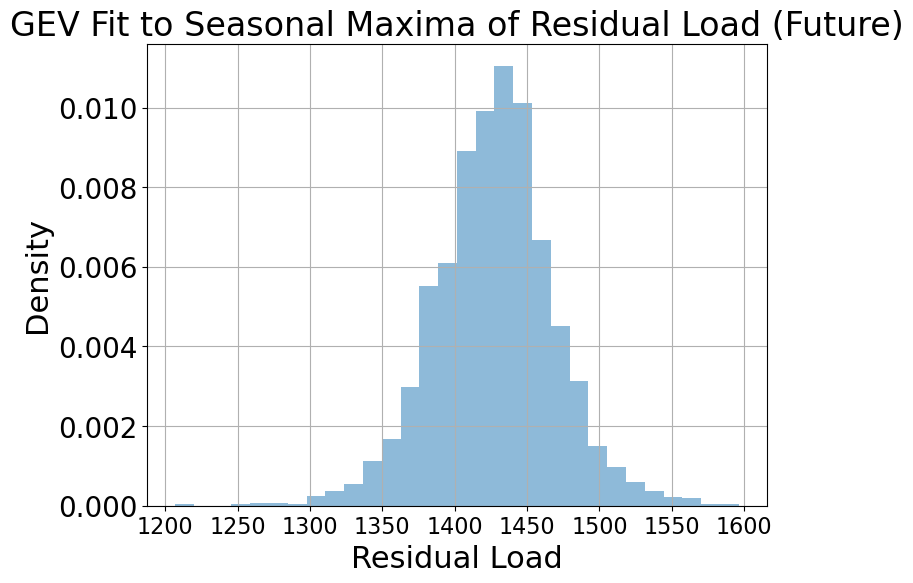

In [132]:
#Plot res_load_fut_sm as a pdf
import matplotlib.pyplot as plt
import numpy as np
x = np.linspace(min(res_load_fut_sm), max(res_load_fut_sm), 100)
# pdf = genextreme.pdf(x, shape, loc=loc, scale=scale)
plt.figure(figsize=(8, 6))
# plt.plot(x, pdf, label='GEV PDF Fit')
plt.hist(res_load_fut_sm, bins=30, density=True, alpha=0.5, label='Seasonal Maxima Data')
plt.xlabel('Residual Load')
plt.ylabel('Density')
plt.title('GEV Fit to Seasonal Maxima of Residual Load (Future)')
# plt.legend()
plt.grid()
plt.show()

In [ ]:
plt.figure()
plt.plot(T, z_T, marker='o')
plt.xscale('log')
plt.xlabel("Return Period (years)")
plt.ylabel("Residual Load")
plt.title("GPD Return Level Plot")
plt.grid(True)
plt.show()

In [97]:
idx = LEE_dat_ERA5_15_24.groupby('winter_season')['RL_mean'].idxmax()
result = LEE_dat_ERA5_15_24.loc[idx]
result

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy,winter_season
29176,2015-01-20,2015-01-20,2015-01-20,19,19,19,1,1439.293940,1439.293940,0.0,1439.293940,29177,ERA5_week,ERA5_hist_week,2015,20,14/15
29195,2016-01-21,2016-01-21,2016-01-21,385,385,385,1,1431.707705,1431.707705,0.0,1431.707705,29196,ERA5_week,ERA5_hist_week,2016,21,15/16
29210,2017-01-08,2017-01-08,2017-01-08,737,737,737,1,1472.776502,1472.776502,0.0,1472.776502,29211,ERA5_week,ERA5_hist_week,2017,8,16/17
29220,2017-11-30,2017-11-30,2017-11-30,1063,1063,1063,1,1416.815943,1416.815943,0.0,1416.815943,29221,ERA5_week,ERA5_hist_week,2017,334,17/18
29246,2019-01-24,2019-01-24,2019-01-24,1483,1483,1483,1,1470.620258,1470.620258,0.0,1470.620258,29247,ERA5_week,ERA5_hist_week,2019,24,18/19
29250,2019-11-20,2019-11-20,2019-11-20,1783,1783,1783,1,1418.844644,1418.844644,0.0,1418.844644,29251,ERA5_week,ERA5_hist_week,2019,324,19/20
29268,2021-01-02,2021-01-02,2021-01-02,2191,2191,2191,1,1426.863649,1426.863649,0.0,1426.863649,29269,ERA5_week,ERA5_hist_week,2021,2,20/21
29285,2021-12-21,2021-12-21,2021-12-21,2544,2544,2544,1,1457.628416,1457.628416,0.0,1457.628416,29286,ERA5_week,ERA5_hist_week,2021,355,21/22
29305,2022-12-16,2022-12-16,2022-12-16,2904,2904,2904,1,1486.441387,1486.441387,0.0,1486.441387,29306,ERA5_week,ERA5_hist_week,2022,350,22/23
29317,2023-12-02,2023-12-02,2023-12-02,3255,3255,3255,1,1463.499258,1463.499258,0.0,1463.499258,29318,ERA5_week,ERA5_hist_week,2023,336,23/24


In [98]:
res_load_curr_clim

<xarray.DataArray 'Residual_load' (ESM_run: 192, time: 3650)> Size: 6MB
array([[ 609.48011372,  793.41464988,  907.1603086 , ..., 1232.37851857,
        1066.37782121,  592.87906948],
       [ 462.58176097,  475.54562743,  537.65952392, ...,  778.522393  ,
         242.01169521,  -92.22855004],
       [ 325.23504813,  867.82497075, 1200.82346924, ..., 1283.62115454,
        1260.91735393,  601.21880191],
       ...,
       [ 888.26090391,  441.74362188,  495.5597482 , ...,  161.56865504,
         287.78453579,  -78.23281115],
       [1278.89246127, 1260.97681835, 1403.45791958, ..., 1212.56949988,
        1300.25157802, 1457.76143367],
       [ 548.54142222, -109.18751349, -210.90010476, ..., 1306.70204962,
        1506.6195729 , 1319.56557544]])
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
  * time           (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    ESM            (ESM_run) <U13 10kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run            (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2'
  * ESM_run        (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL...
    country        float64 8B 9.0
    period         (ESM_run) <U4 3kB 'week' 'week' 'week' ... 'week' 'week'
    doy            (time) int64 29kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
    winter_season  (time) <U5 73kB '14/15' '14/15' '14/15' ... '24/25' '24/25'

In [ ]:
'''tst = res_load_curr_clim.groupby('winter_season').max(dim='time')

# Count values below 1319.138650687668
threshold = np.float64(1319.138650687668)
count_below_threshold = (tst < threshold).sum().item()
print(f"Number of winter seasons with max residual load below {threshold}: {count_below_threshold}")'''

Number of winter seasons with max residual load below 1319.138650687668: 10


In [100]:
# Find seasonal maxima for LEE_dat depending on winter_season and ESM_run
tst = LEE_dat.groupby(['winter_season', 'ESM_run'])['RL_mean'].max()
print(len(tst))
tst

2102


winter_season  ESM_run             
14/15          ACCESS-CM2_r1i1p1f1     1409.547842
               ACCESS-CM2_r4i1p1f1     1428.428099
               ACCESS-CM2_r5i1p1f1     1463.518285
               BCC-CSM2-MR_r1i1p1f1    1404.858048
               CESM2_LE2-1001_001      1431.314219
                                          ...     
24/25          UKESM1-0-LL_r4i1p1f2    1436.857867
               UKESM1-0-LL_r5i1p1f2    1507.908898
               UKESM1-0-LL_r6i1p1f2    1414.957822
               UKESM1-0-LL_r7i1p1f2    1457.761434
               UKESM1-0-LL_r8i1p1f2    1506.619573
Name: RL_mean, Length: 2102, dtype: float64

In [58]:
35063
11 *192

2112

In [35]:
tst = add_winter_season_column(LEE_dat)
tst[0:30]

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy,winter_season
0,2015-01-05,2015-01-05,2015-01-05,4,4,4,1,1347.755832,1347.755832,0.0,1347.755832,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,5,14/15
1,2015-01-07,2015-01-07,2015-01-07,6,6,6,1,1333.134503,1333.134503,0.0,1333.134503,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,7,14/15
2,2015-01-08,2015-01-08,2015-01-08,7,7,7,1,1395.107358,1395.107358,0.0,1395.107358,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,8,14/15
3,2015-01-18,2015-01-18,2015-01-18,17,17,17,1,1409.547842,1409.547842,0.0,1409.547842,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,18,14/15
4,2015-01-19,2015-01-19,2015-01-19,18,18,18,1,1403.974418,1403.974418,0.0,1403.974418,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,19,14/15
5,2015-01-23,2015-01-23,2015-01-23,22,22,22,1,1325.531111,1325.531111,0.0,1325.531111,6,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,23,14/15
6,2015-02-27,2015-02-27,2015-02-27,57,57,57,1,1323.002140,1323.002140,0.0,1323.002140,7,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,58,14/15
7,2015-10-21,2015-10-21,2015-10-21,293,293,293,1,1403.526743,1403.526743,0.0,1403.526743,8,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,294,15/16
8,2015-10-22,2015-10-22,2015-10-22,294,294,294,1,1378.335421,1378.335421,0.0,1378.335421,9,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,295,15/16
9,2015-11-04,2015-11-04,2015-11-04,307,307,307,1,1412.958383,1412.958383,0.0,1412.958383,10,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,308,15/16
